In [3]:
import pandas as pd
import subprocess
from functools import reduce
import numpy as np
import umap
from plotnine import *
import os
import pickle
import glob
import time
from itertools import product


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
import simulations.genomes1000_sim as sim_functions

intermediate_plink_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
intermediate_saige_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_saige'
root_dir = '/gpfs/commons/datasets/1000genomes'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
sim_output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'
output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output'

admixture_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5'
map_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.map'

In [5]:
# PARAMETERS
generate_sim = True
evaluate_sim = True
# generate all combinations of e and ps variables
ps_list = [True,False]
e_list = [0.5,1]
num_markers_assoc_list = [100,2000]
init_list = range(100) # 100 random initializations for each combination
bfile_path=f'{output_dir}/G'
af_df_filepath=admixture_filepath
# PARAMETERS

## Explore 1000 genomes data

### Algorithm creation

In [4]:
import pandas as pd
import subprocess
from functools import reduce
import numpy as np
import umap
from plotnine import *
import os
import pickle
import glob
import time
from itertools import product
from joblib import Parallel, delayed
from functools import partial
import sys
import mlflow
import submitit
import random
from mlflow.tracking import MlflowClient
from datetime import datetime
from zoneinfo import ZoneInfo
intermediate_plink_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
intermediate_saige_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_saige'
root_dir = '/gpfs/commons/datasets/1000genomes'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
sim_output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'
output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output'
admixture_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5'
map_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.map'
code_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/code'
artifact_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs'
sys.path.append(code_dir)
import simulations.genomes1000_sim as sim_functions
import algorithms.SCoNE as SCoNE
import algorithms.MLFlowWrapper as MLFlowWrapper
import evaluation.cluster_evaluation as cluster_evaluation
import importlib

# PARAMETERS
generate_sim = True
evaluate_sim = True
# generate all combinations of e and ps variables
ps_list = [True,False]
e_list = [0.25,0.5,0.75,1]
num_markers_assoc_list = [100,500]
bfile_path=f'{output_dir}/G'
af_df_filepath=admixture_filepath
rank = 3
tuning = False # to run sparsity tuning step
testing = True # to run testing step
# PARAMETERS
np.random.seed(42)

# read in G, Z
igsr_samples = sim_functions.read_in_igsr_samples(igsr_samples_filepath, bfile_path=f'{sim_output_dir}/G')
igsr_samples['Sex'] = igsr_samples['Sex'].map({'female': 0, 'male': 1})

admixture = pd.read_csv(f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5.Q',sep='\s+',header=None)
fam_df = pd.read_csv(f'{sim_output_dir}/G.fam',sep='\s+',header=None)
fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
admixture['IID'] = fam_df['IID'].values
Z_df = admixture.merge(igsr_samples[['IID','Sex']], on='IID',how='inner')
Z = Z_df[[i for i in Z_df.columns if i!='IID']].to_numpy()

G = np.loadtxt(f'{sim_output_dir}/G.raw',  usecols=range(6, 10000+6), dtype=np.int8, skiprows=1)
G = (G>0).astype(np.int8)
# assert that bim_df and G order is the same
bfile_path = f'{sim_output_dir}/G'
bim_df = pd.read_csv(f'{bfile_path}.bim',sep='\s+',header=None,names=['CHR','SNP','CM','POS','A1','A2']).reset_index(drop=True)
G_columns = [i.split('_')[0] for i in pd.read_csv(f'{bfile_path}.raw',sep='\s+',usecols=range(6, 10000+6),nrows=1).columns]
assert all(bim_df['SNP'].values==G_columns)



In [54]:
G = np.random.choice([0, 1], (2500,200))
C = np.random.poisson(lam=3, size=(2500,100))
Z = np.random.poisson(lam=3, size=(2500,100))
iid_index = range(2500)
W = np.random.random((G[iid_index,:].shape[0], rank))*1e-2+1e-6 # aorund 0 to 1e-2
H_G = np.random.random((G[iid_index,:].shape[1], rank))*1e-2+1e-6
H_C = np.random.random((100, rank))*1e-2+1e-6 # fixed: 100 clinical vars
U_G = np.random.random((G[iid_index,:].shape[1], Z[iid_index,:].shape[1]))*1e-2+1e-6
U_C = np.random.random((100, Z[iid_index,:].shape[1]))*1e-2+1e-6
iid_index = range(2500)
# if C_loss_type and G_loss_type are None, shouldn't be any change in factor matrices from random
factor_matrices, loss_function = SCoNE.alternating_opt(G,C,np.zeros((2500,10)),
    W, H_G, H_C, U_G, U_C,lambda_W=0, lambda_H_G=0, lambda_H_C=0, 
    method='L-BFGS-B',options={'maxcor':10, 'maxiter':10, 'gtol':1e-5, 'maxls':20, 'ftol':1e-6},tol=1e-4,nonneg=True, C_loss_type=None, G_loss_type=None)


# Working on test code

In [5]:
# test code setup

# DEFINE PATHS
intermediate_plink_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
intermediate_saige_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_saige'
root_dir = '/gpfs/commons/datasets/1000genomes'
sim_output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'
graph_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
maf_by_superpop_filepath = f'{intermediate_plink_dir}/maf_by_superpop'
admixture_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5'
map_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.map'
code_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/code'
# DEFINE PATHS


# read in 
G = np.loadtxt(f'{sim_output_dir}/G.raw',  usecols=range(6, 10000+6), dtype=np.int8, skiprows=1)
G = (G>0).astype(np.int8)
# assert that bim_df and G order is the same
bfile_path = f'{sim_output_dir}/G'
bim_df = pd.read_csv(f'{bfile_path}.bim',sep='\s+',header=None,names=['CHR','SNP','CM','POS','A1','A2']).reset_index(drop=True)
G_columns = [i.split('_')[0] for i in pd.read_csv(f'{bfile_path}.raw',sep='\s+',usecols=range(6, 10000+6),nrows=1).columns]
assert all(bim_df['SNP'].values==G_columns)

In [6]:
from collections import defaultdict


In [ ]:
# genetic markers and phenotypic subgroup
ps_list = [True,False]
e_list = [0.25, 0.50, 0.75, 1]
g_list = [100,500] # g represents the number of linked markers
dataset_list = range(11) # 11 random datasets for each combination
overall = []
for ps, g, dataset in list(product(ps_list,g_list,dataset_list)):
    print(f'ps: {ps}, g:{g}, dataset:{dataset}')
    e_corr = defaultdict(list) # correlation of phenotypic gi w/ linked snps (take mean over two gi subgroups) for different e values
    for e in e_list:
        output_file_suffix = sim_functions.get_output_file_suffix(ps,e,dataset,g)
        with open(f"{sim_output_dir}/simulation_metadata_{output_file_suffix}.pkl", "rb") as f:
            data = pickle.load(f)
        fam_df = pd.read_csv(f'{bfile_path}.fam',sep='\s+',header=None)
        fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
        iid_index = fam_df[fam_df['IID'].isin(data['iid_order'])].index # some samples removed due to overlap btwn subgroups, need correct length
            
        phenotypic_subgroups = (data['phenotypic_subgroups'].pivot(index='IID',columns='phenotypic_subgroup',values='subgroup')
            .reindex(data['iid_order']).to_numpy().astype(int))
        phenotypic_subgroups_centered = (phenotypic_subgroups - phenotypic_subgroups.mean(axis=0)) / phenotypic_subgroups.std(axis=0, ddof=1)

        # correlation matrix: (n_phenotypic_subgroupscols × n_Gcols)
        G_centered = (G[iid_index,:] - G[iid_index,:].mean(axis=0)) / G[iid_index,:].std(axis=0, ddof=1)
        corr = phenotypic_subgroups.T @ G_centered / (G.shape[0] - 1)
        for k,v in data["markers_assoc"].items():
            gi_idx = bim_df[bim_df['SNP'].isin(v)].index.values.tolist() # get index of true linked markers
            e_corr[e].append(corr[k,gi_idx])
            gi_corr = corr[k,gi_idx].mean()
            rand_idx = np.random.choice([i for i in range(G.shape[1]) if i not in gi_idx], size=g, replace=False) 
            rand_corr = corr[k,rand_idx].mean()
            non_gi_corr = corr[k+2,gi_idx].mean()
            # correlation w/ linked snps greater than random snps for genetically informed (gi) subgroup
            assert gi_corr>rand_corr
            # correlation of linked snps w/ gi subgroup greater than that with non-gi phenotypic subgroup (compare gi=0 with non-gi=2 and gi=1 with non-gi=3)
            assert gi_corr>non_gi_corr
    overall.append(np.mean(np.concatenate(e_corr[1]))>np.mean(np.concatenate(e_corr[0.25])))
# assert that more often than not, stronger correlation when e=1 vs. 0.25
assert (sum(overall) / len(overall))>0.5

ps: True, g:100, dataset:0
ps: True, g:100, dataset:1
ps: True, g:100, dataset:2
ps: True, g:100, dataset:3
ps: True, g:100, dataset:4
ps: True, g:100, dataset:5
ps: True, g:100, dataset:6
ps: True, g:100, dataset:7
ps: True, g:100, dataset:8
ps: True, g:100, dataset:9
ps: True, g:100, dataset:10
ps: True, g:500, dataset:0
ps: True, g:500, dataset:1
ps: True, g:500, dataset:2
ps: True, g:500, dataset:3
ps: True, g:500, dataset:4
ps: True, g:500, dataset:5
ps: True, g:500, dataset:6
ps: True, g:500, dataset:7
ps: True, g:500, dataset:8
ps: True, g:500, dataset:9
ps: True, g:500, dataset:10
ps: False, g:100, dataset:0
ps: False, g:100, dataset:1
ps: False, g:100, dataset:2
ps: False, g:100, dataset:3
ps: False, g:100, dataset:4
ps: False, g:100, dataset:5
ps: False, g:100, dataset:6
ps: False, g:100, dataset:7
ps: False, g:100, dataset:8
ps: False, g:100, dataset:9
ps: False, g:100, dataset:10
ps: False, g:500, dataset:0
ps: False, g:500, dataset:1
ps: False, g:500, dataset:2
ps: False, 

In [11]:
percent_true = 100 * (sum(overall) / len(overall))
percent_true

63.63636363636363

ML Flow practice

In [10]:
# PRELIMINARY: set up fixed params across experiments
exp_map = {}
tuning_dataset = {}
for i, (ps, e, num_markers_assoc) in enumerate(product(ps_list, e_list, num_markers_assoc_list)):
    key = (ps, e, num_markers_assoc)
    tuning_dataset[key] = np.random.randint(0, 101)
    exp_map[key] = i

In [10]:
import mlflow
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri("file:/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs_tuning")
client = MlflowClient()
# Get all experiments
experiments = client.search_experiments()
all_runs = []
for exp in experiments:
    df = mlflow.search_runs([exp.experiment_id])
    if not df.empty:
        df["experiment_id"] = exp.experiment_id
        df["experiment_name"] = exp.name
        all_runs.append(df)
all_runs = pd.concat(all_runs, ignore_index=True)
all_runs['params.ps'] = all_runs["params.ps"].map({"True": True, "False": False}).astype("boolean")  # columns you want as bools (nullable)
all_runs[['params.e','params.g','params.lambda_W','params.lambda_H_G','params.lambda_H_C']]  = all_runs[['params.e','params.g','params.lambda_W','params.lambda_H_G','params.lambda_H_C']].astype("float64") 
all_runs = all_runs[~((all_runs['params.lambda_W']==0)&(all_runs['params.lambda_H_G']==0)&(all_runs['params.lambda_H_C']==0))].copy() # TODO: can remove later 
all_runs['G_plus_C_loss'] = all_runs['metrics.G_loss'] + all_runs['metrics.C_loss']
idx = all_runs.groupby(["params.run_name", "params.ps", "params.e", "params.g"])["G_plus_C_loss"].idxmin()
best = (
    all_runs.loc[idx, all_runs.columns]
      .sort_values(["experiment_id","params.run_name", "params.ps", "params.e", "params.g"])
      .reset_index(drop=True)
)

In [14]:
best[["experiment_id","run_id",'params.run_name','params.lambda_W','params.lambda_H_G','params.lambda_H_C', 'metrics.W_norm','metrics.H_G_norm','metrics.H_C_norm']]

,experiment_id,run_id,params.run_name,params.lambda_W,params.lambda_H_G,params.lambda_H_C,metrics.W_norm,metrics.H_G_norm,metrics.H_C_norm
0,423555759145874130,312059b27eb04c0d96899eb6e1dca573,SCoNE,0.5,0.3,0.5,32.678051,60.603820,2.002037
1,423555759145874130,5c2c59733098451f90895dbc31b78a03,SCoNE(Fro),1.0,0.3,1.0,0.432806,0.999444,0.101806
2,423555759145874130,d7ef404755244ff281565fa6fa477a1a,sHNMF,1.0,0.0,1.0,53.737768,69.635128,2.049876


# Reading in test runs

In [13]:
mlflow.set_tracking_uri("file:/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs")
client = MlflowClient()
client = MlflowClient()
# Get all experiments
experiments = client.search_experiments()
all_runs = []
for exp in experiments:
    print(exp)
    df = mlflow.search_runs([exp.experiment_id])
    if not df.empty:
        df["experiment_id"] = exp.experiment_id
        df["experiment_name"] = exp.name
        all_runs.append(df)
all_runs = pd.concat(all_runs, ignore_index=True)
all_runs['params.ps'] = all_runs["params.ps"].map({"True": True, "False": False}).astype("boolean")  # columns you want as bools (nullable)
all_runs[['params.e','params.g','params.lambda_W','params.lambda_H_G','params.lambda_H_C']]  = all_runs[['params.e','params.g','params.lambda_W','params.lambda_H_G','params.lambda_H_C']].astype("float64") 
all_runs.columns=[i.replace('params.','').replace('metrics.','') for i in all_runs.columns]

<Experiment: artifact_location='file:///gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs/831576132596676973', creation_time=1758813473056, experiment_id='831576132596676973', last_update_time=1758813473056, lifecycle_stage='active', name='0', tags={}>


In [16]:
all_runs['G_plus_C_loss'] = all_runs['G_loss'] + all_runs['C_loss']


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


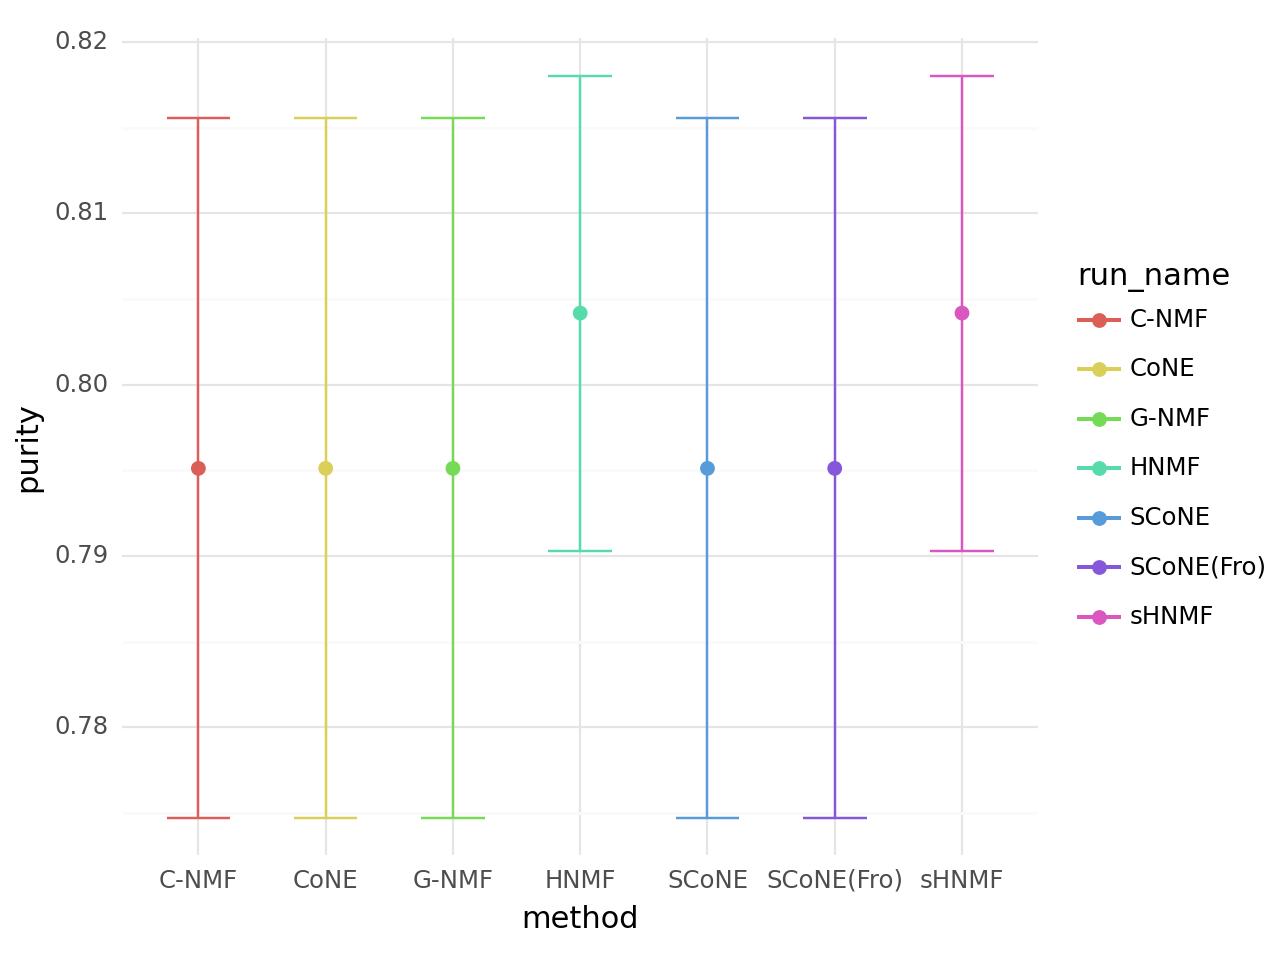

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


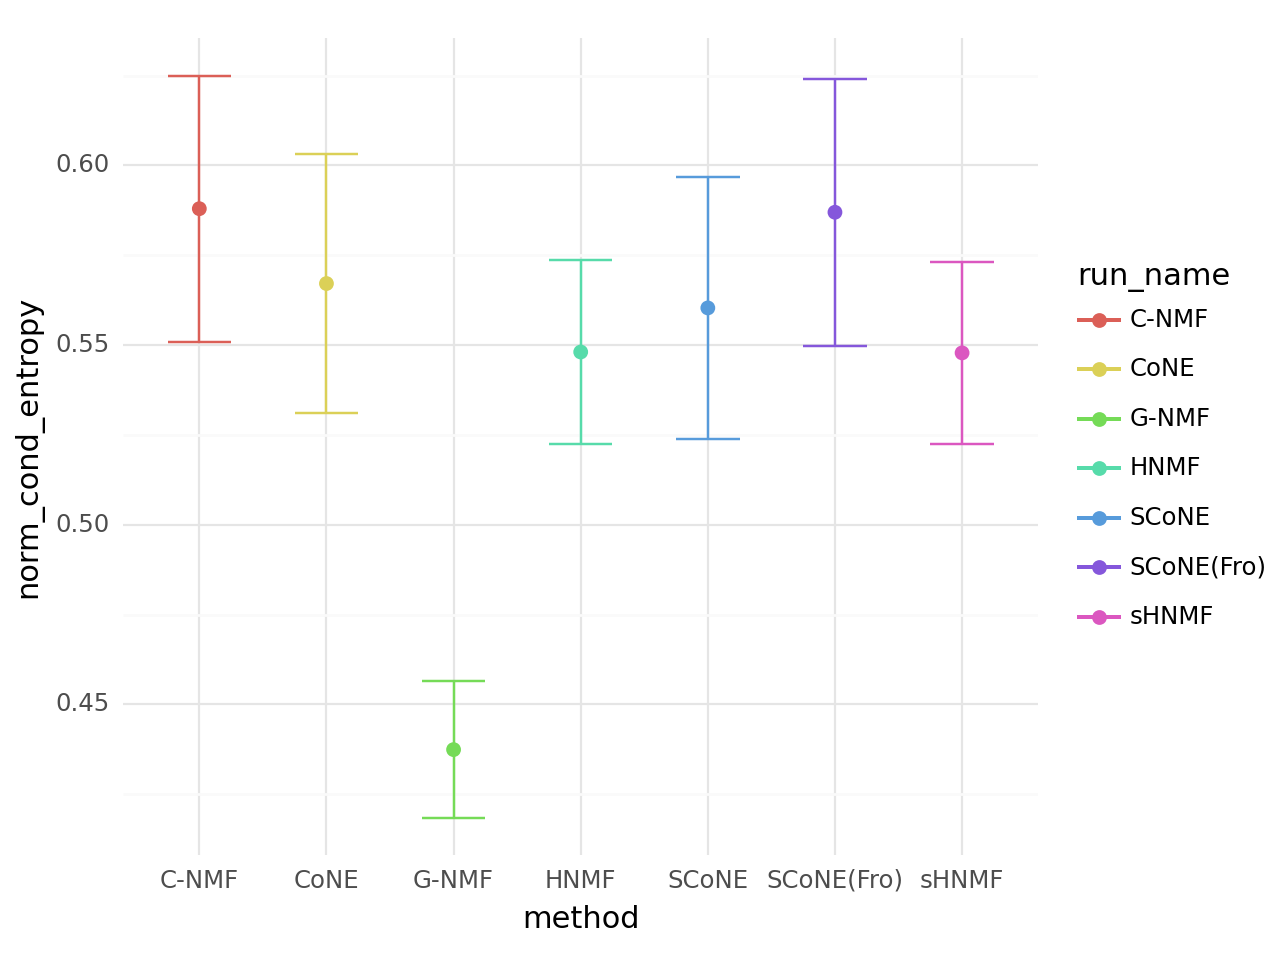

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


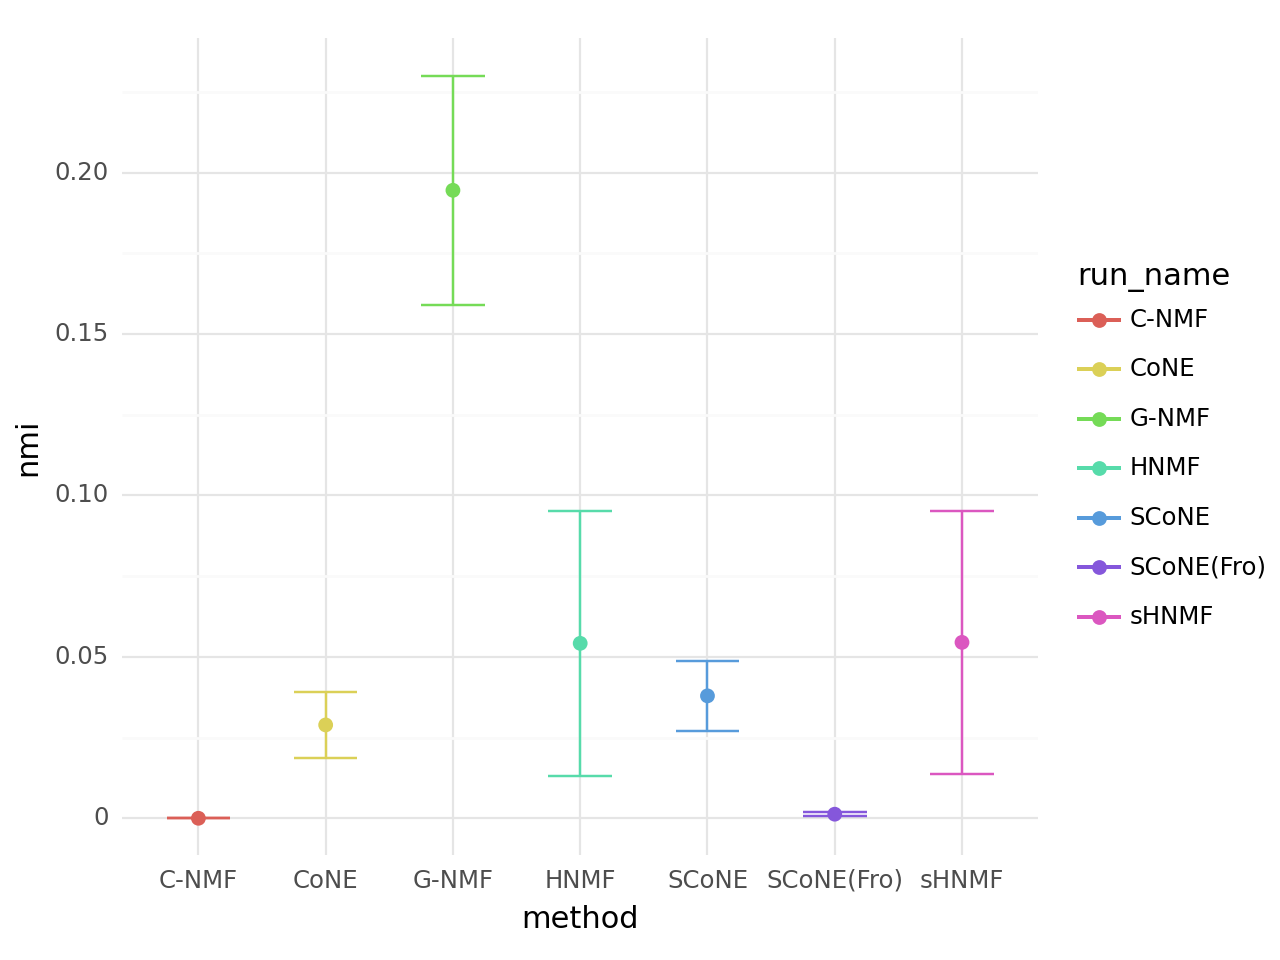

In [28]:
# get best model per total loss (since sparsity params fixed per run now) over initializations (within one experiment, dataset, run_name)
idx = all_runs.groupby(["run_name", "ps", "e", "g","dataset"])["total_loss"].idxmin()
best = (
    all_runs.loc[idx, all_runs.columns]
      .sort_values(["experiment_id","run_name", "ps", "e", "g"])
      .reset_index(drop=True)
)
for metric in ['purity','norm_cond_entropy','nmi']:
    summary = (
        best.groupby(["run_name", "ps", "e", "g"])[metric]
            .agg(n='count', mean='mean', std='std').reset_index()
    )
    summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["n"])         # normal approx 95% CI
    summary["ymin"] = summary["mean"] - summary["ci95"]
    summary["ymax"] = summary["mean"] + summary["ci95"]
    p = (
    ggplot(summary, aes(x="run_name", y="mean", color="run_name", group="run_name"))
    + geom_line()
    + geom_point(size=2)
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"))
    + labs(x="method", y=metric, title='')
    + theme_minimal()
    + theme()
    )
    print(p)


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


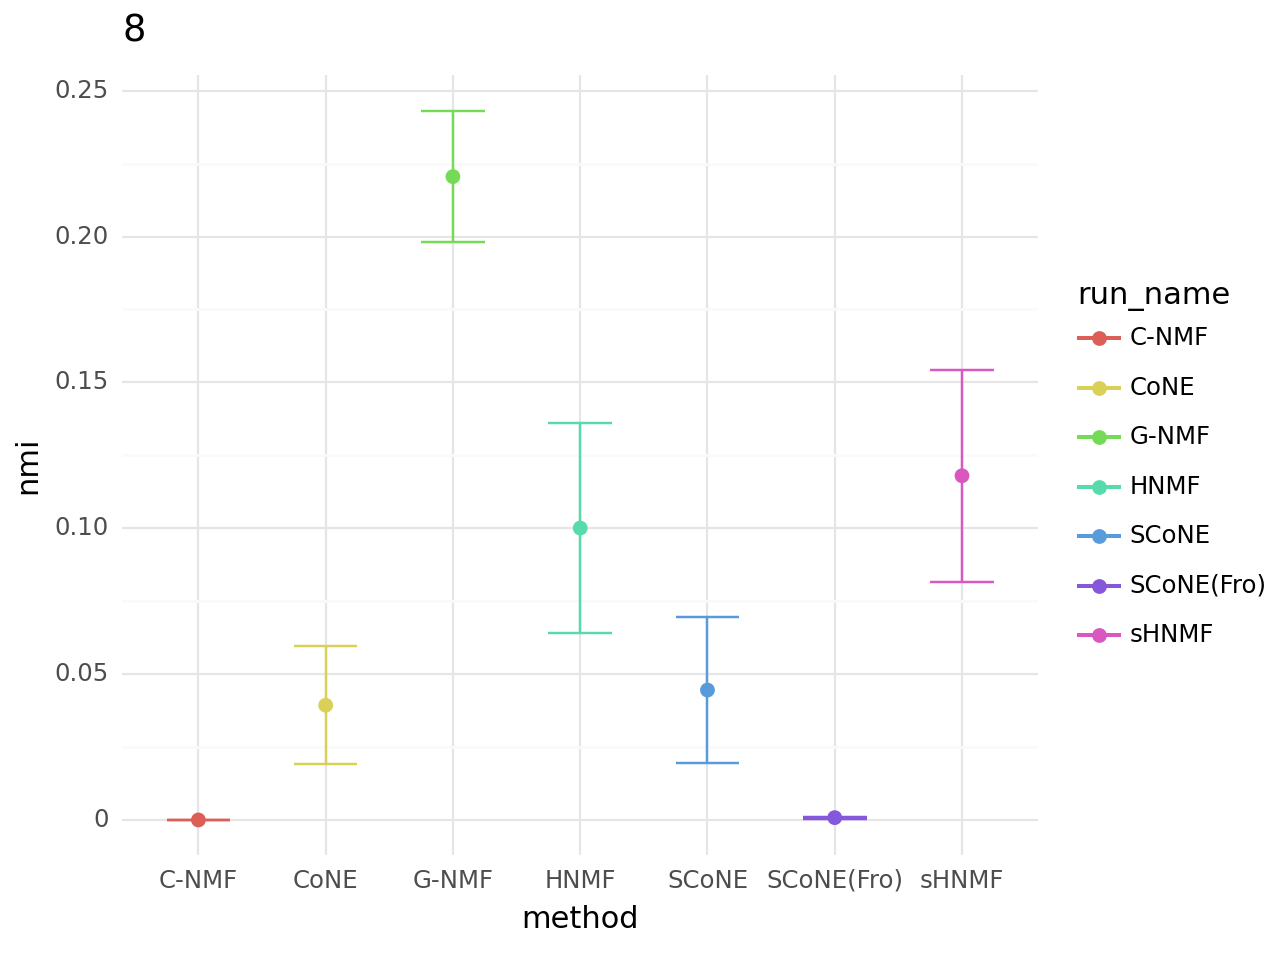

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


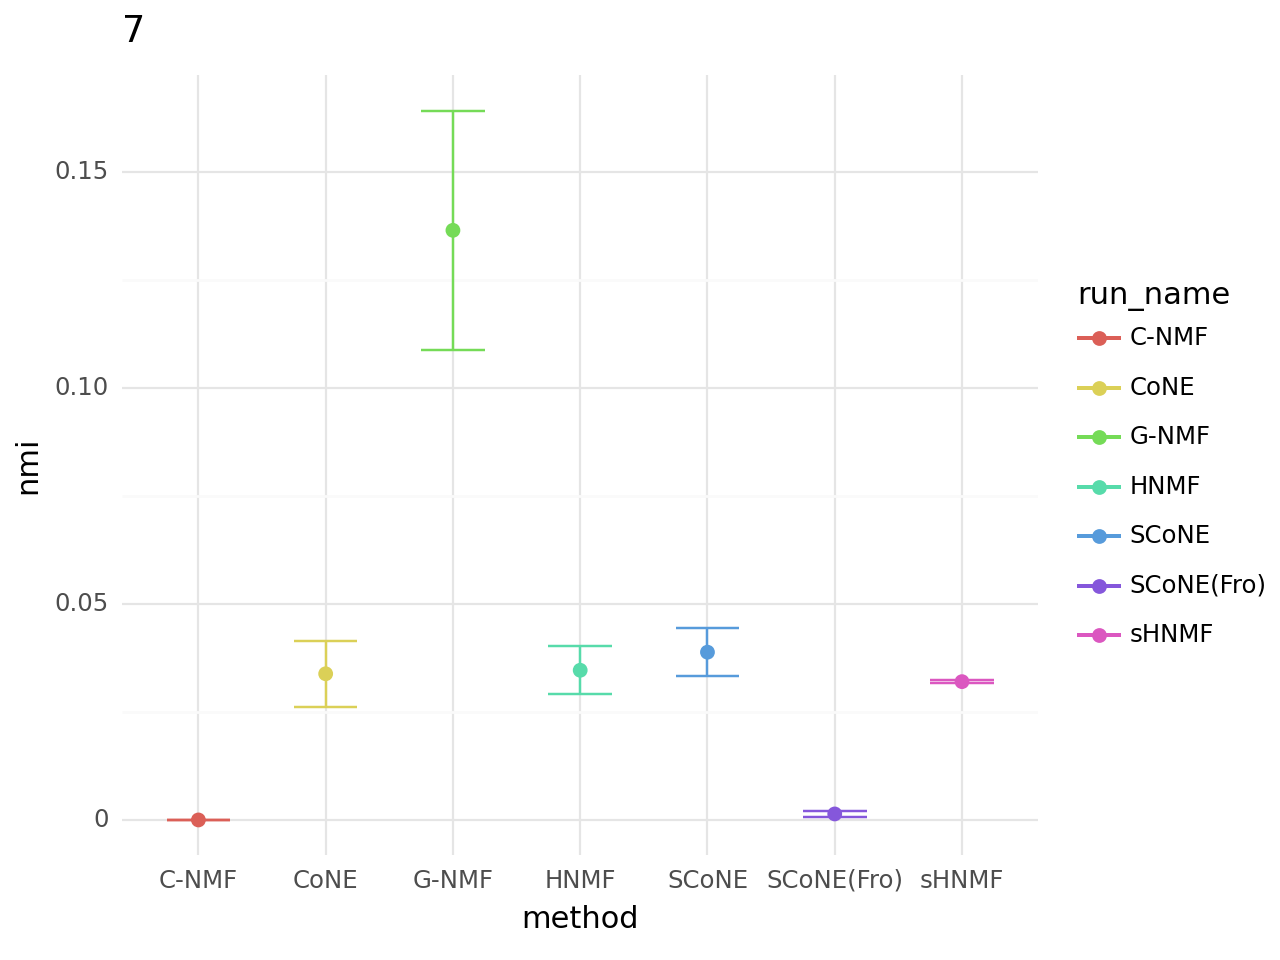

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


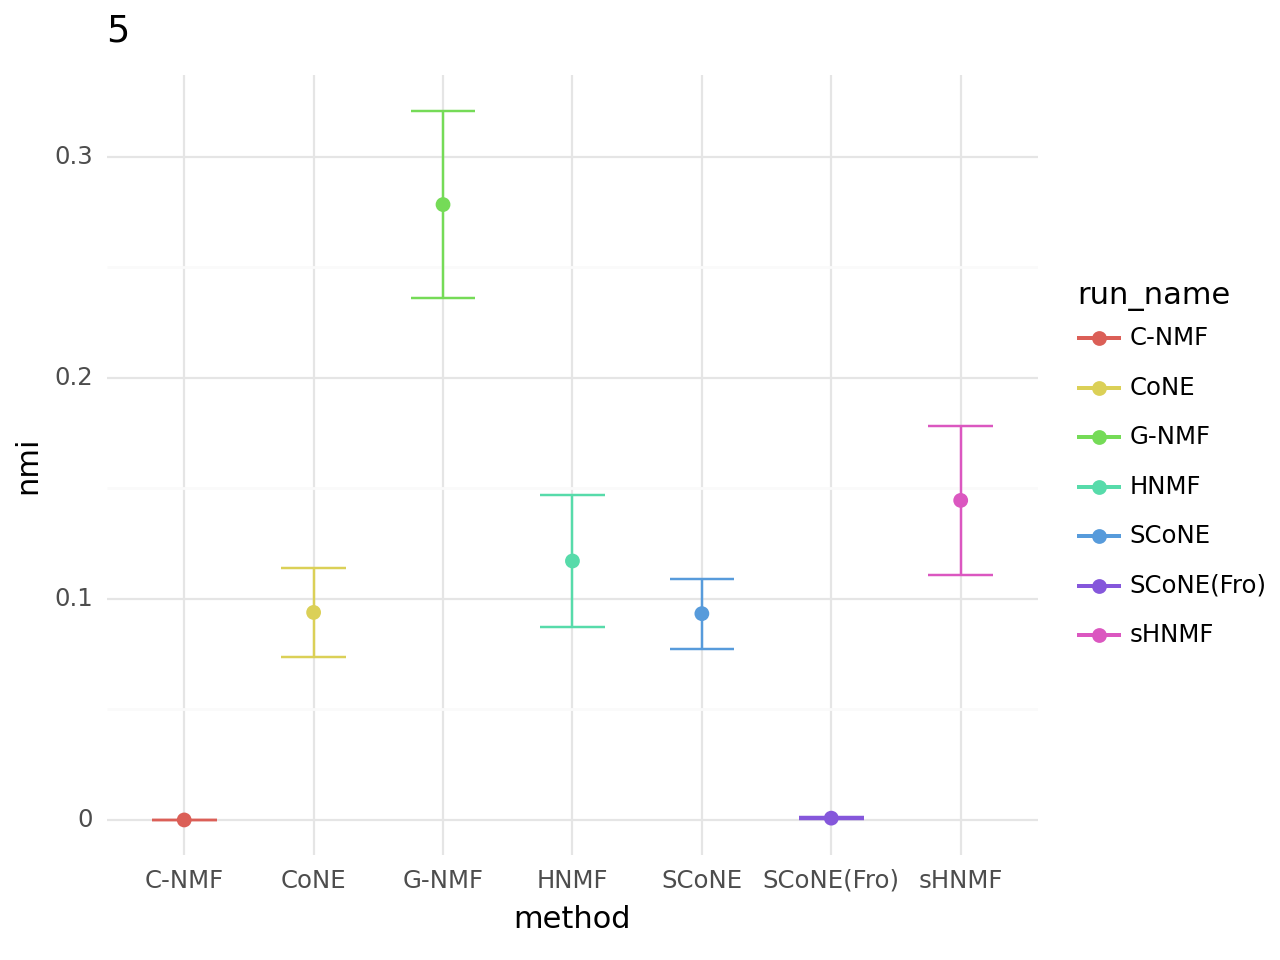

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


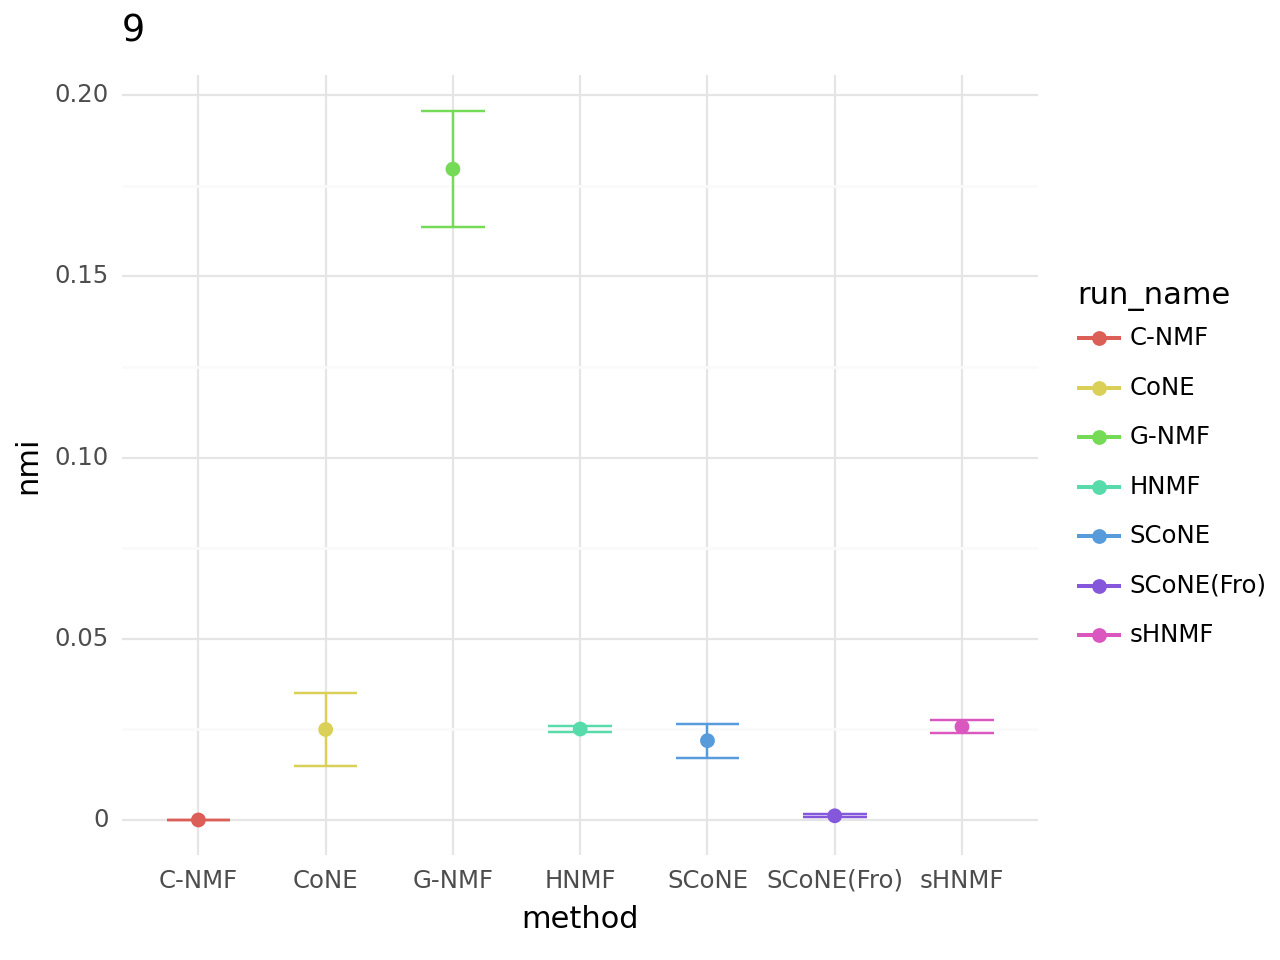

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


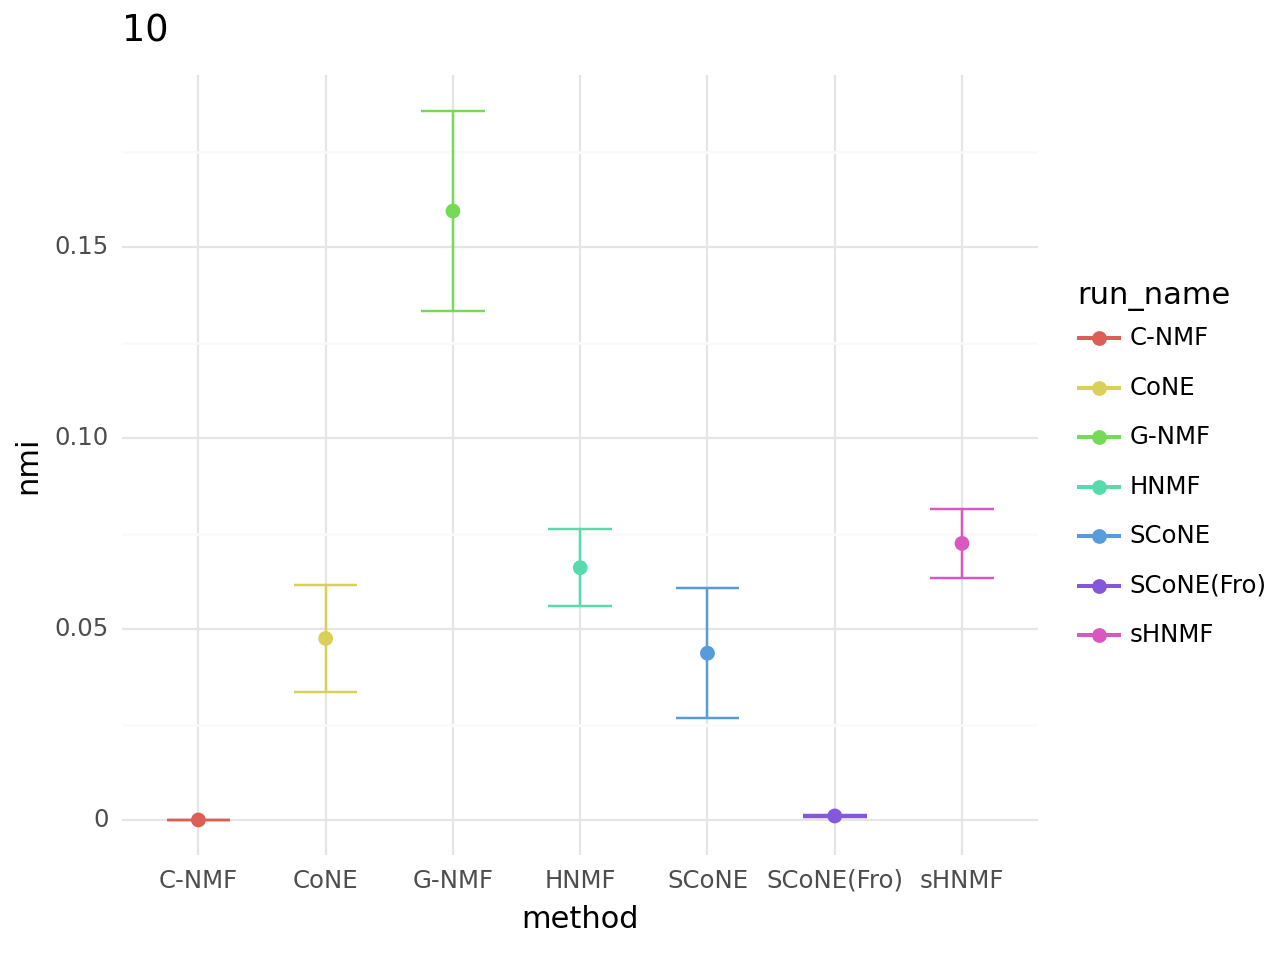

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


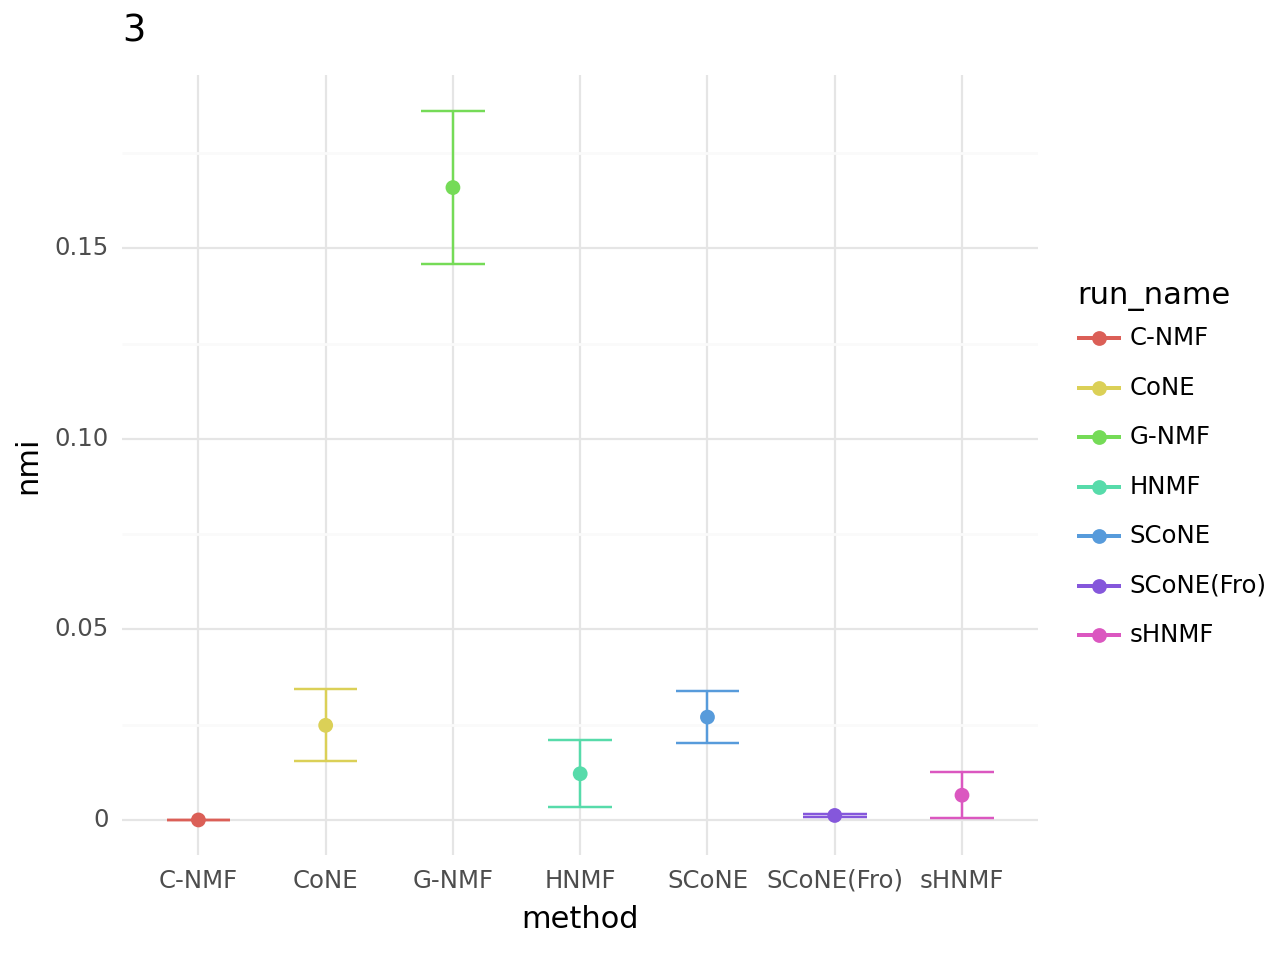

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


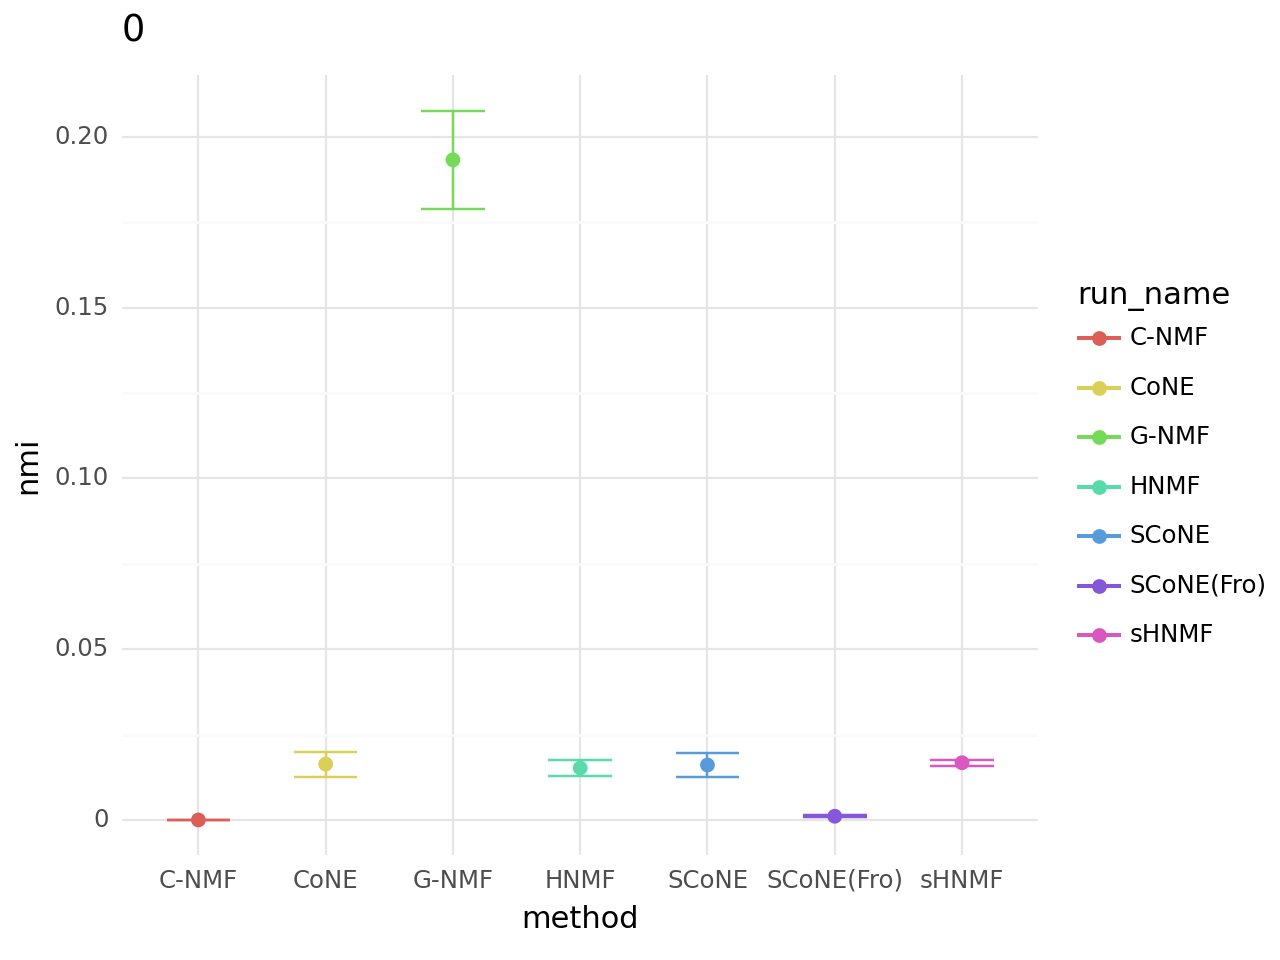

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


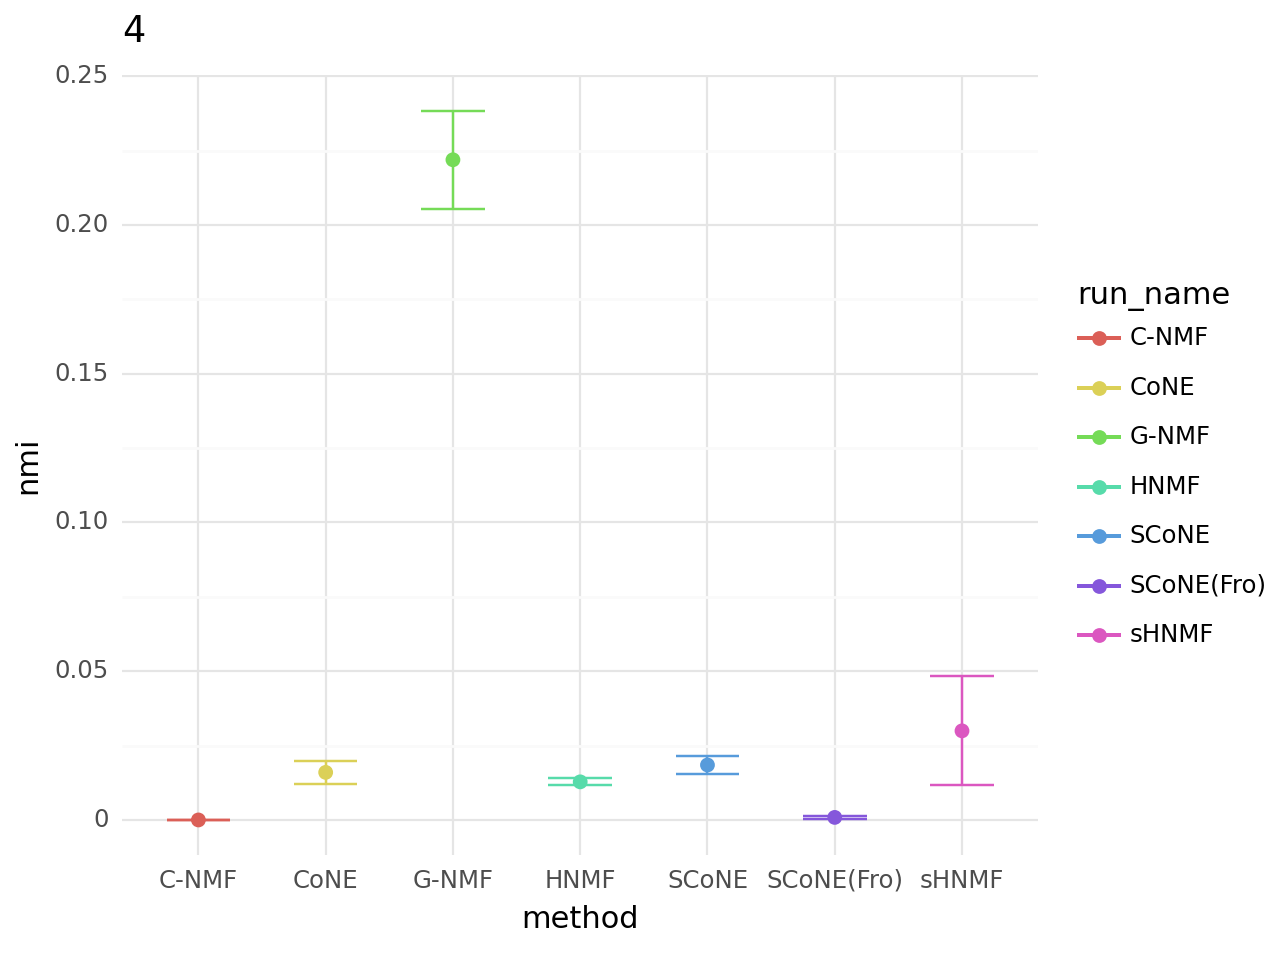

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


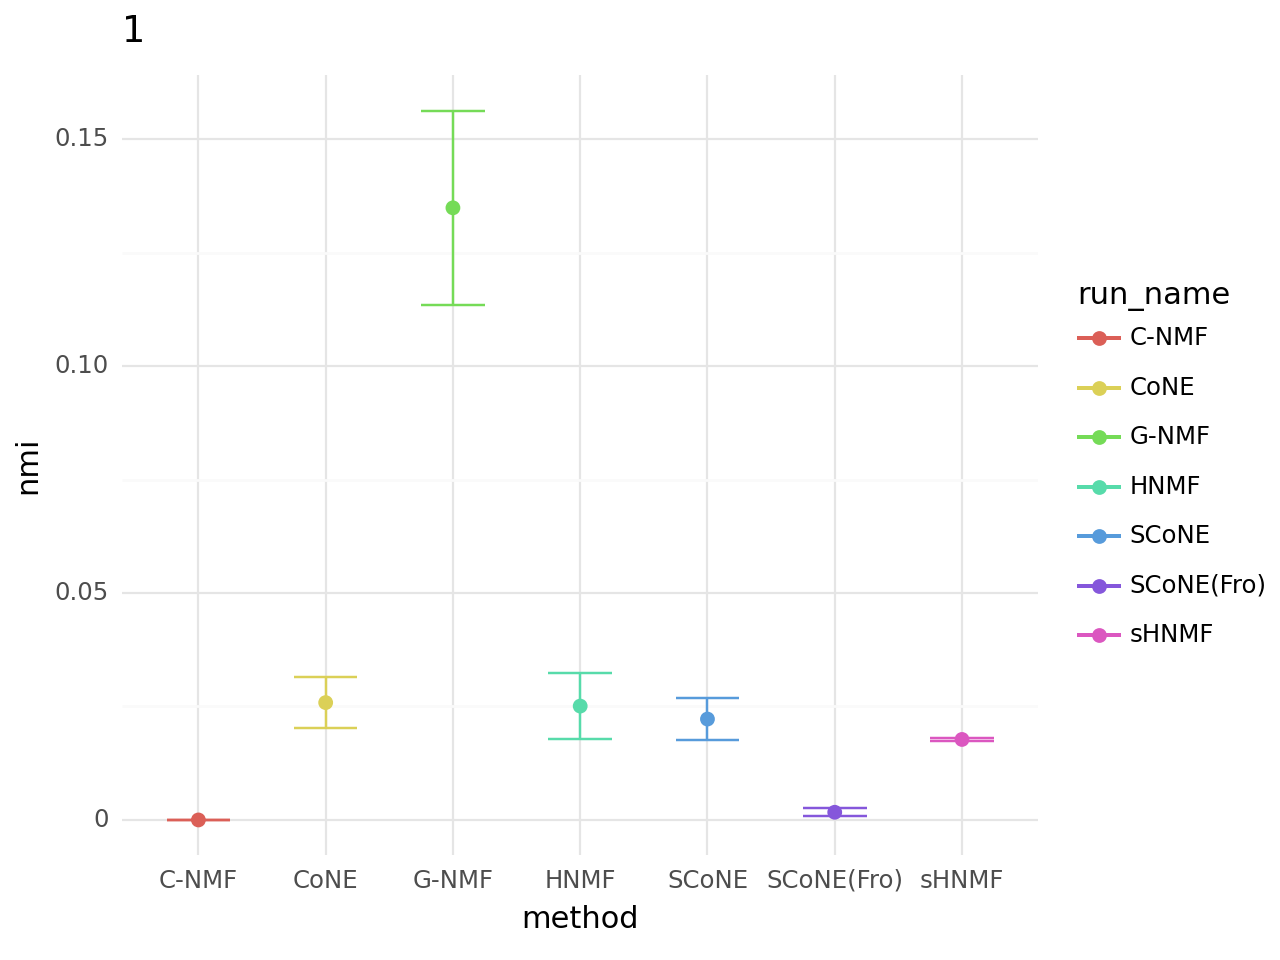

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


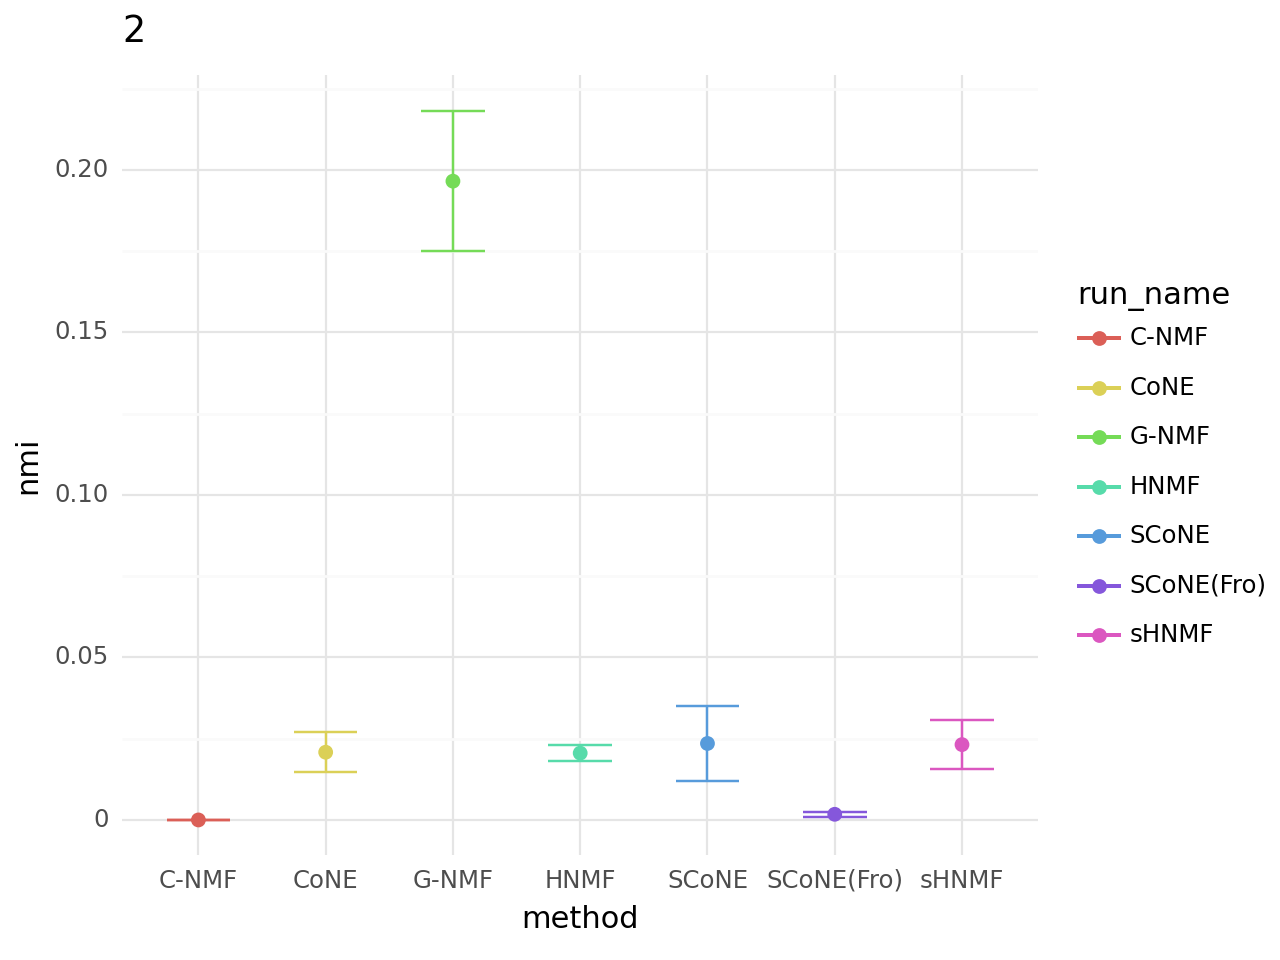

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


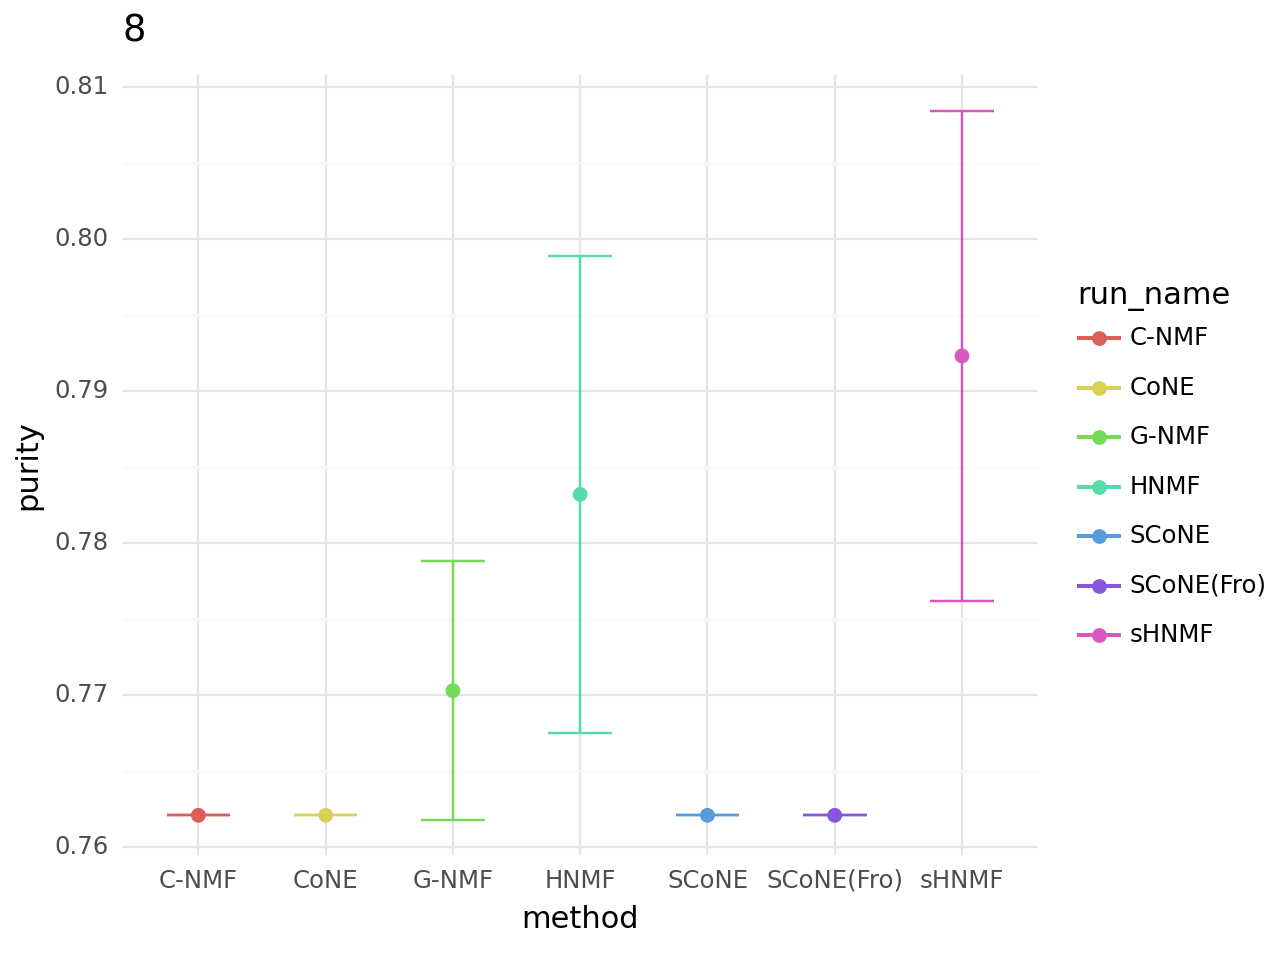

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


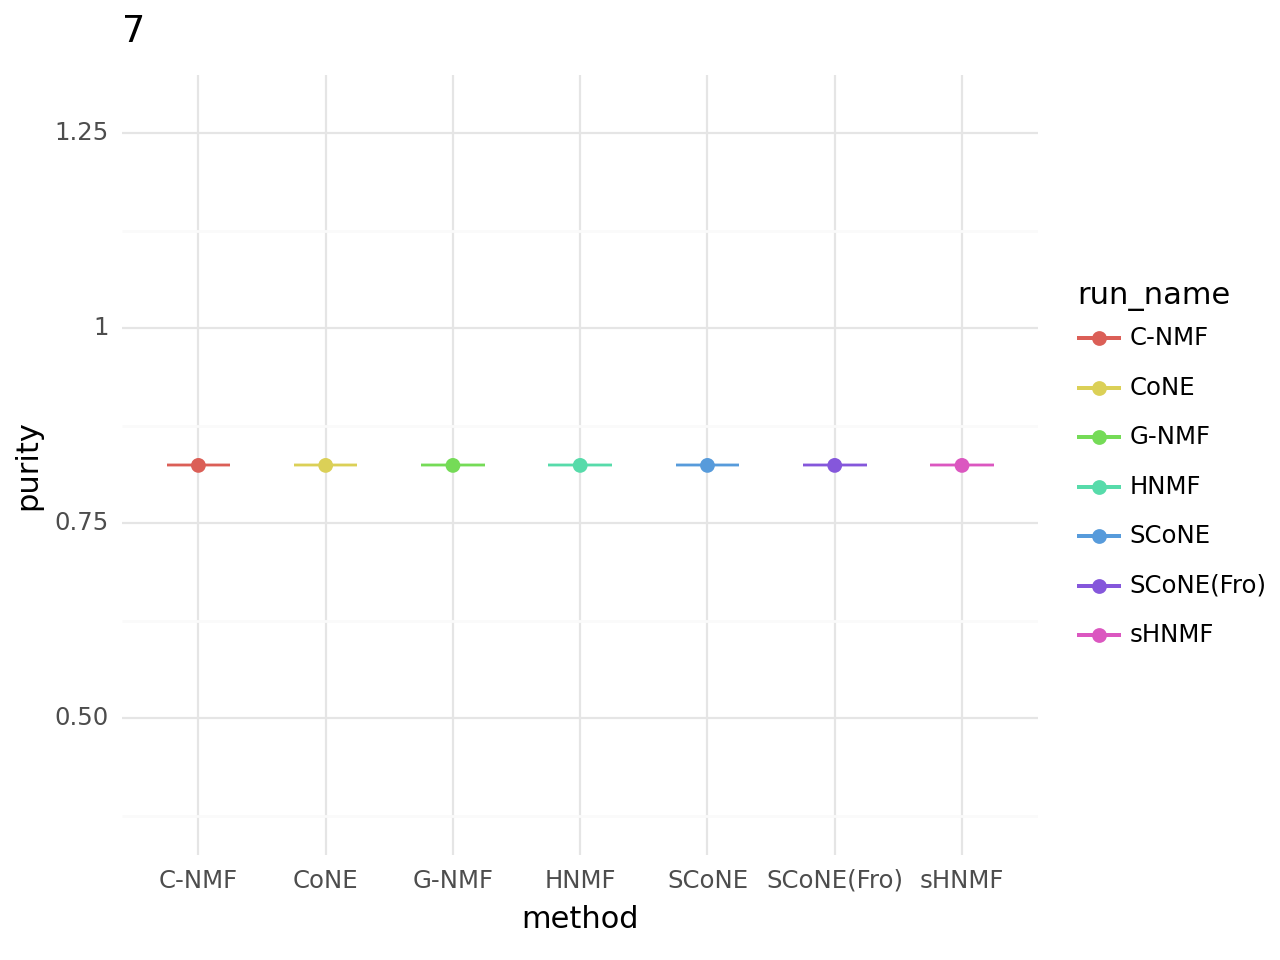

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


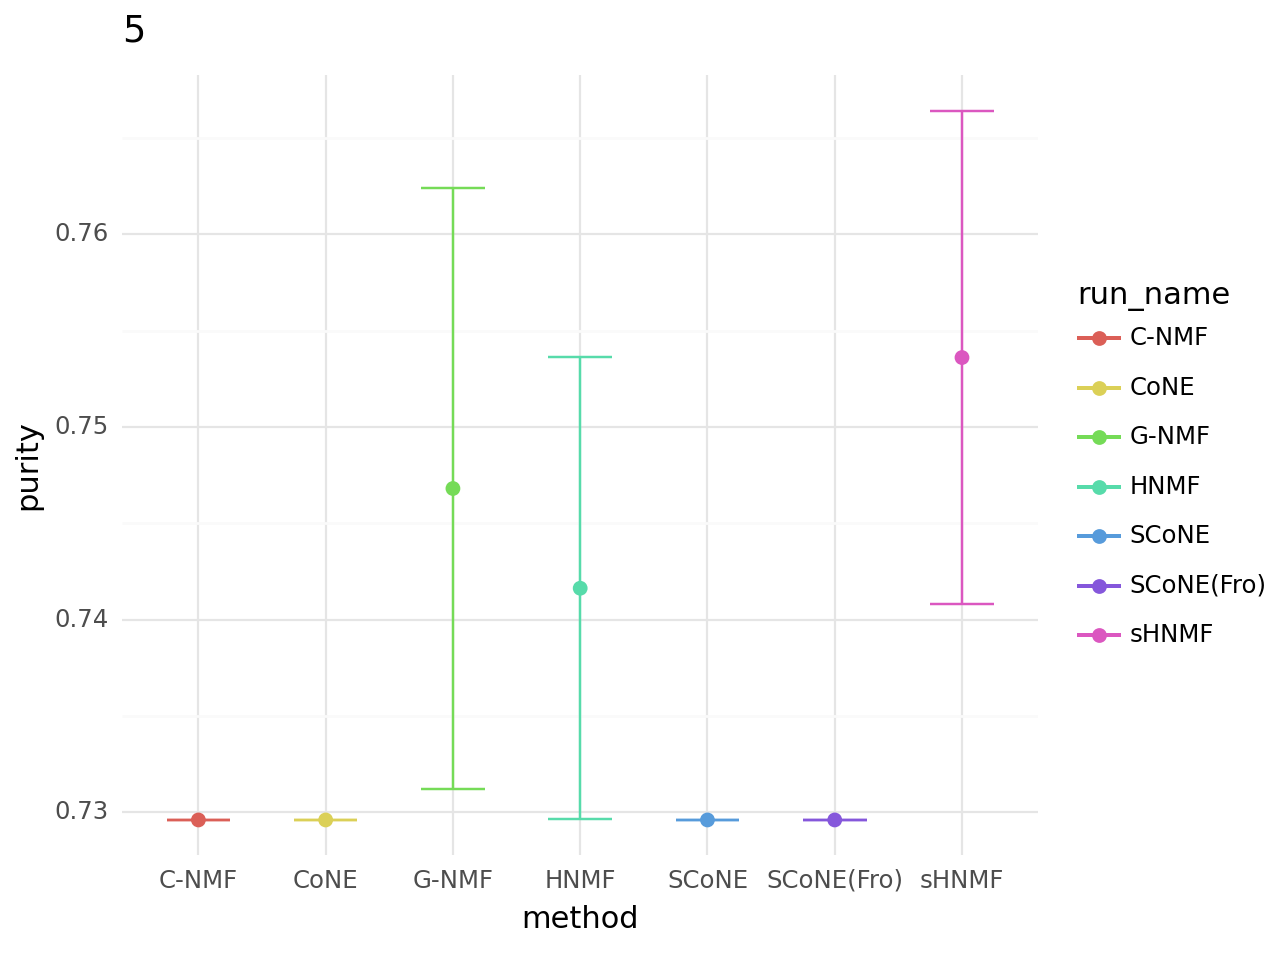

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


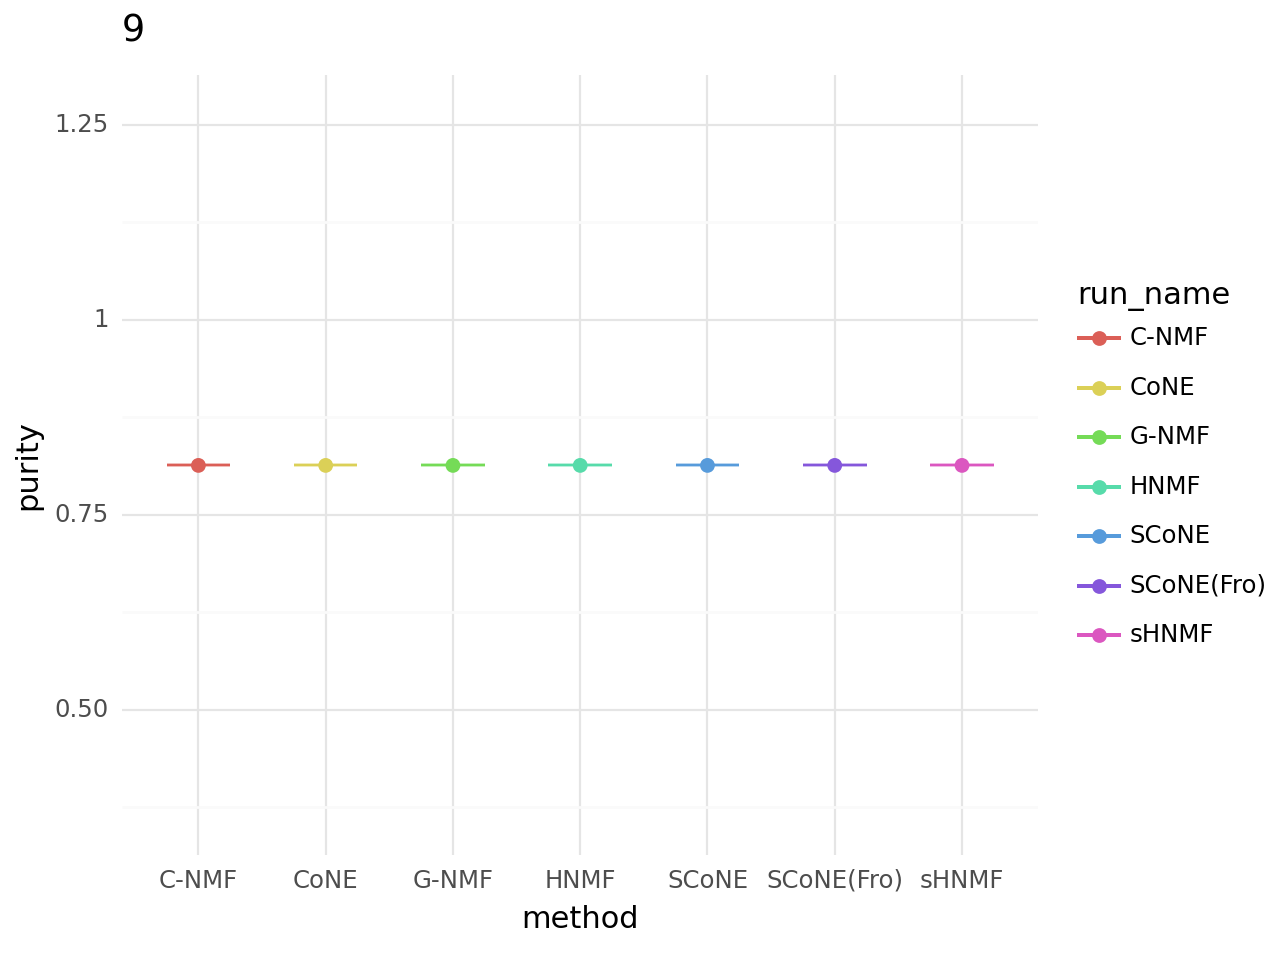

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


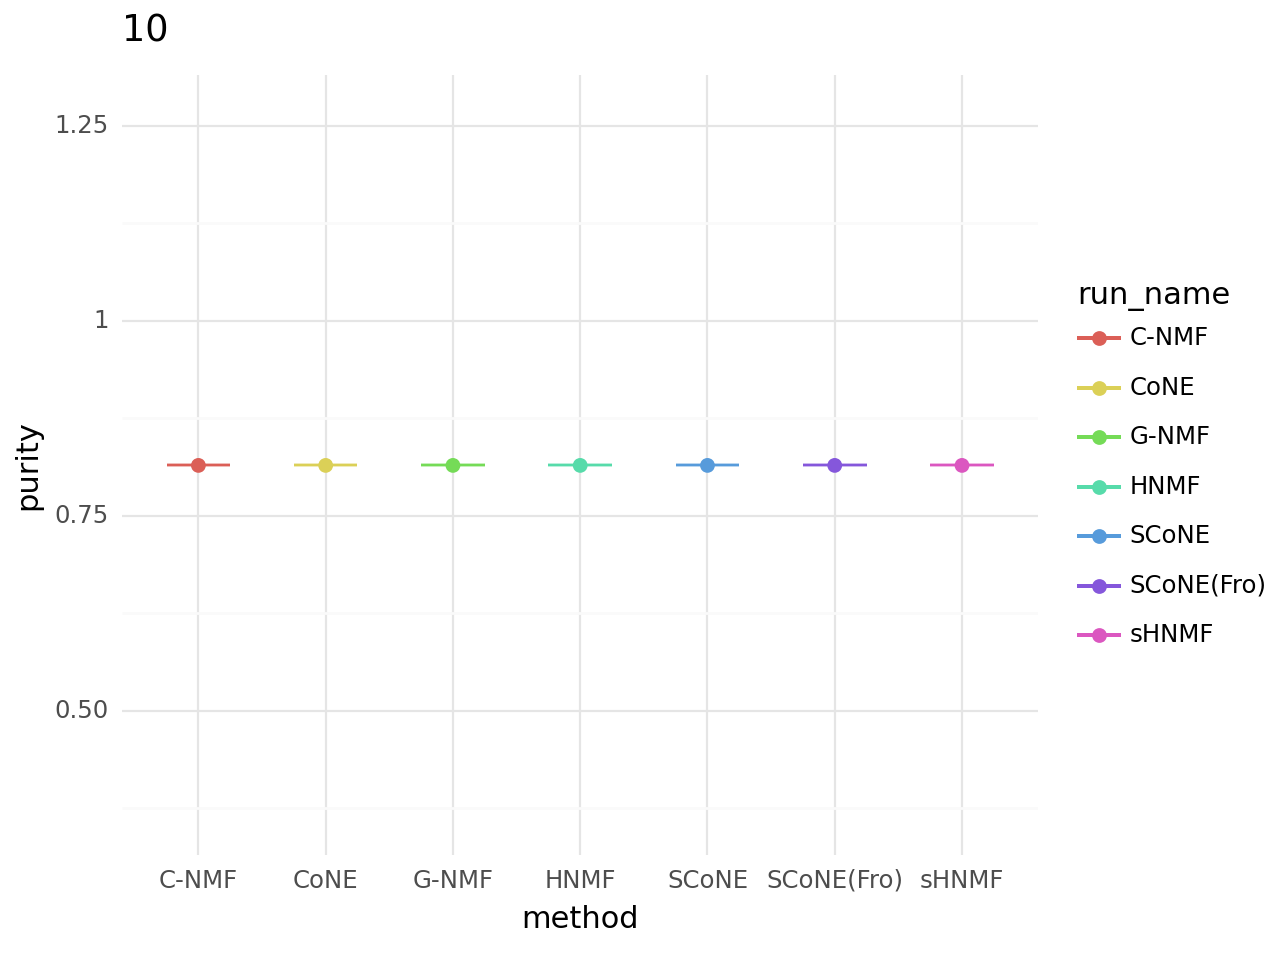

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


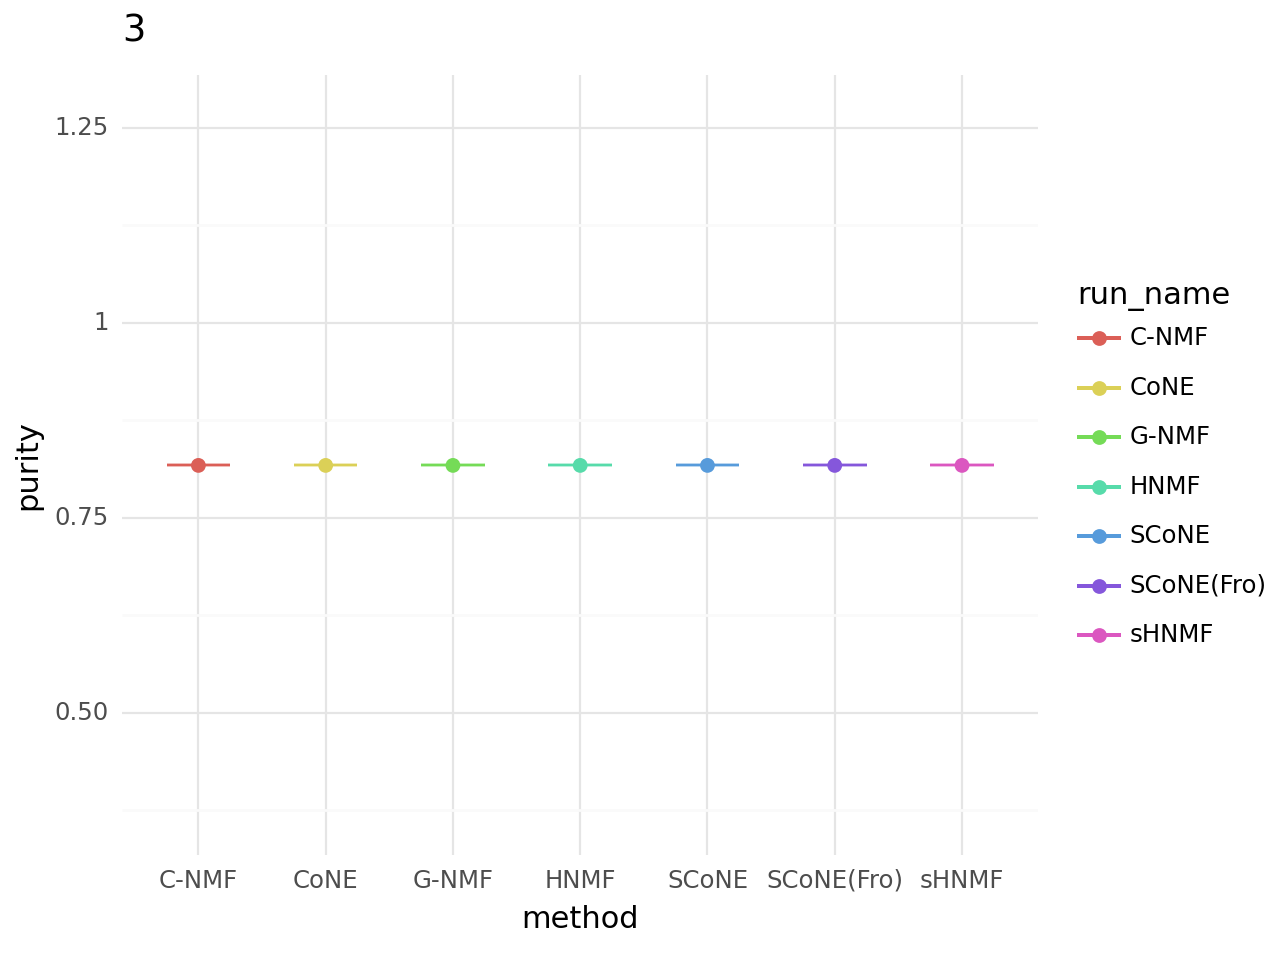

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


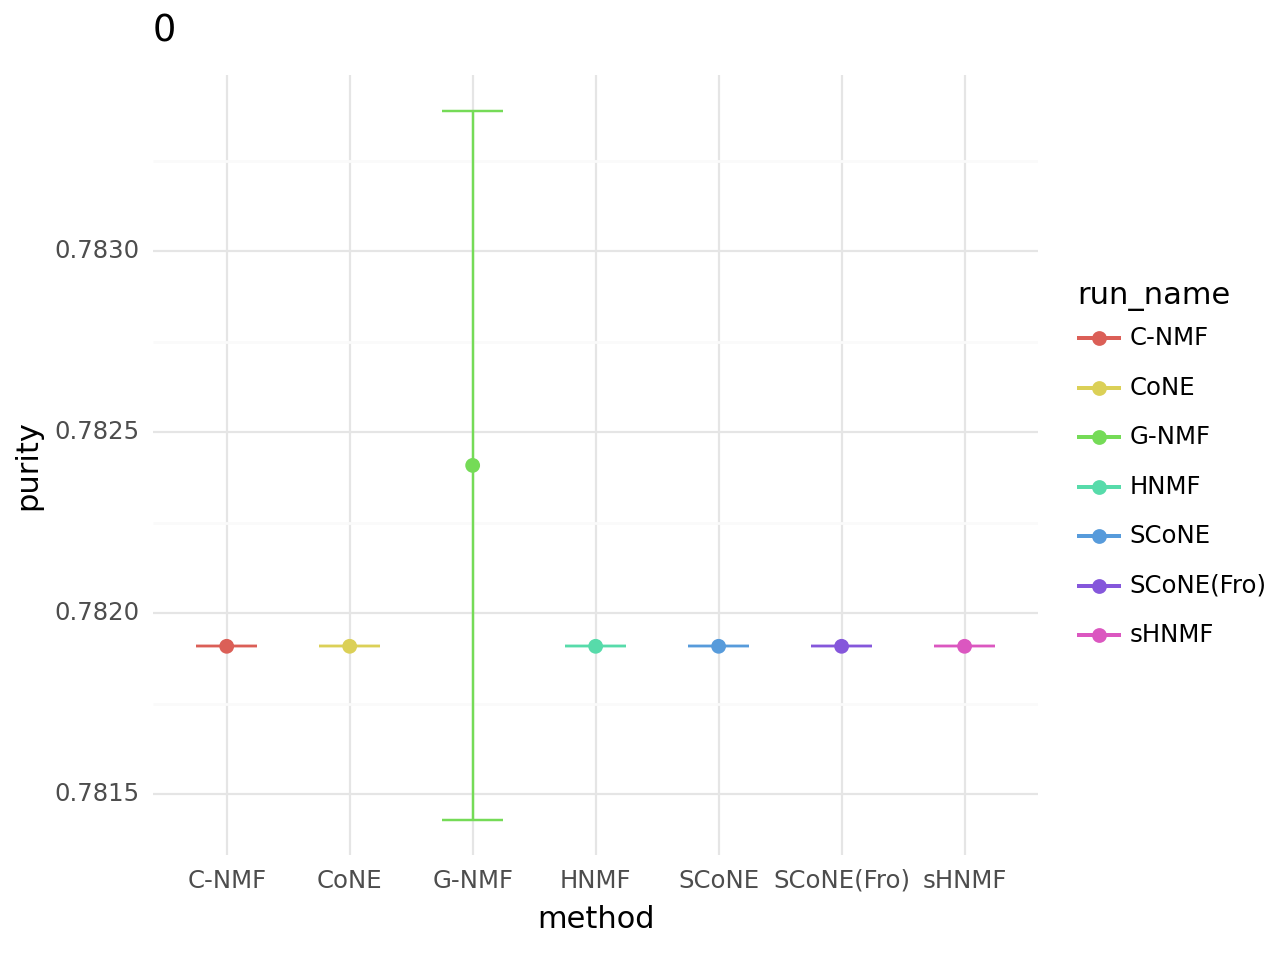

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


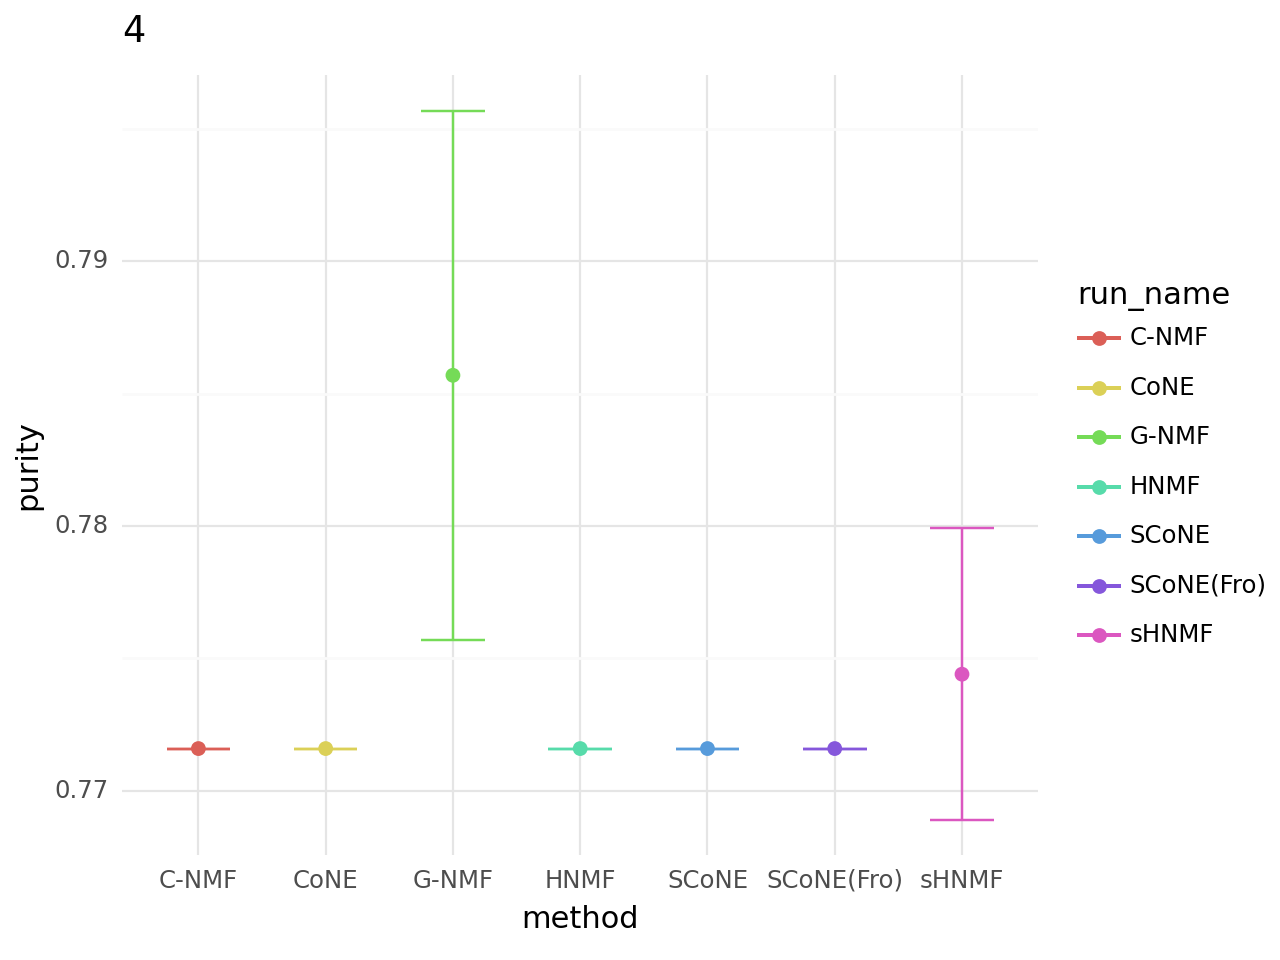

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


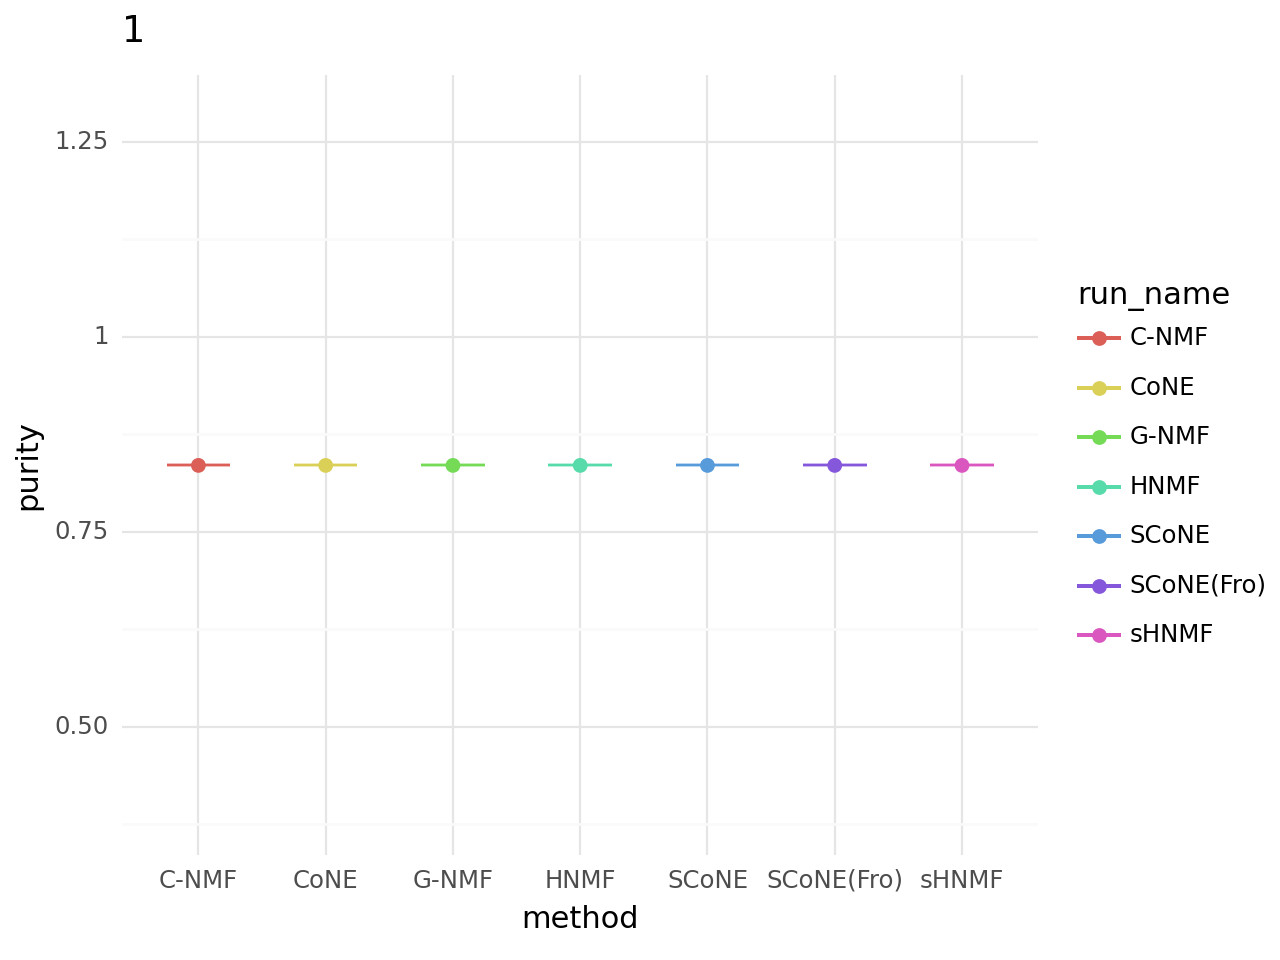

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


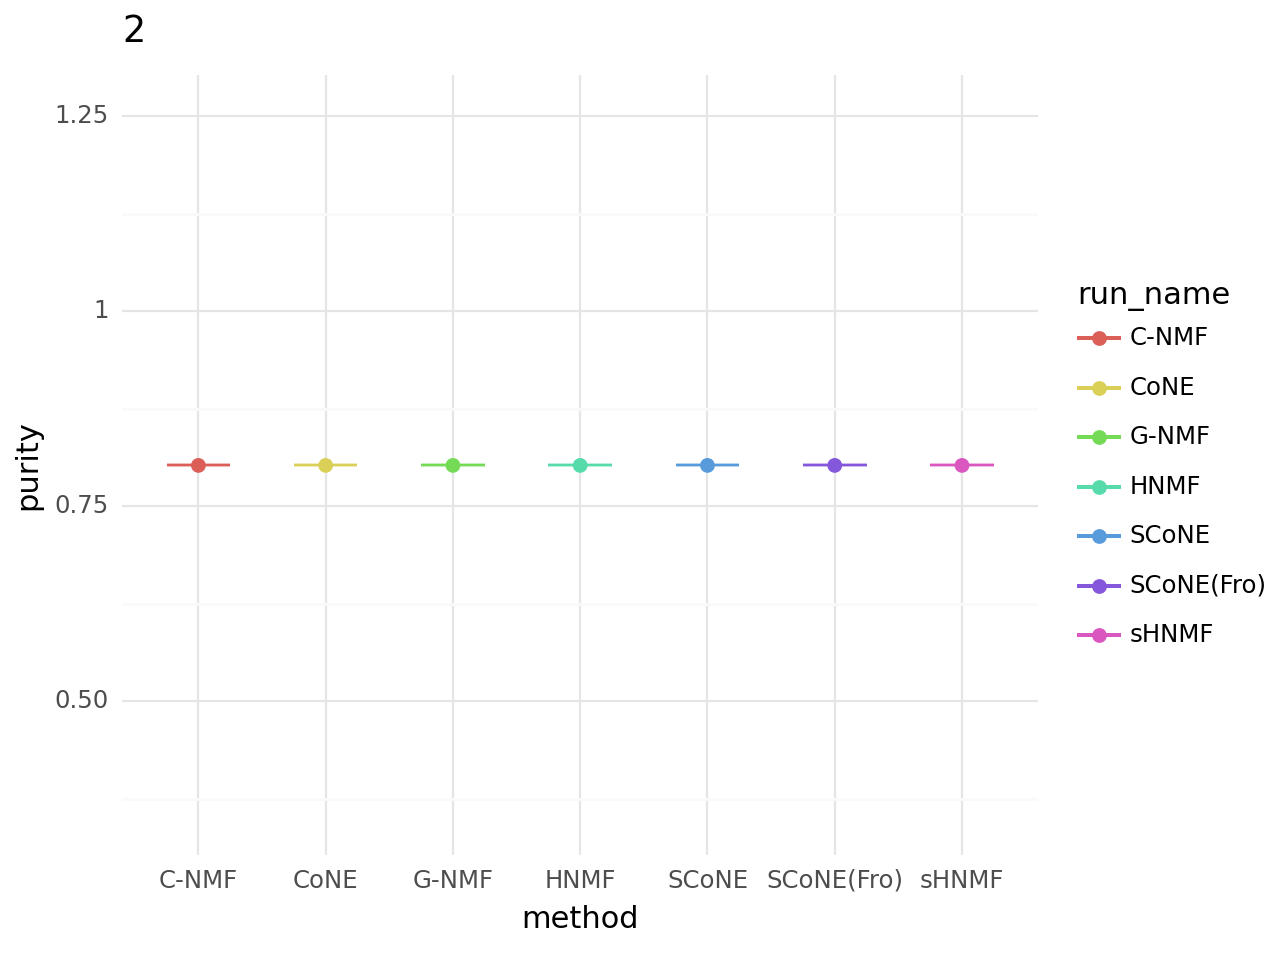

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


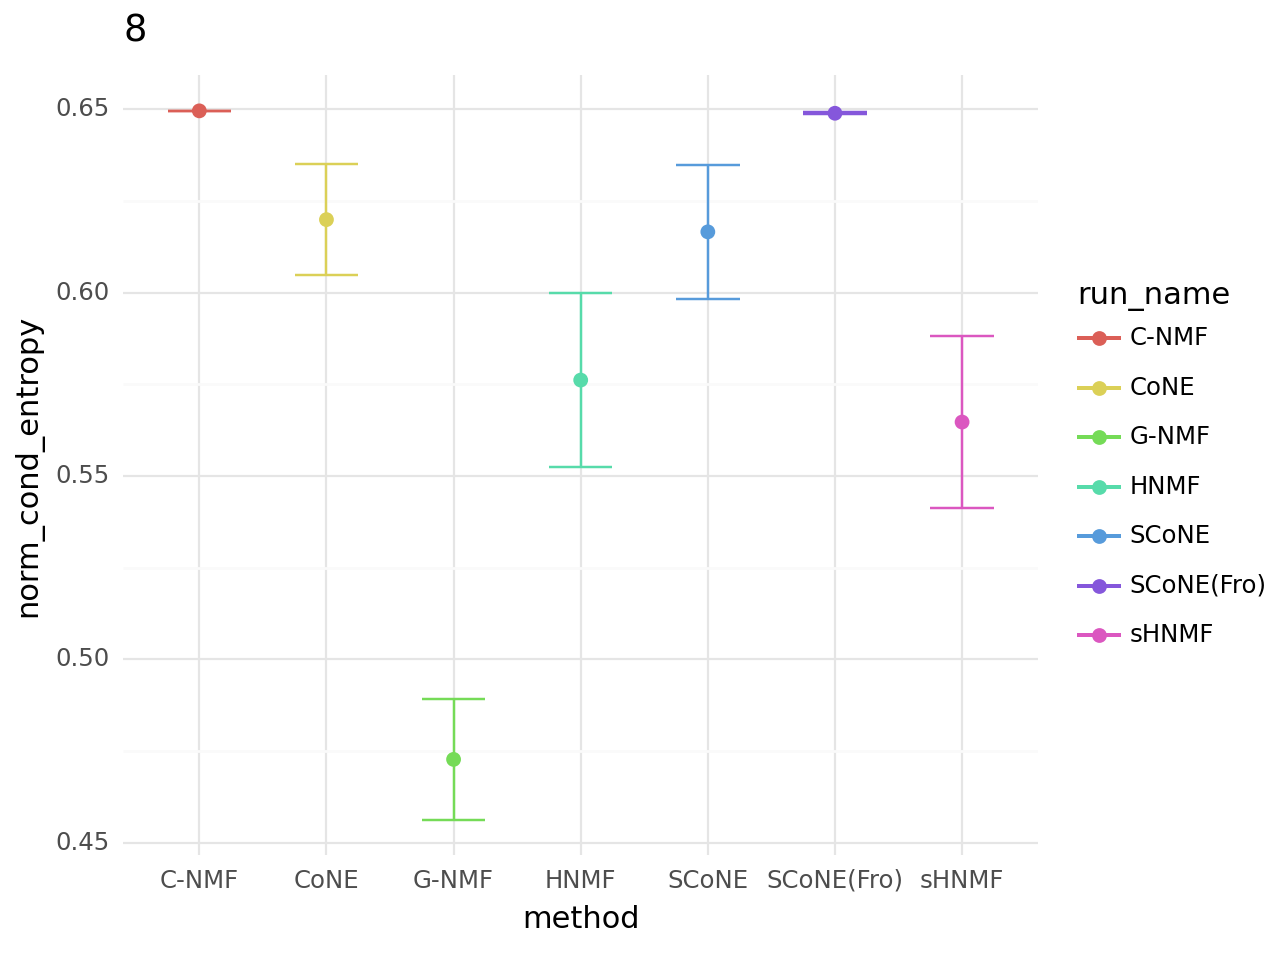

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


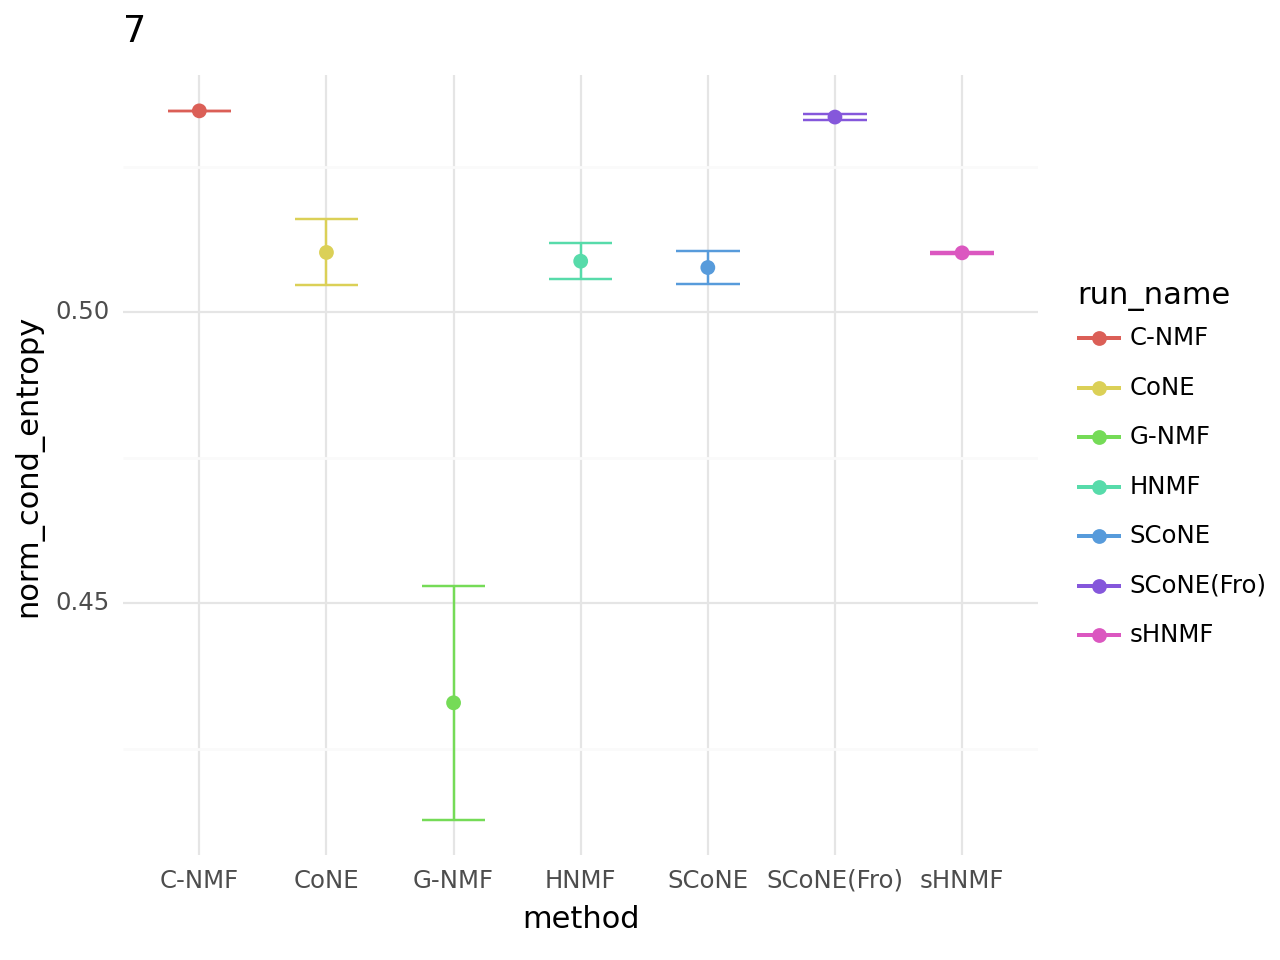

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


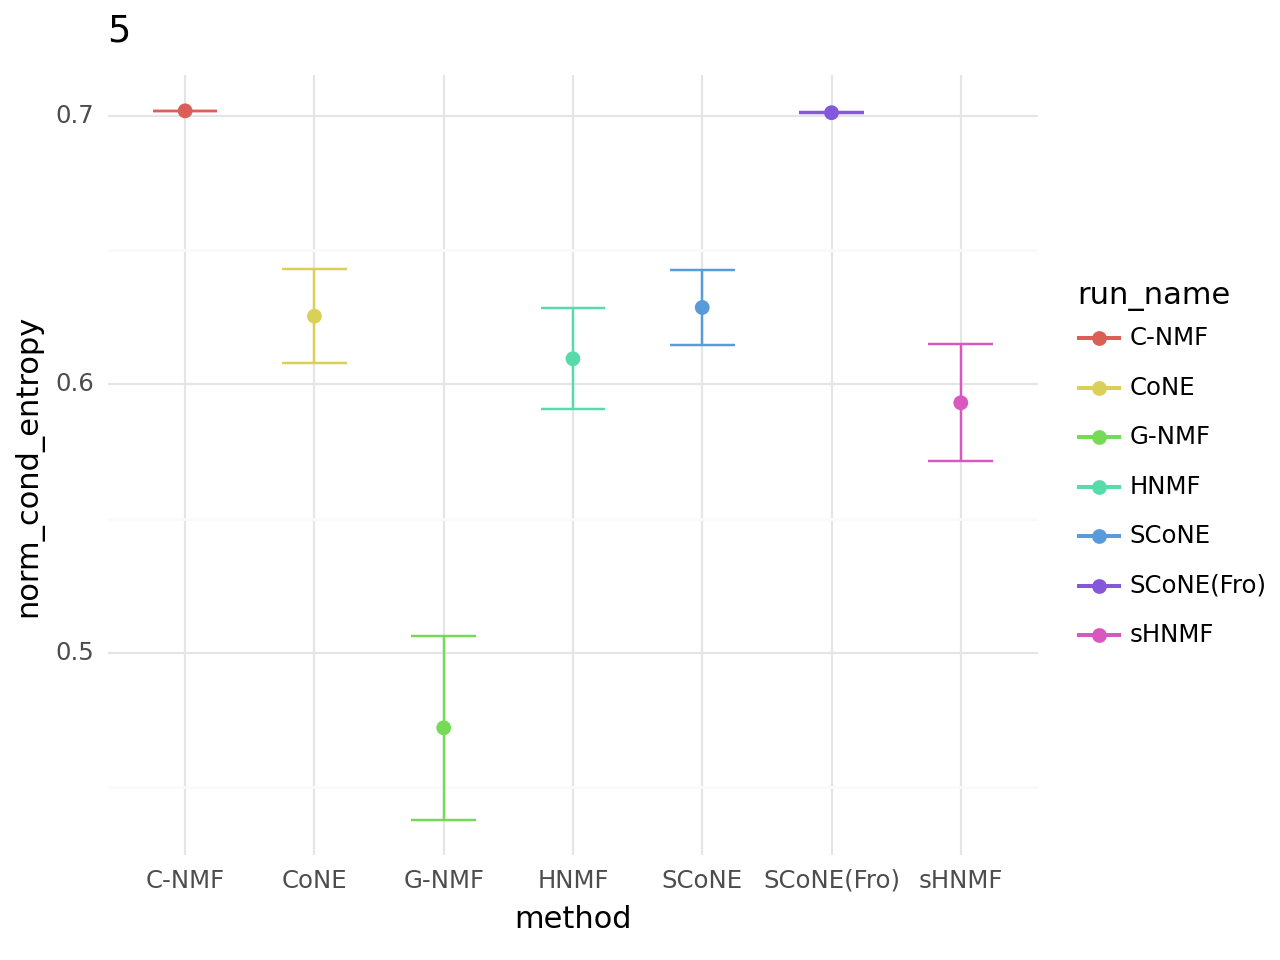

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


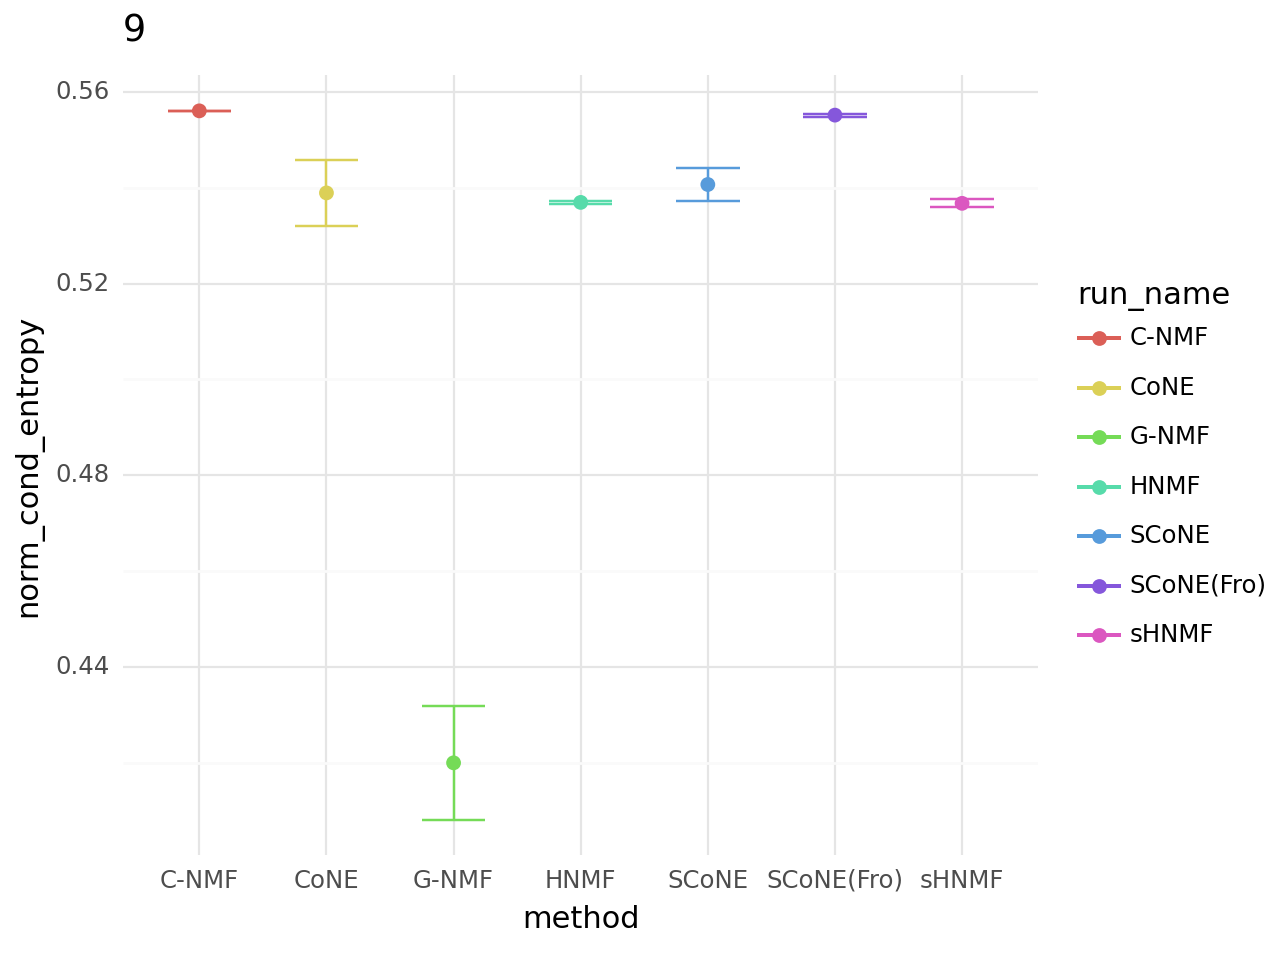

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


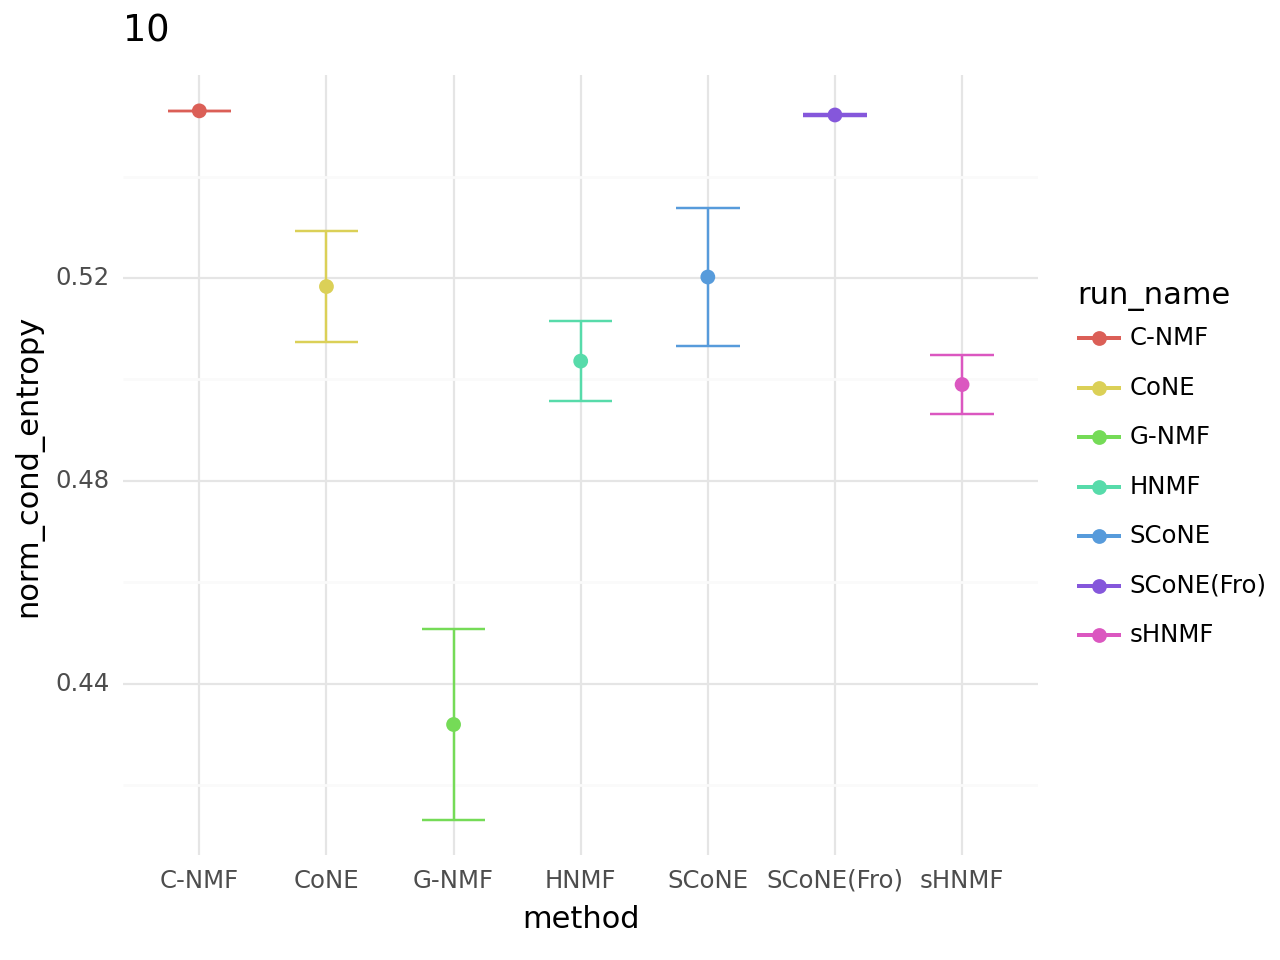

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


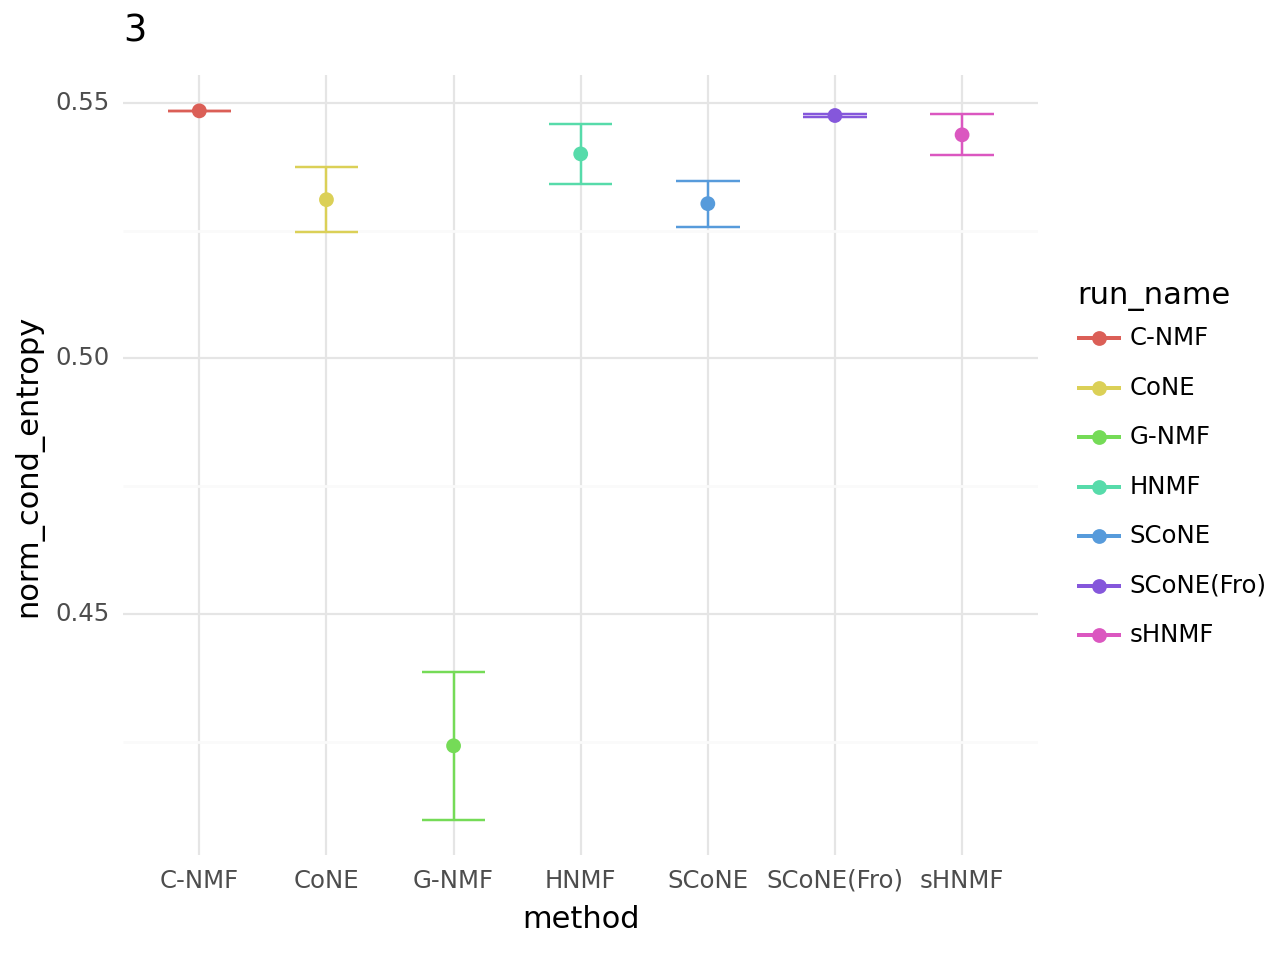

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


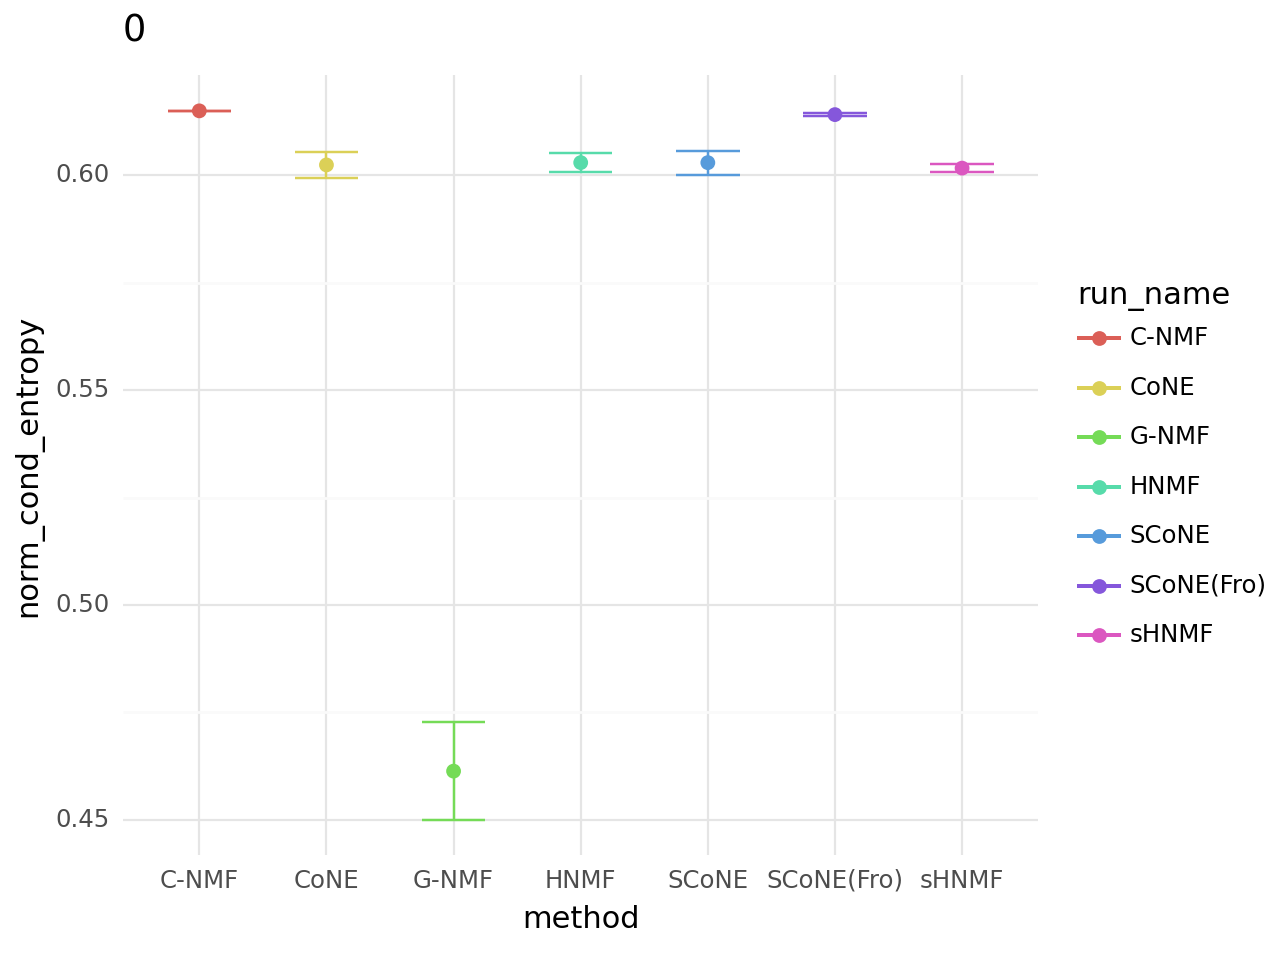

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


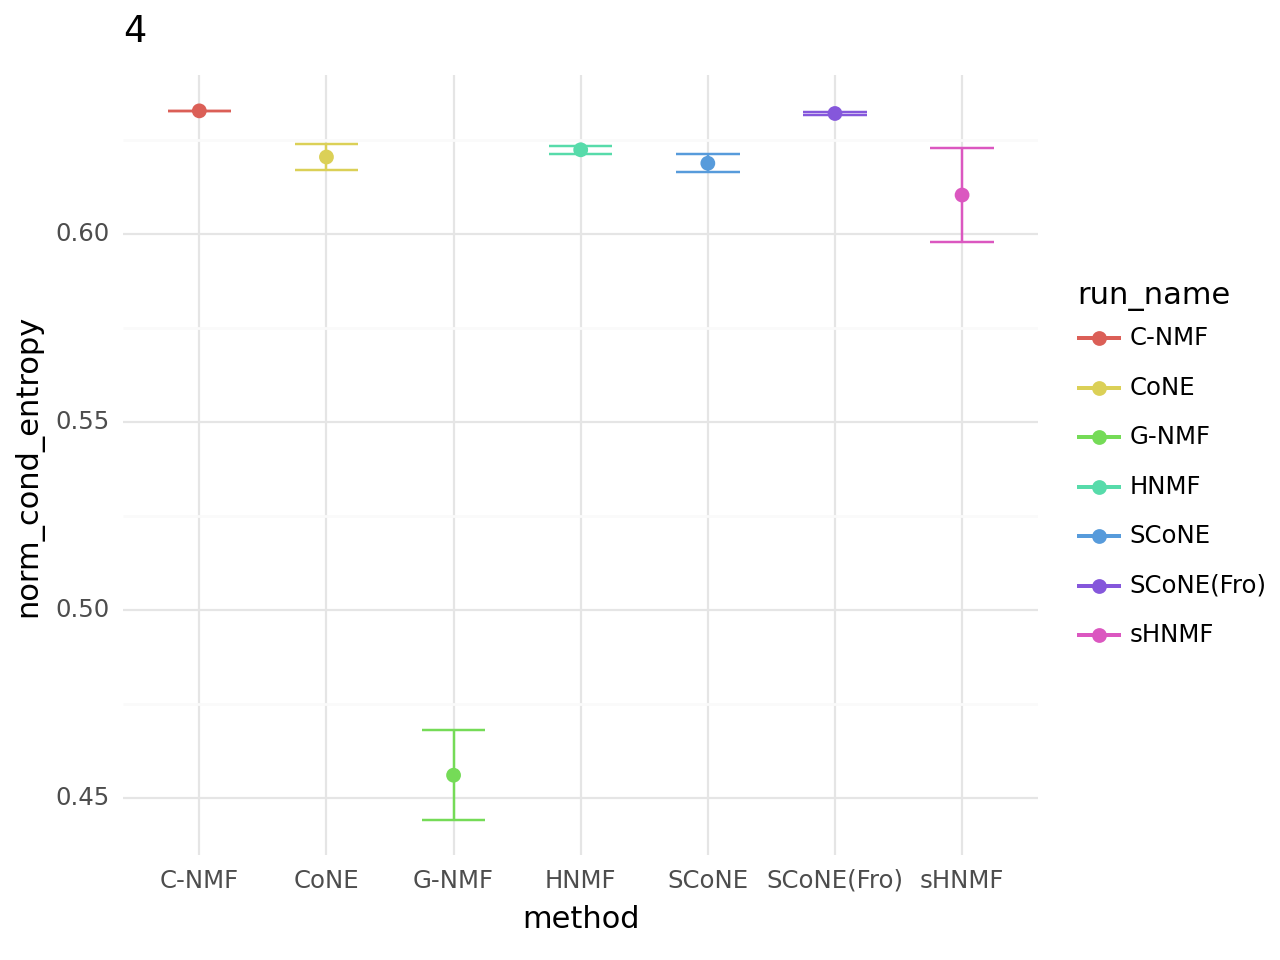

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


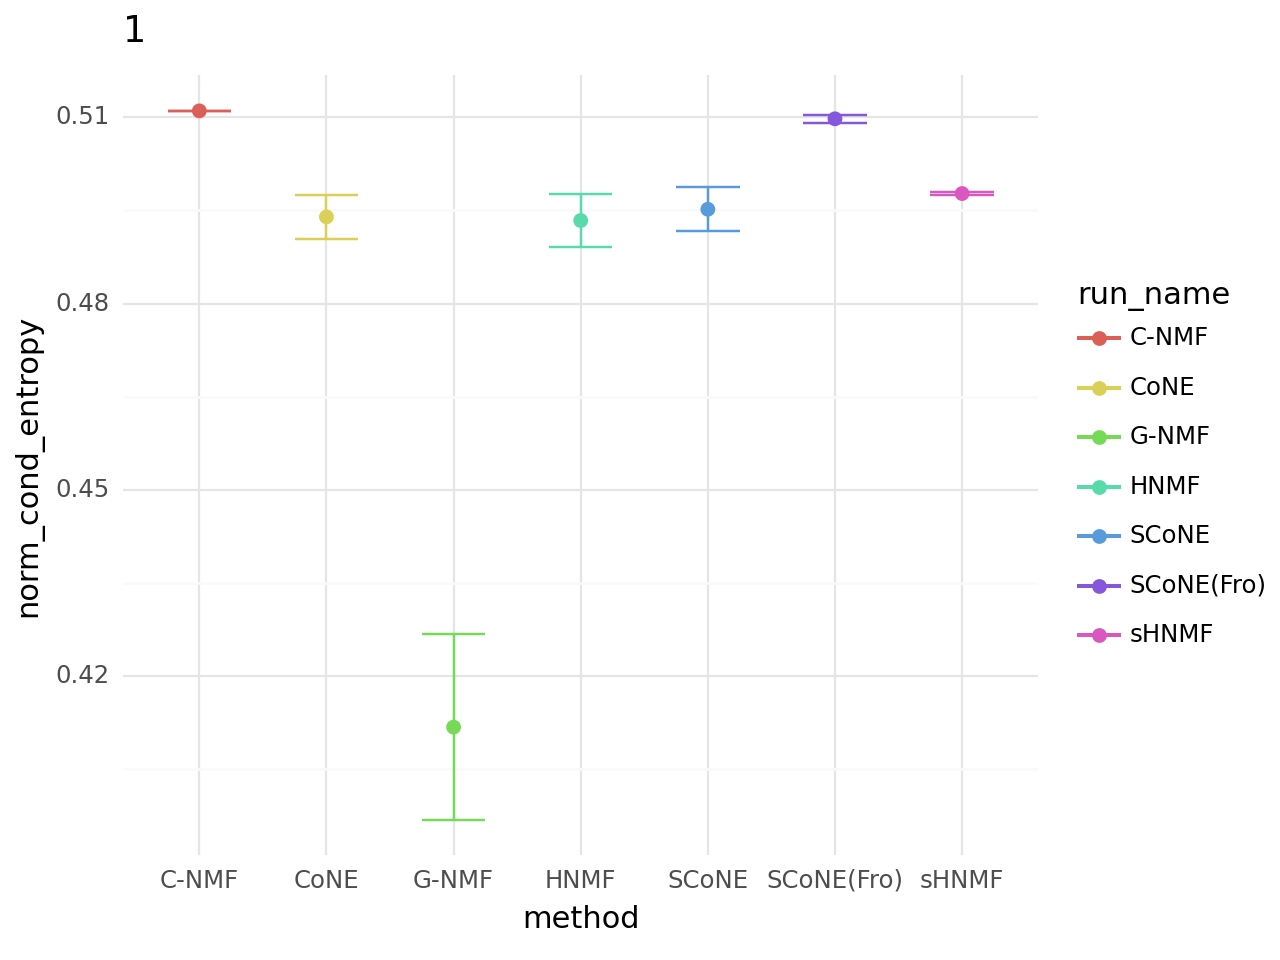

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


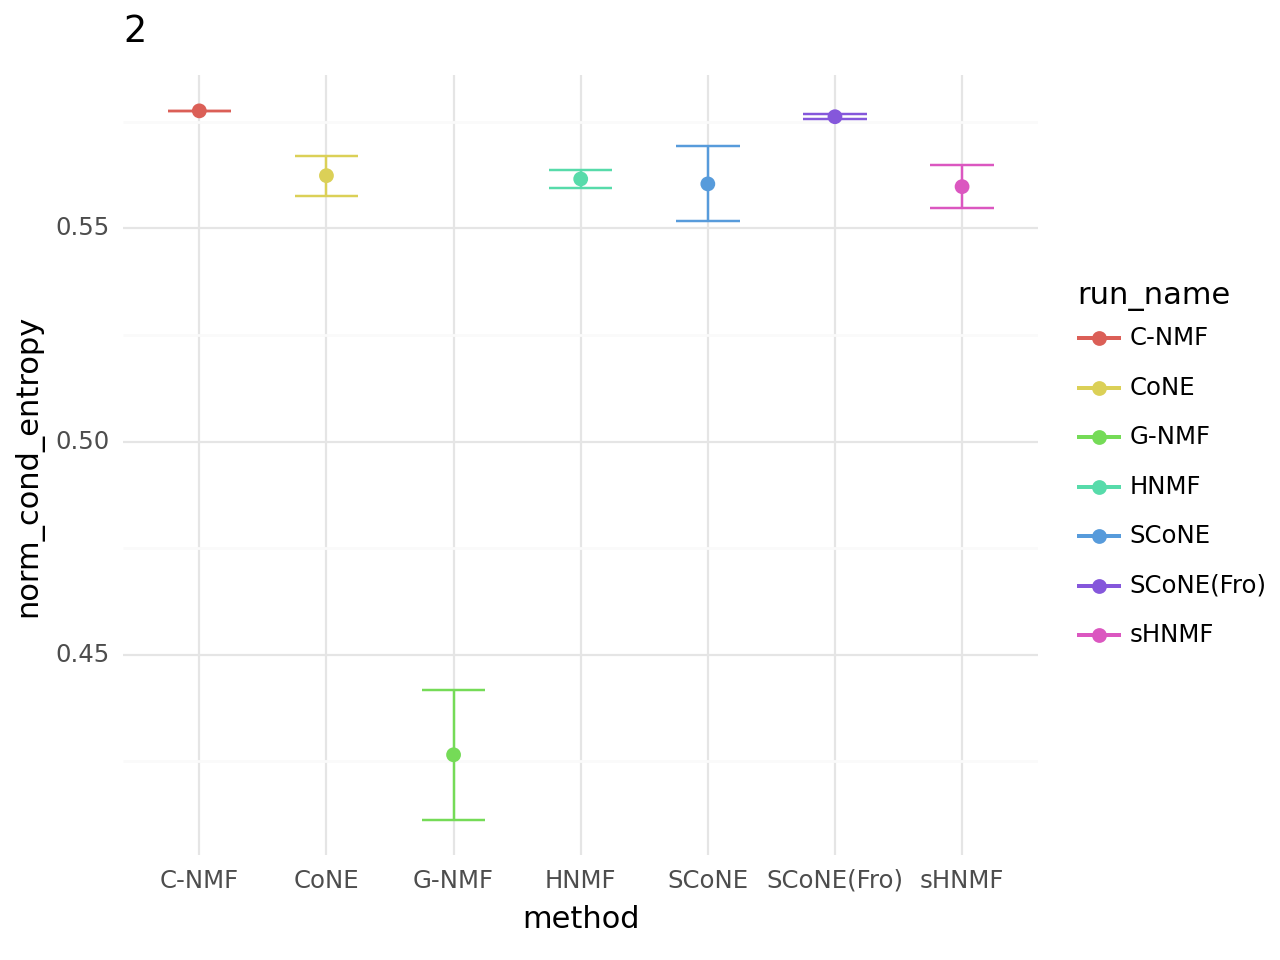

In [29]:
# do the same but across all 10 datasets
for metric in ['nmi','purity','norm_cond_entropy']:
    for dataset in all_runs['dataset'].unique():
        best = all_runs[all_runs['dataset']==dataset].copy()
        summary = (
            best.groupby(["run_name", "ps", "e", "g"])[metric]
                .agg(n='count', mean='mean', std='std').reset_index()
        )
        summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["n"])         # normal approx 95% CI
        summary["ymin"] = summary["mean"] - summary["ci95"]
        summary["ymax"] = summary["mean"] + summary["ci95"]
        p = (
        ggplot(summary, aes(x="run_name", y="mean", color="run_name", group="run_name"))
        + geom_line()
        + geom_point(size=2)
        + geom_errorbar(aes(ymin="ymin",ymax="ymax"))
        + labs(x="method", y=metric, title=dataset)
        + theme_minimal()
        + theme()
        )
        print(p)

In [ ]:
p = (
    ggplot(best, aes(x="params.e", y="metrics.mean_NMI", color="params.run_name", group="params.run_name"))
    + geom_line()
    + geom_point(size=2)
    + facet_grid('params.ps ~ params.num_markers_assoc')
    + labs(x="e", y="NMI", title="NMI")
    + theme_minimal()
    + theme()
)
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 20 rows containing missing values.


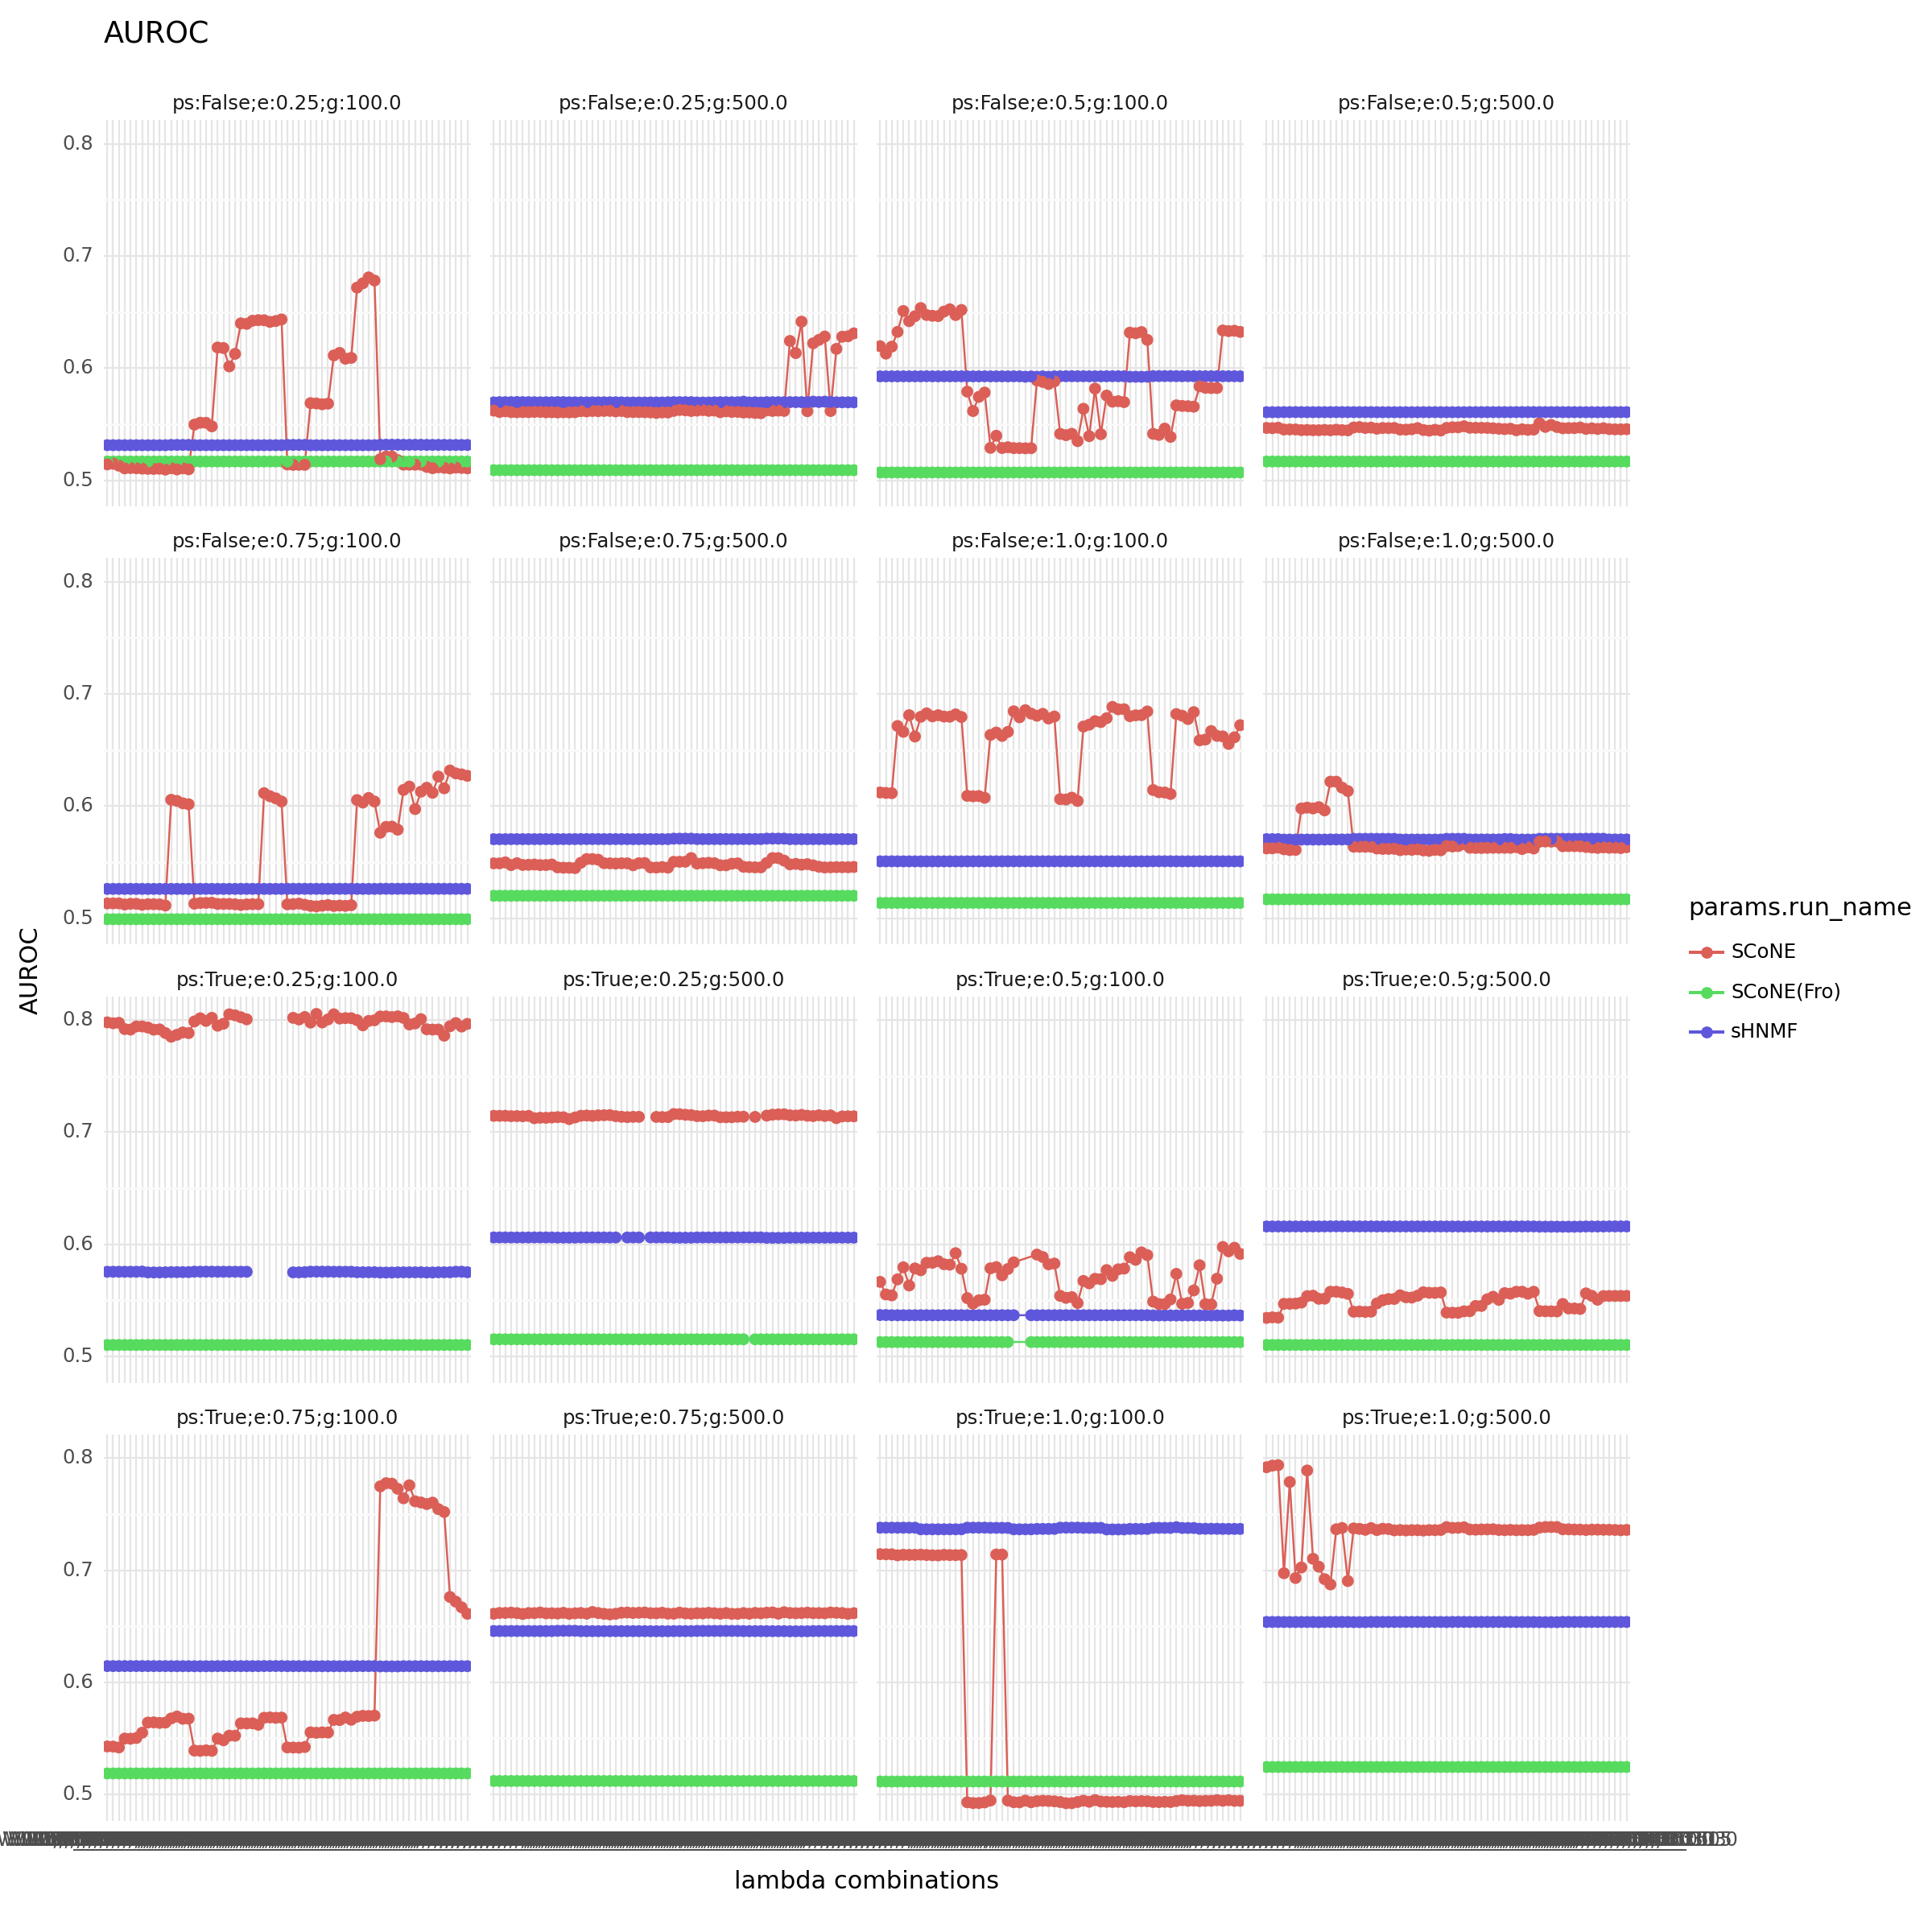

In [82]:
all_runs['lambda_combo'] = 'W:' + all_runs['params.lambda_W'].astype(str)+ ';H_G:' + all_runs['params.lambda_H_G'].astype(str) + ';H_C:' + all_runs['params.lambda_H_C'].astype(str)
all_runs['params_combo'] =  'ps:' + all_runs['params.ps'].astype(str) + ';e:' + all_runs['params.e'].astype(str) + ';g:' + all_runs['params.num_markers_assoc'].astype(str)
p = (
    ggplot(all_runs, aes(x="lambda_combo", y="metrics.mean_AUROC", color="params.run_name", group="params.run_name"))
    + geom_line()
    + geom_point(size=2)
    + facet_wrap('params_combo')
    + labs(x="lambda combinations", y="AUROC", title="AUROC")
    + theme_minimal()
    + theme(figure_size=(12,12))
)
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 20 rows containing missing values.


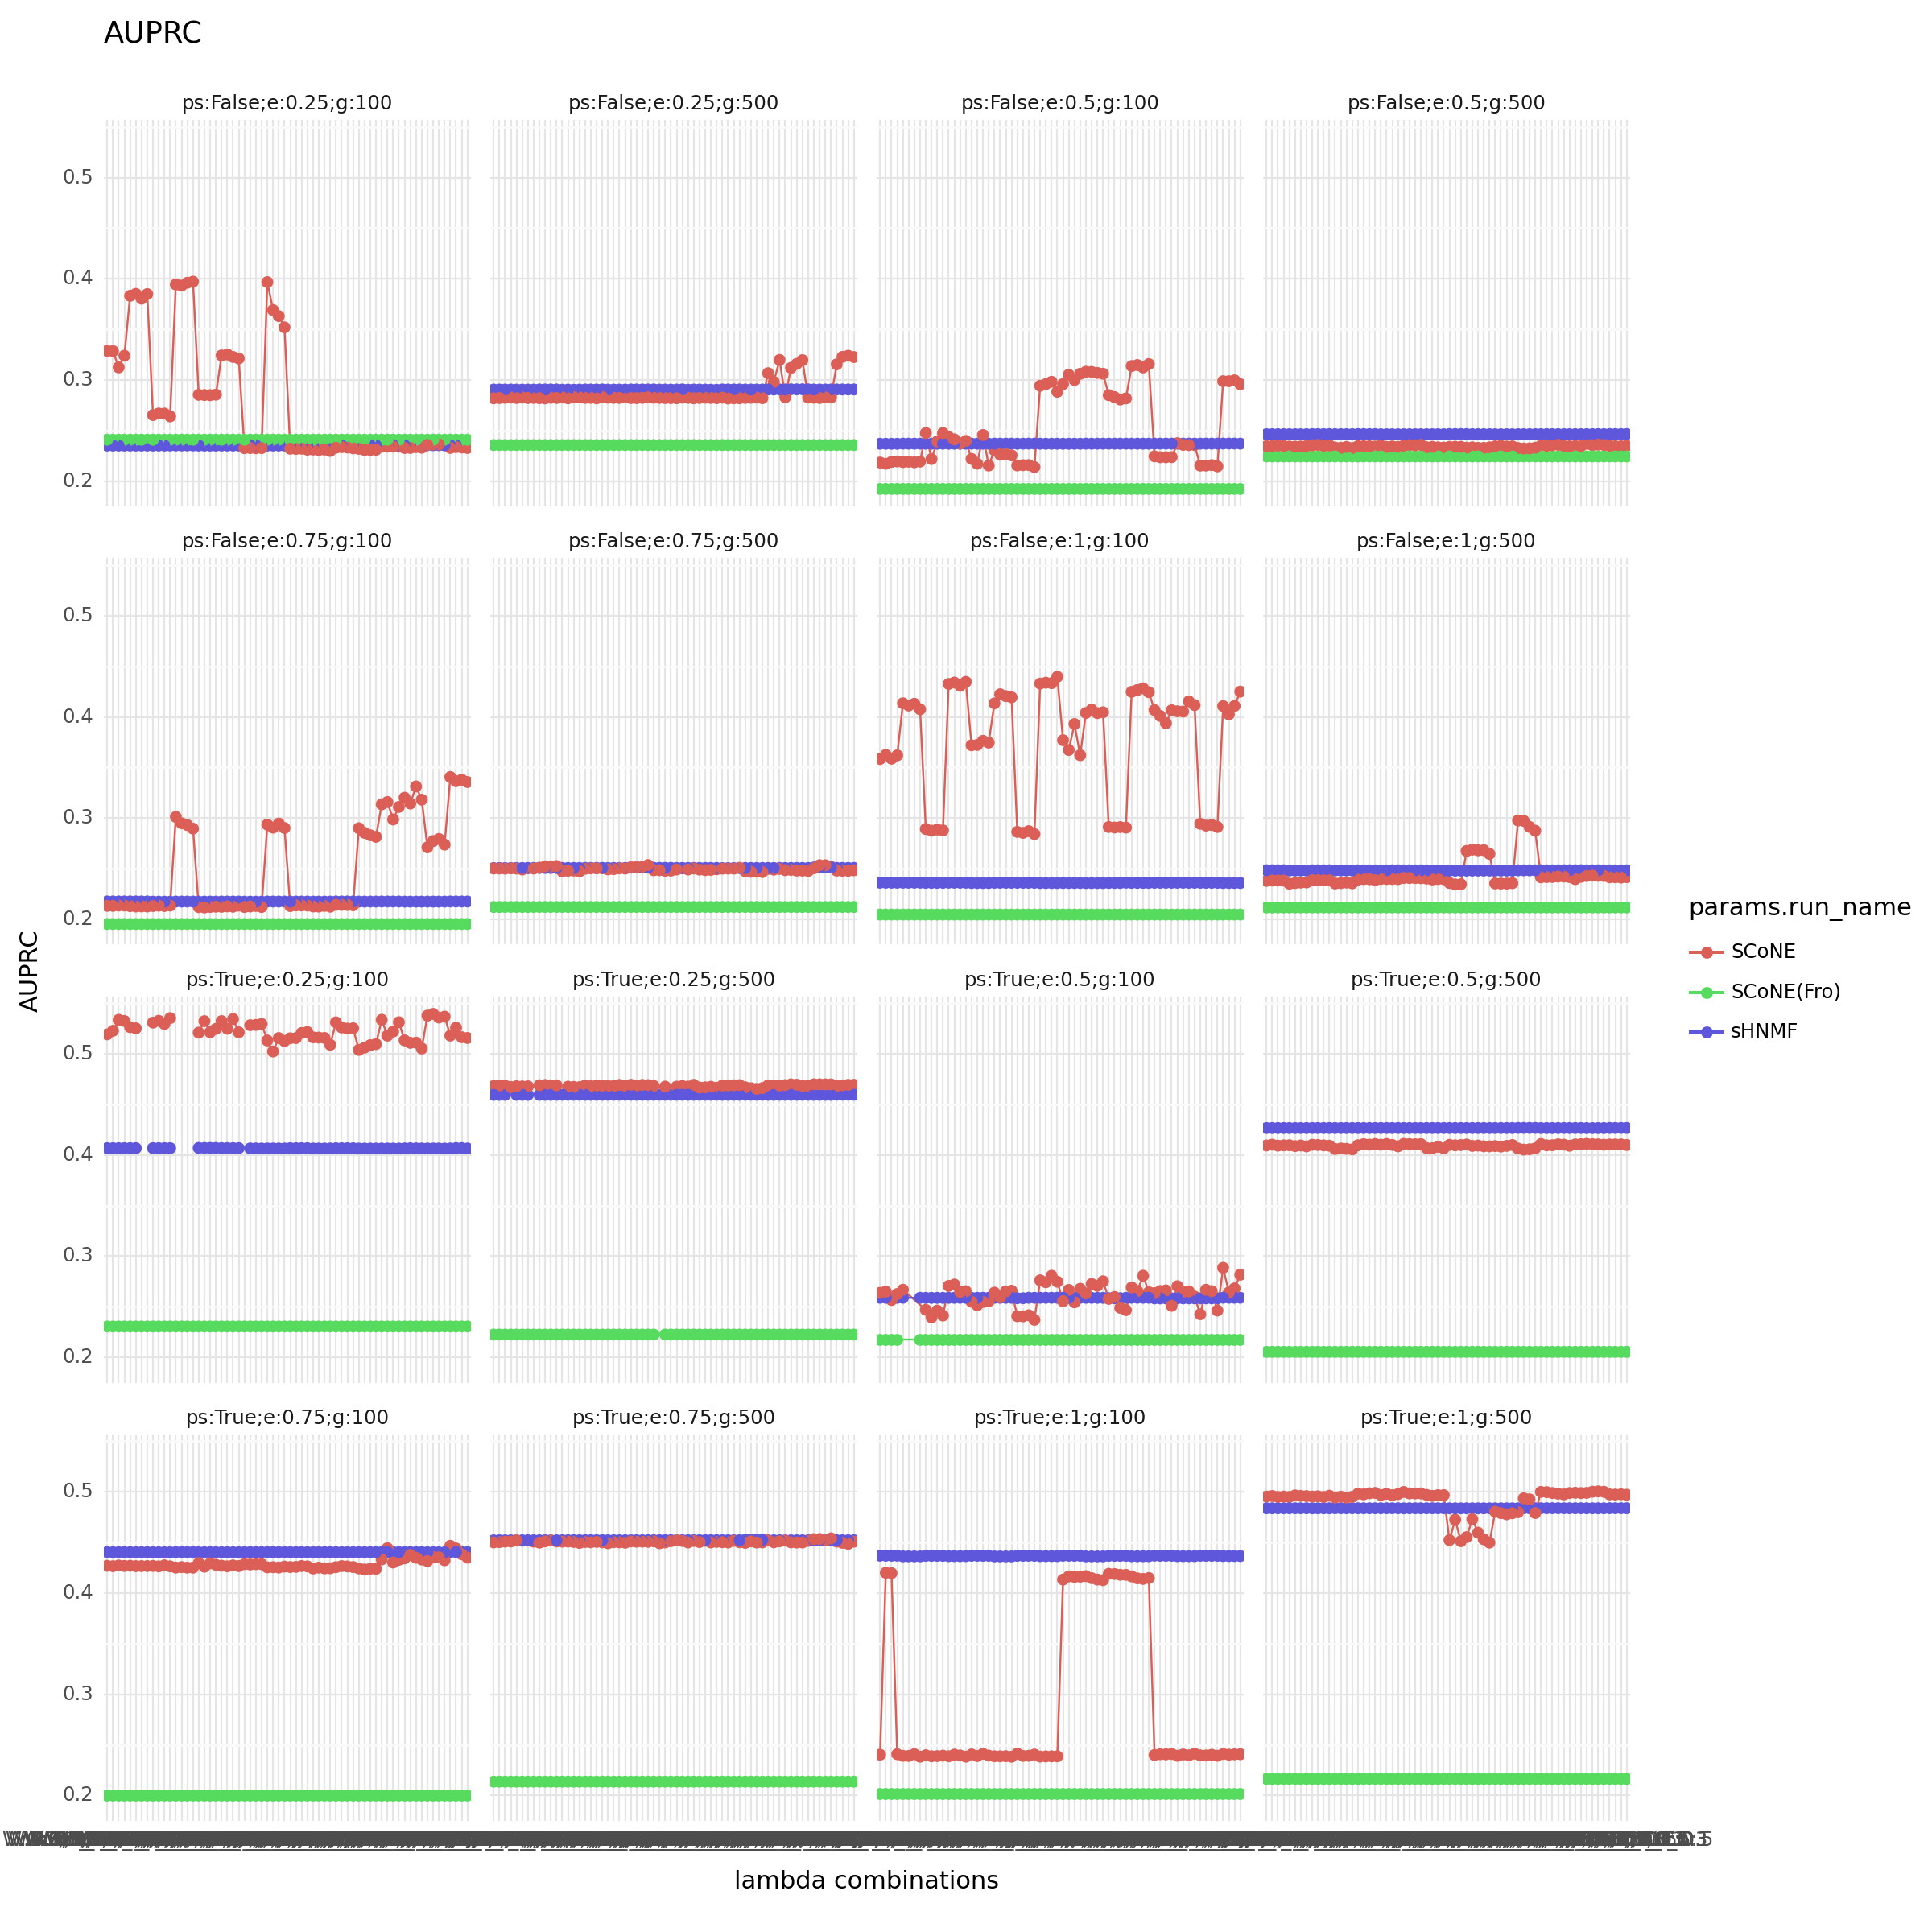

In [34]:
p = (
    ggplot(all_runs, aes(x="lambda_combo", y="metrics.mean_AUPRC", color="params.run_name", group="params.run_name"))
    + geom_line()
    + geom_point(size=2)
    + facet_wrap('params_combo')
    + labs(x="lambda combinations", y="AUPRC", title="AUPRC")
    + theme_minimal()
    + theme(figure_size=(12,12))
)
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 20 rows containing missing values.


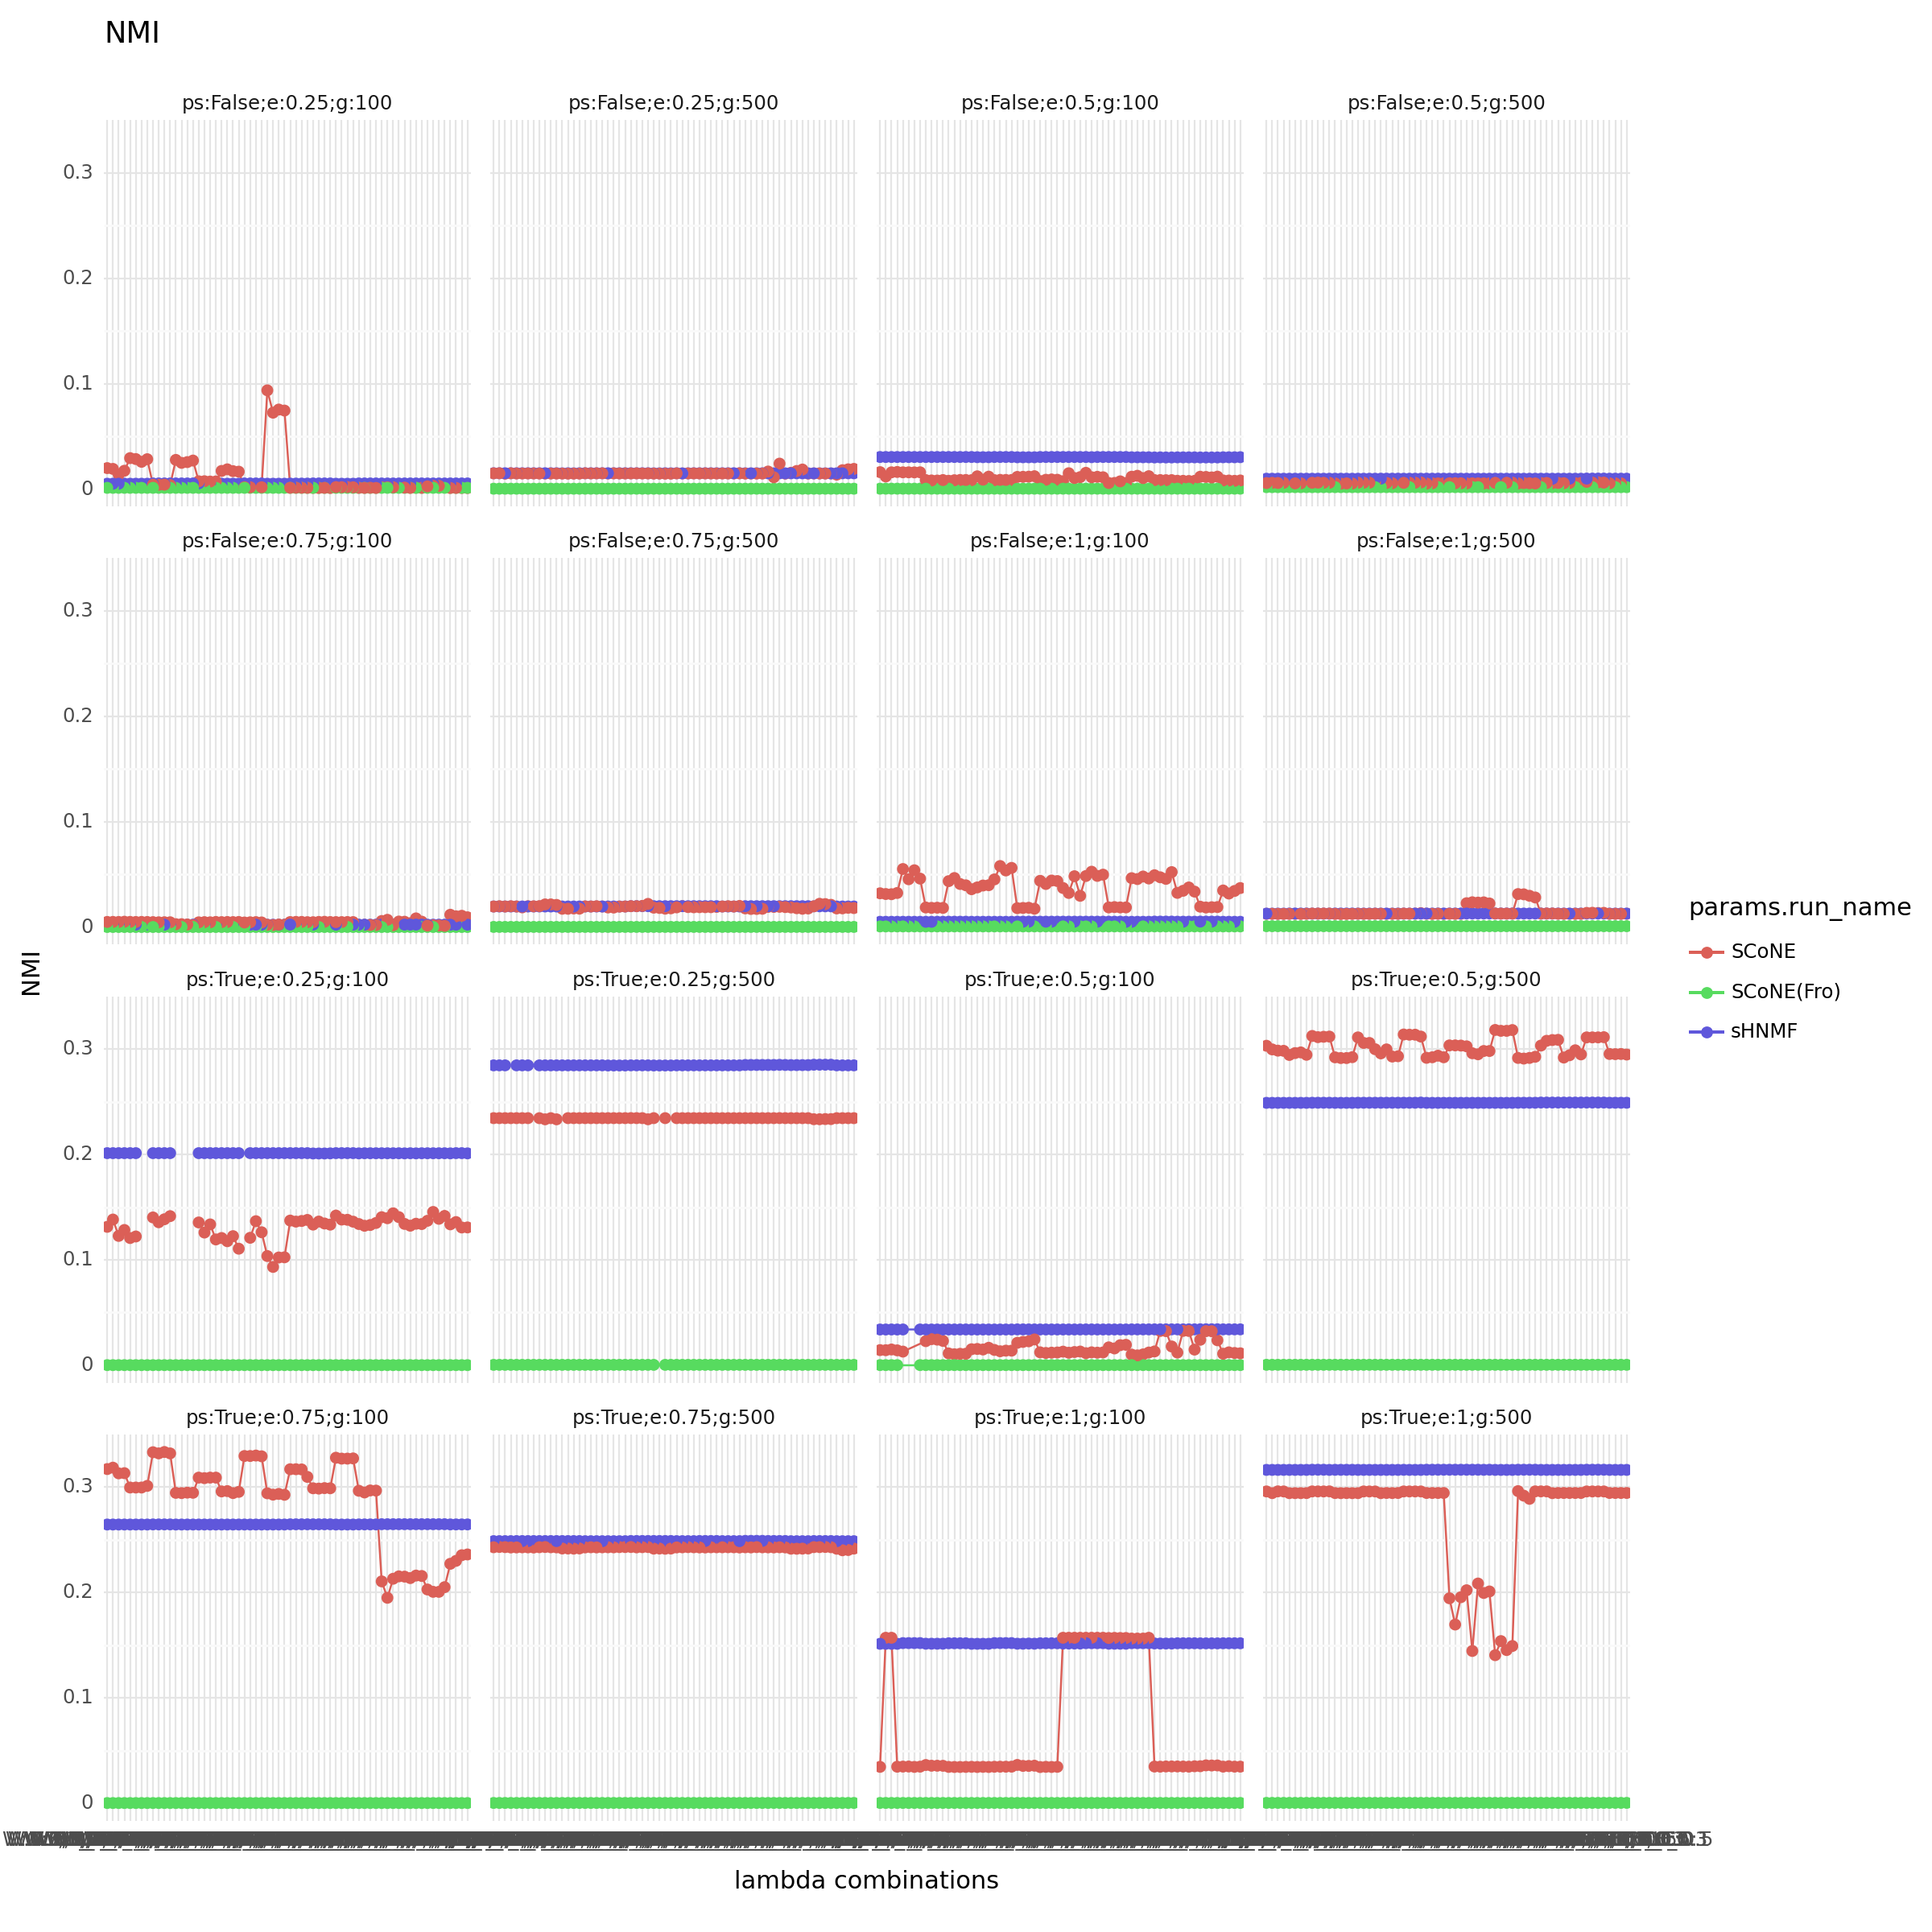

In [33]:
p = (
    ggplot(all_runs, aes(x="lambda_combo", y="metrics.mean_NMI", color="params.run_name", group="params.run_name"))
    + geom_line()
    + geom_point(size=2)
    + facet_wrap('params_combo')
    + labs(x="lambda combinations", y="NMI", title="NMI")
    + theme_minimal()
    + theme(figure_size=(12,12))
)
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 20 rows containing missing values.


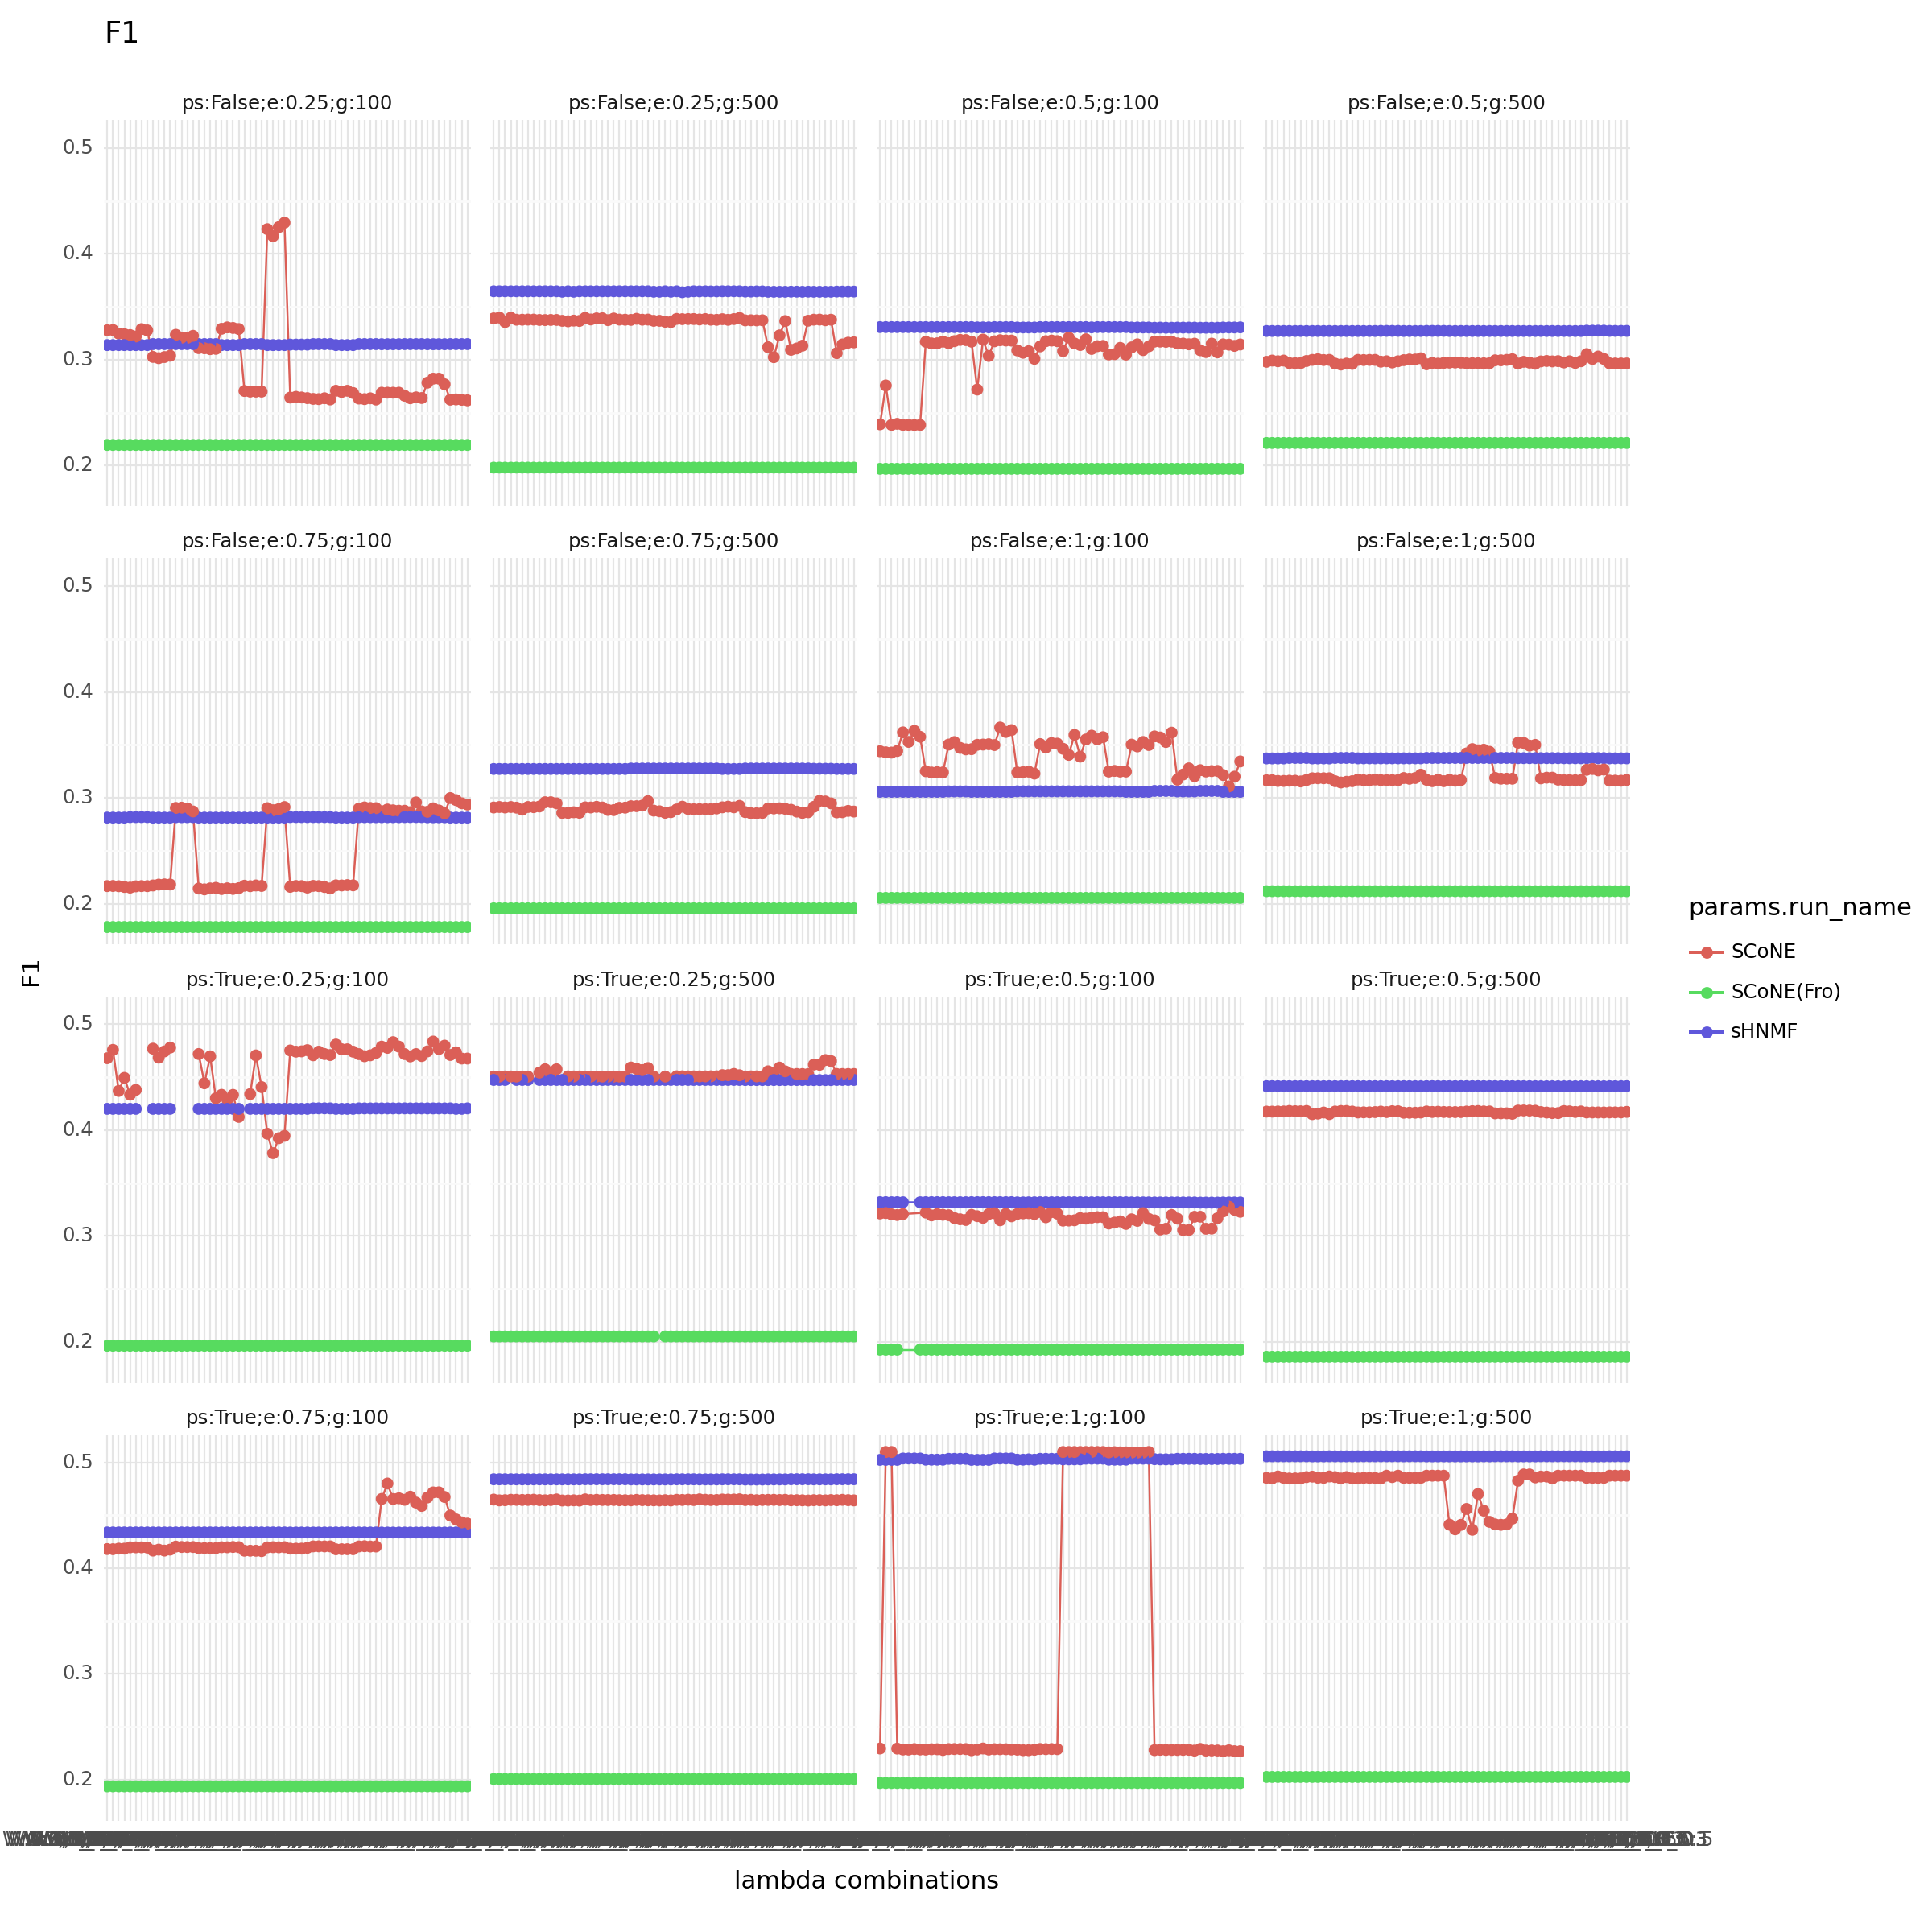

In [35]:
p = (
    ggplot(all_runs, aes(x="lambda_combo", y="metrics.mean_F1", color="params.run_name", group="params.run_name"))
    + geom_line()
    + geom_point(size=2)
    + facet_wrap('params_combo')
    + labs(x="lambda combinations", y="F1", title="F1")
    + theme_minimal()
    + theme(figure_size=(12,12))
)
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 20 rows containing missing values.


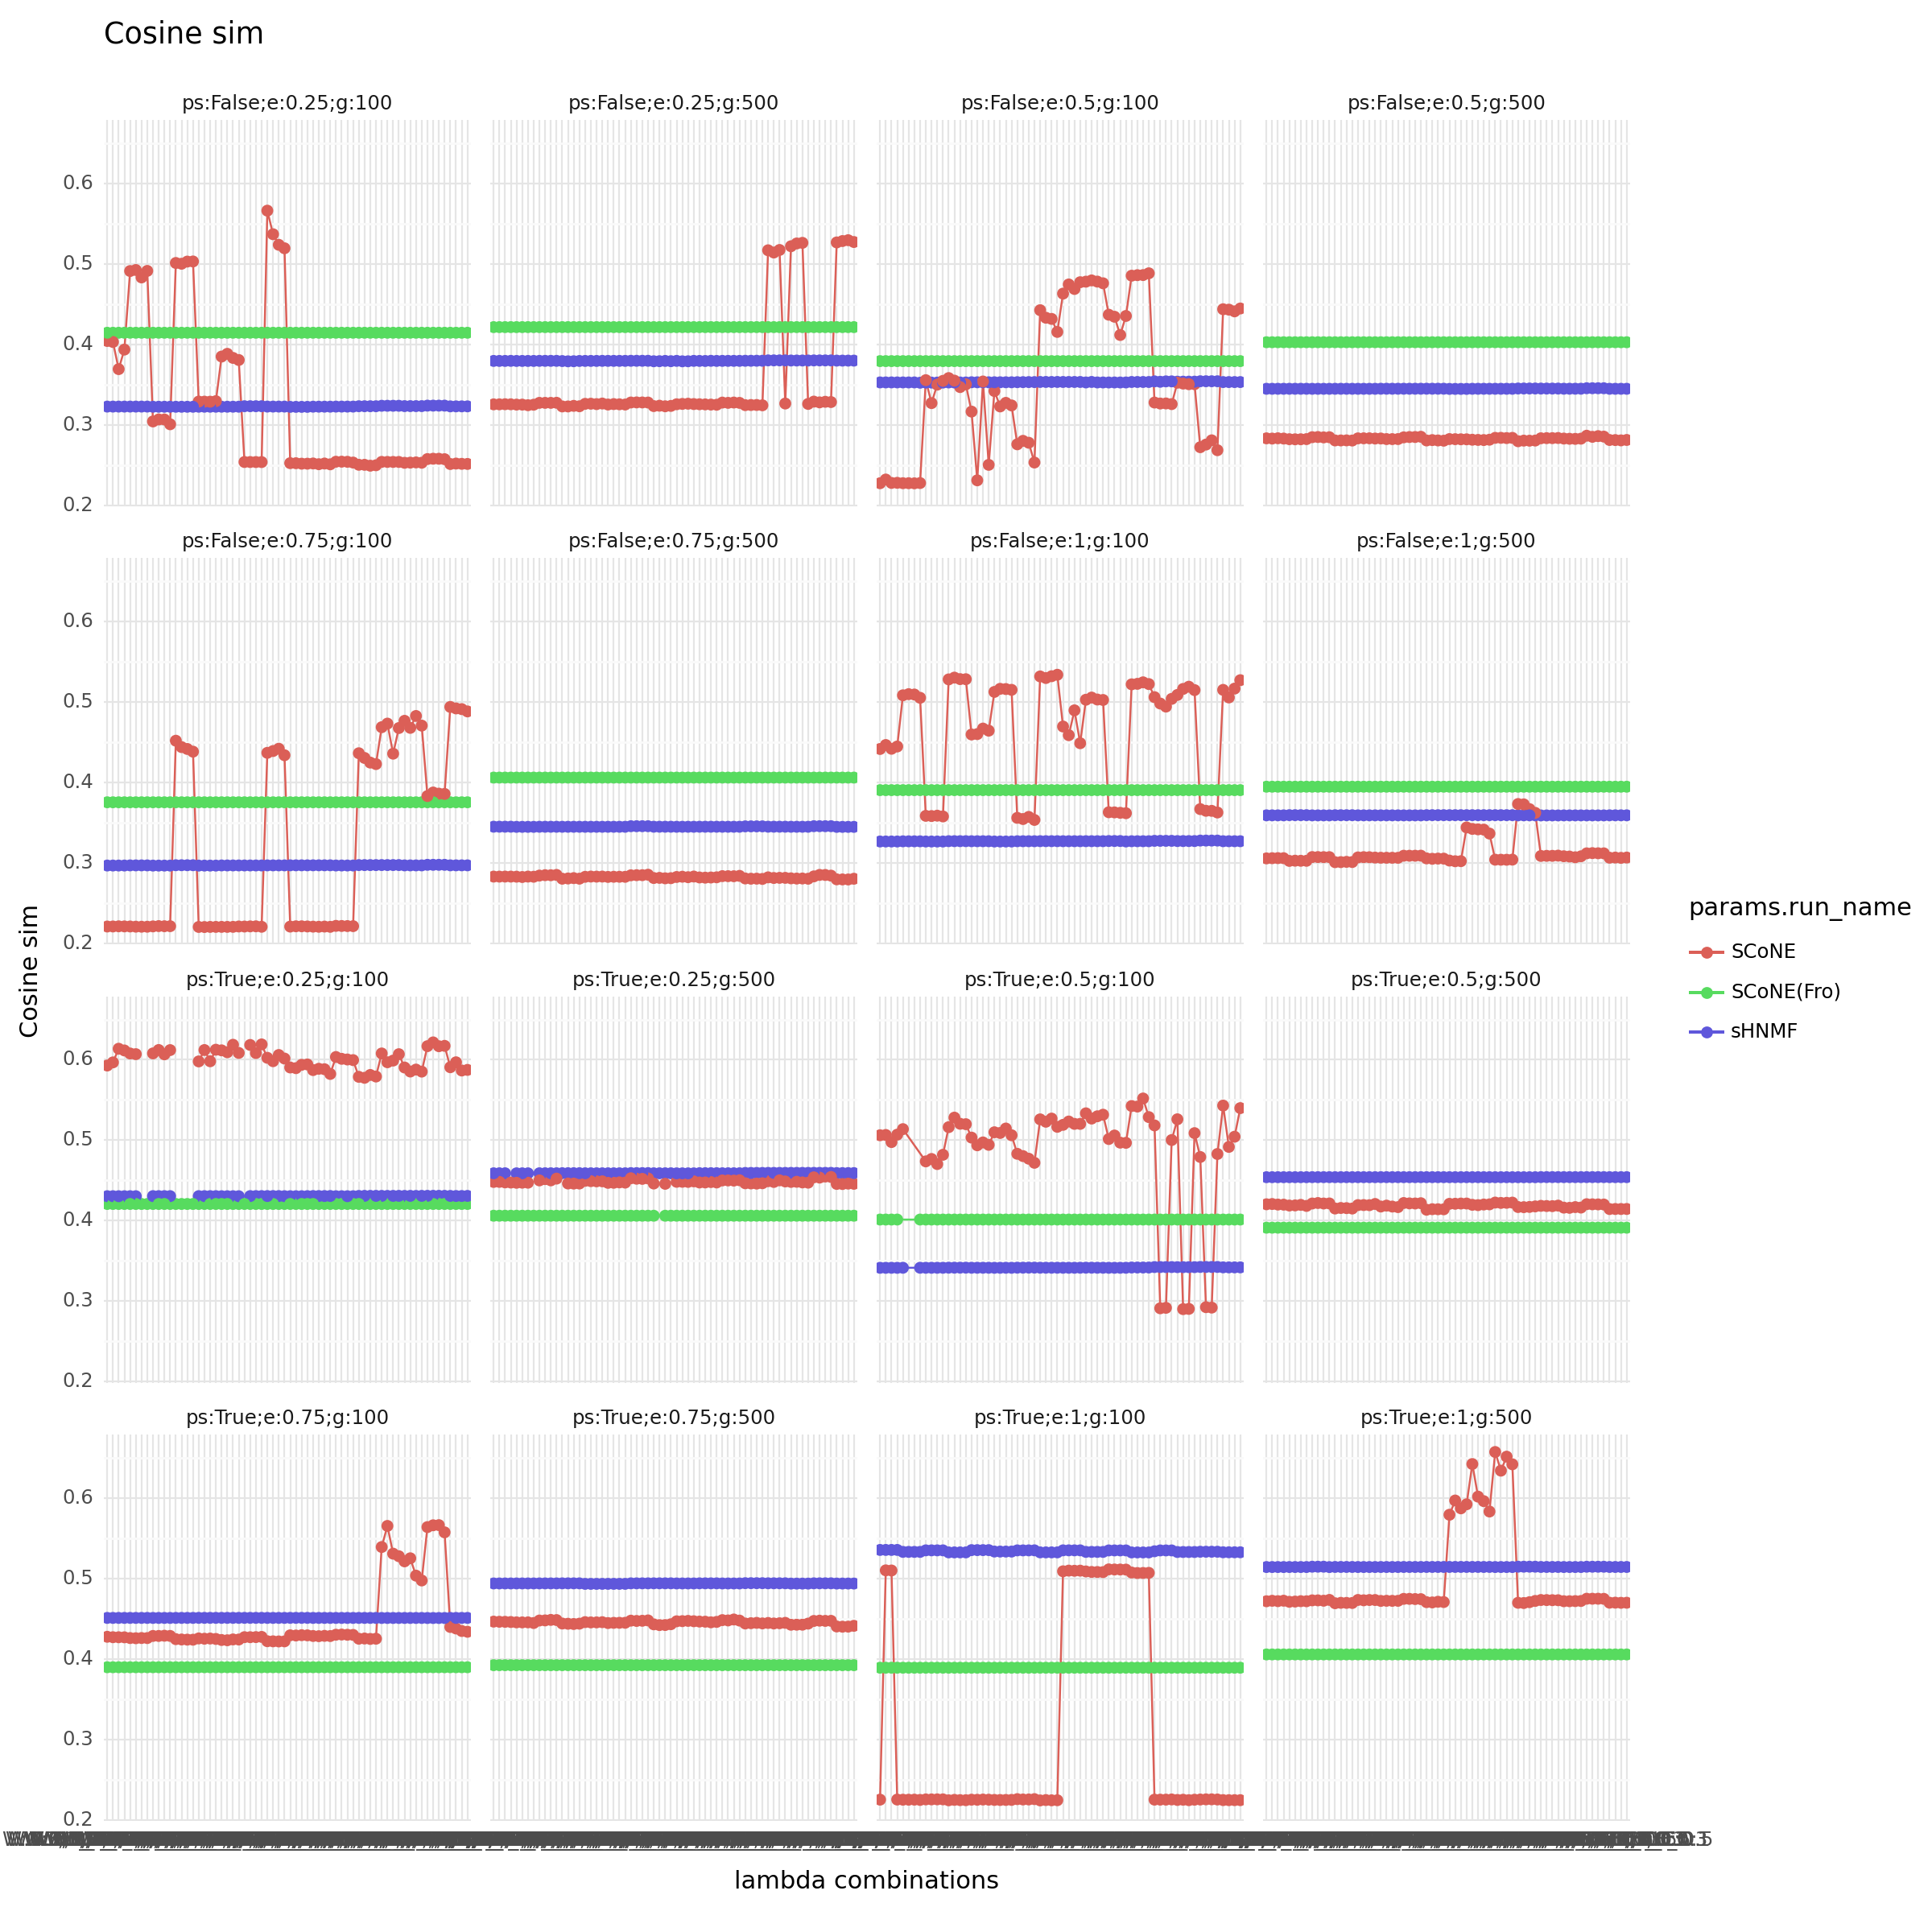

In [37]:
p = (
    ggplot(all_runs, aes(x="lambda_combo", y="metrics.mean_cosine_sim", color="params.run_name", group="params.run_name"))
    + geom_line()
    + geom_point(size=2)
    + facet_wrap('params_combo')
    + labs(x="lambda combinations", y="Cosine sim", title="Cosine sim")
    + theme_minimal()
    + theme(figure_size=(12,12))
)
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 19 rows containing missing values.


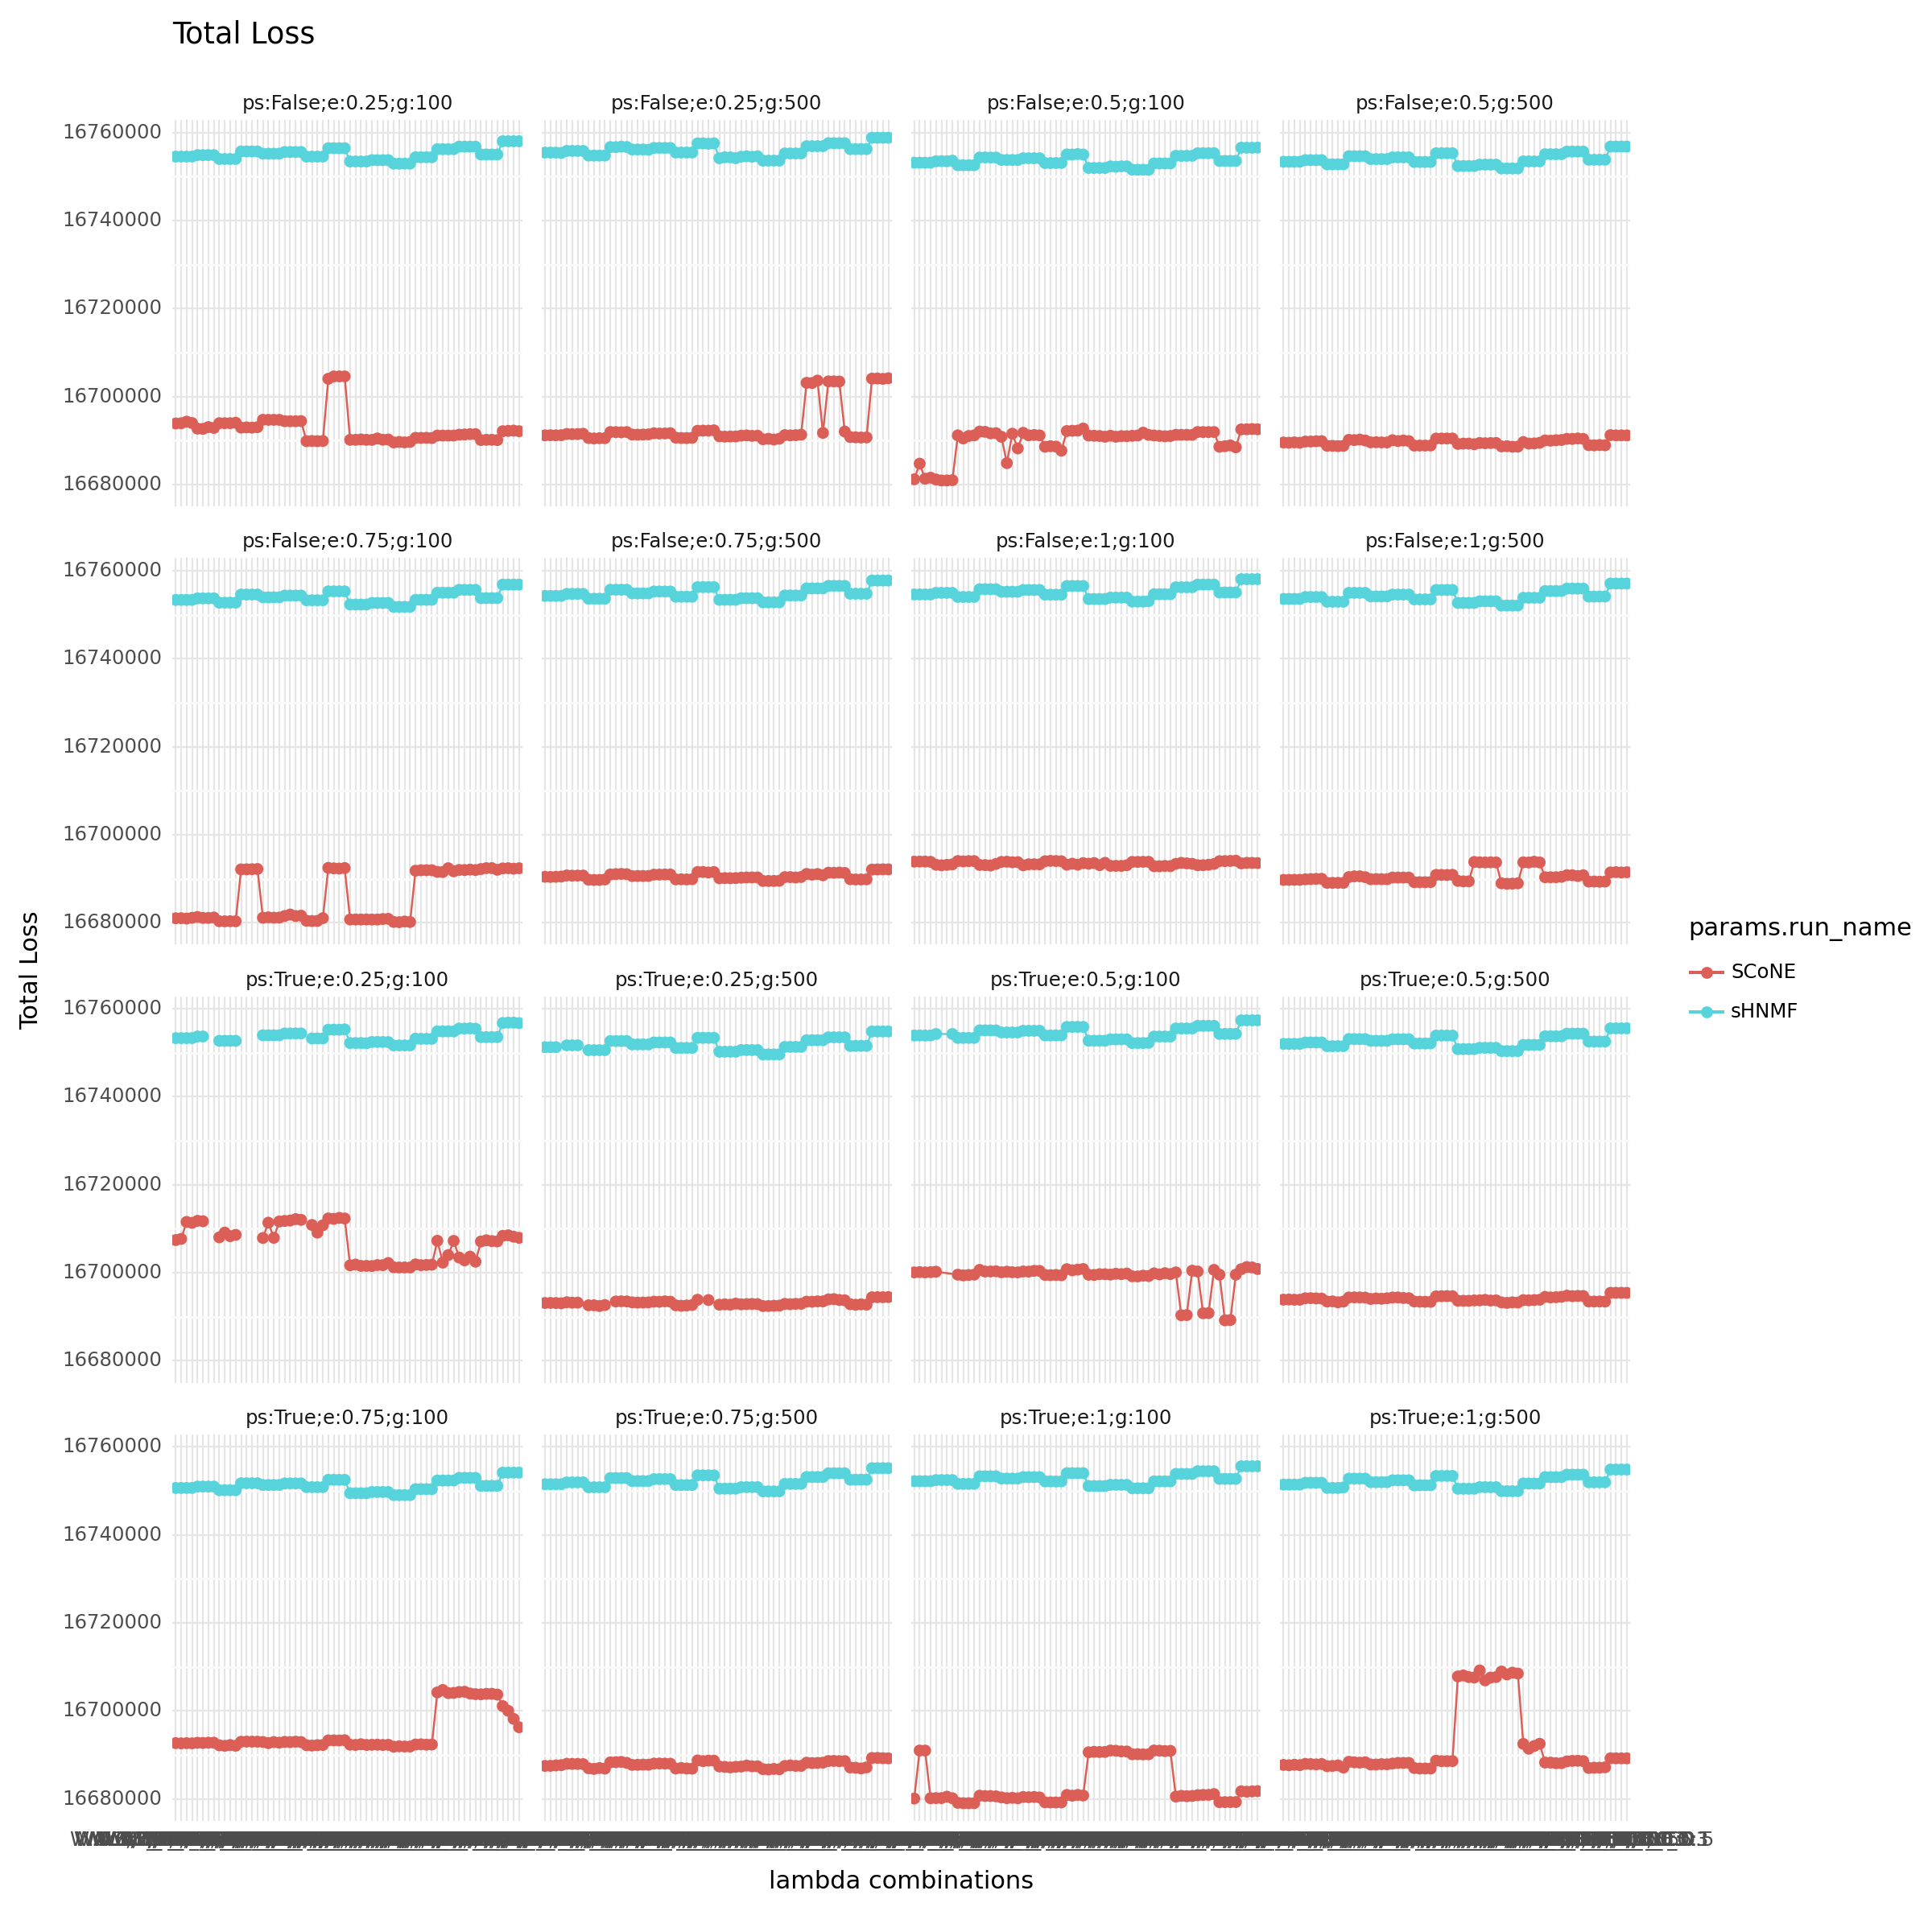

In [31]:
p = (
    ggplot(all_runs[all_runs['params.run_name']!='SCoNE(Fro)'], aes(x="lambda_combo", y="metrics.total_loss", color="params.run_name", group="params.run_name"))
    + geom_line()
    + geom_point(size=2)
    + facet_wrap('params_combo')
    + labs(x="lambda combinations", y="Total Loss", title="Total Loss")
    + theme_minimal()
    + theme(figure_size=(12,12))
)
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 20 rows containing non-finite values.


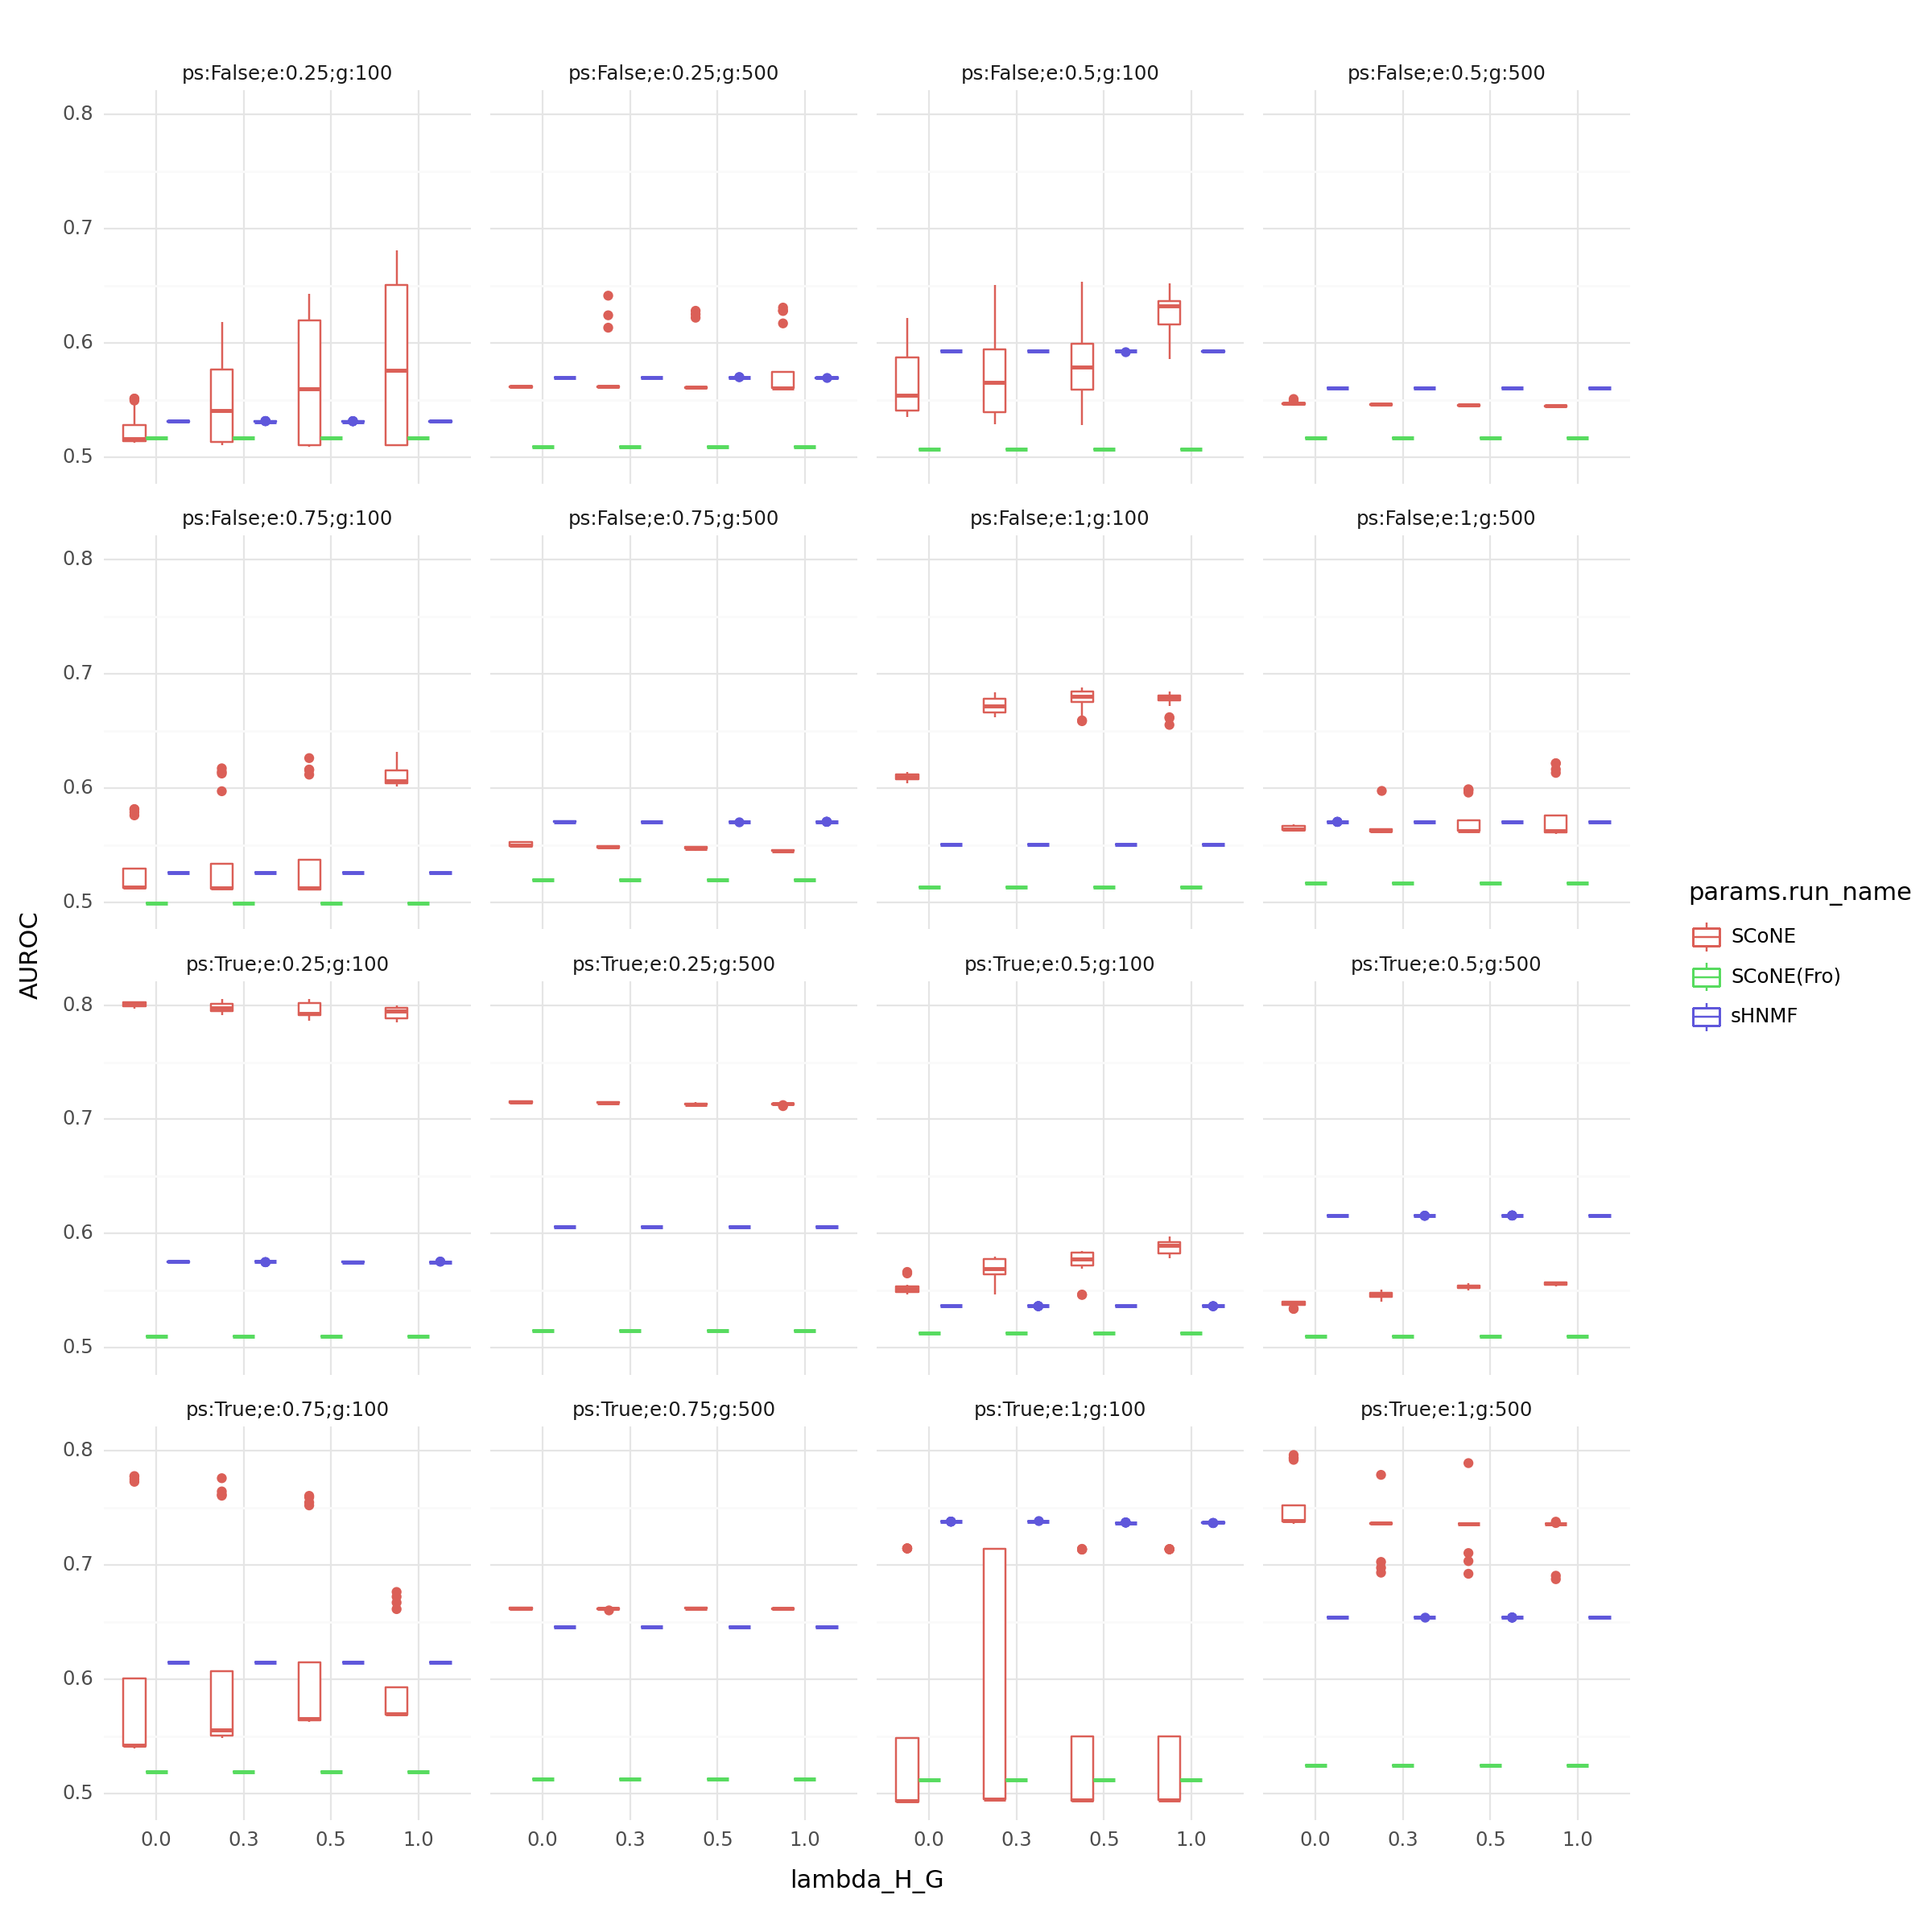

In [75]:
all_runs["lambda_H_G_cat"] = all_runs["params.lambda_H_G"].astype("category")
p = (
    ggplot(all_runs, aes(x="factor(lambda_H_G_cat)", y="metrics.mean_AUROC", color="params.run_name"))
    + geom_boxplot(position=position_dodge(width=0.75))
    + facet_wrap('params_combo')
    + labs(x="lambda_H_G", y="AUROC", title="")
    + theme_minimal()
    + theme(figure_size=(12,12))
)
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 20 rows containing non-finite values.


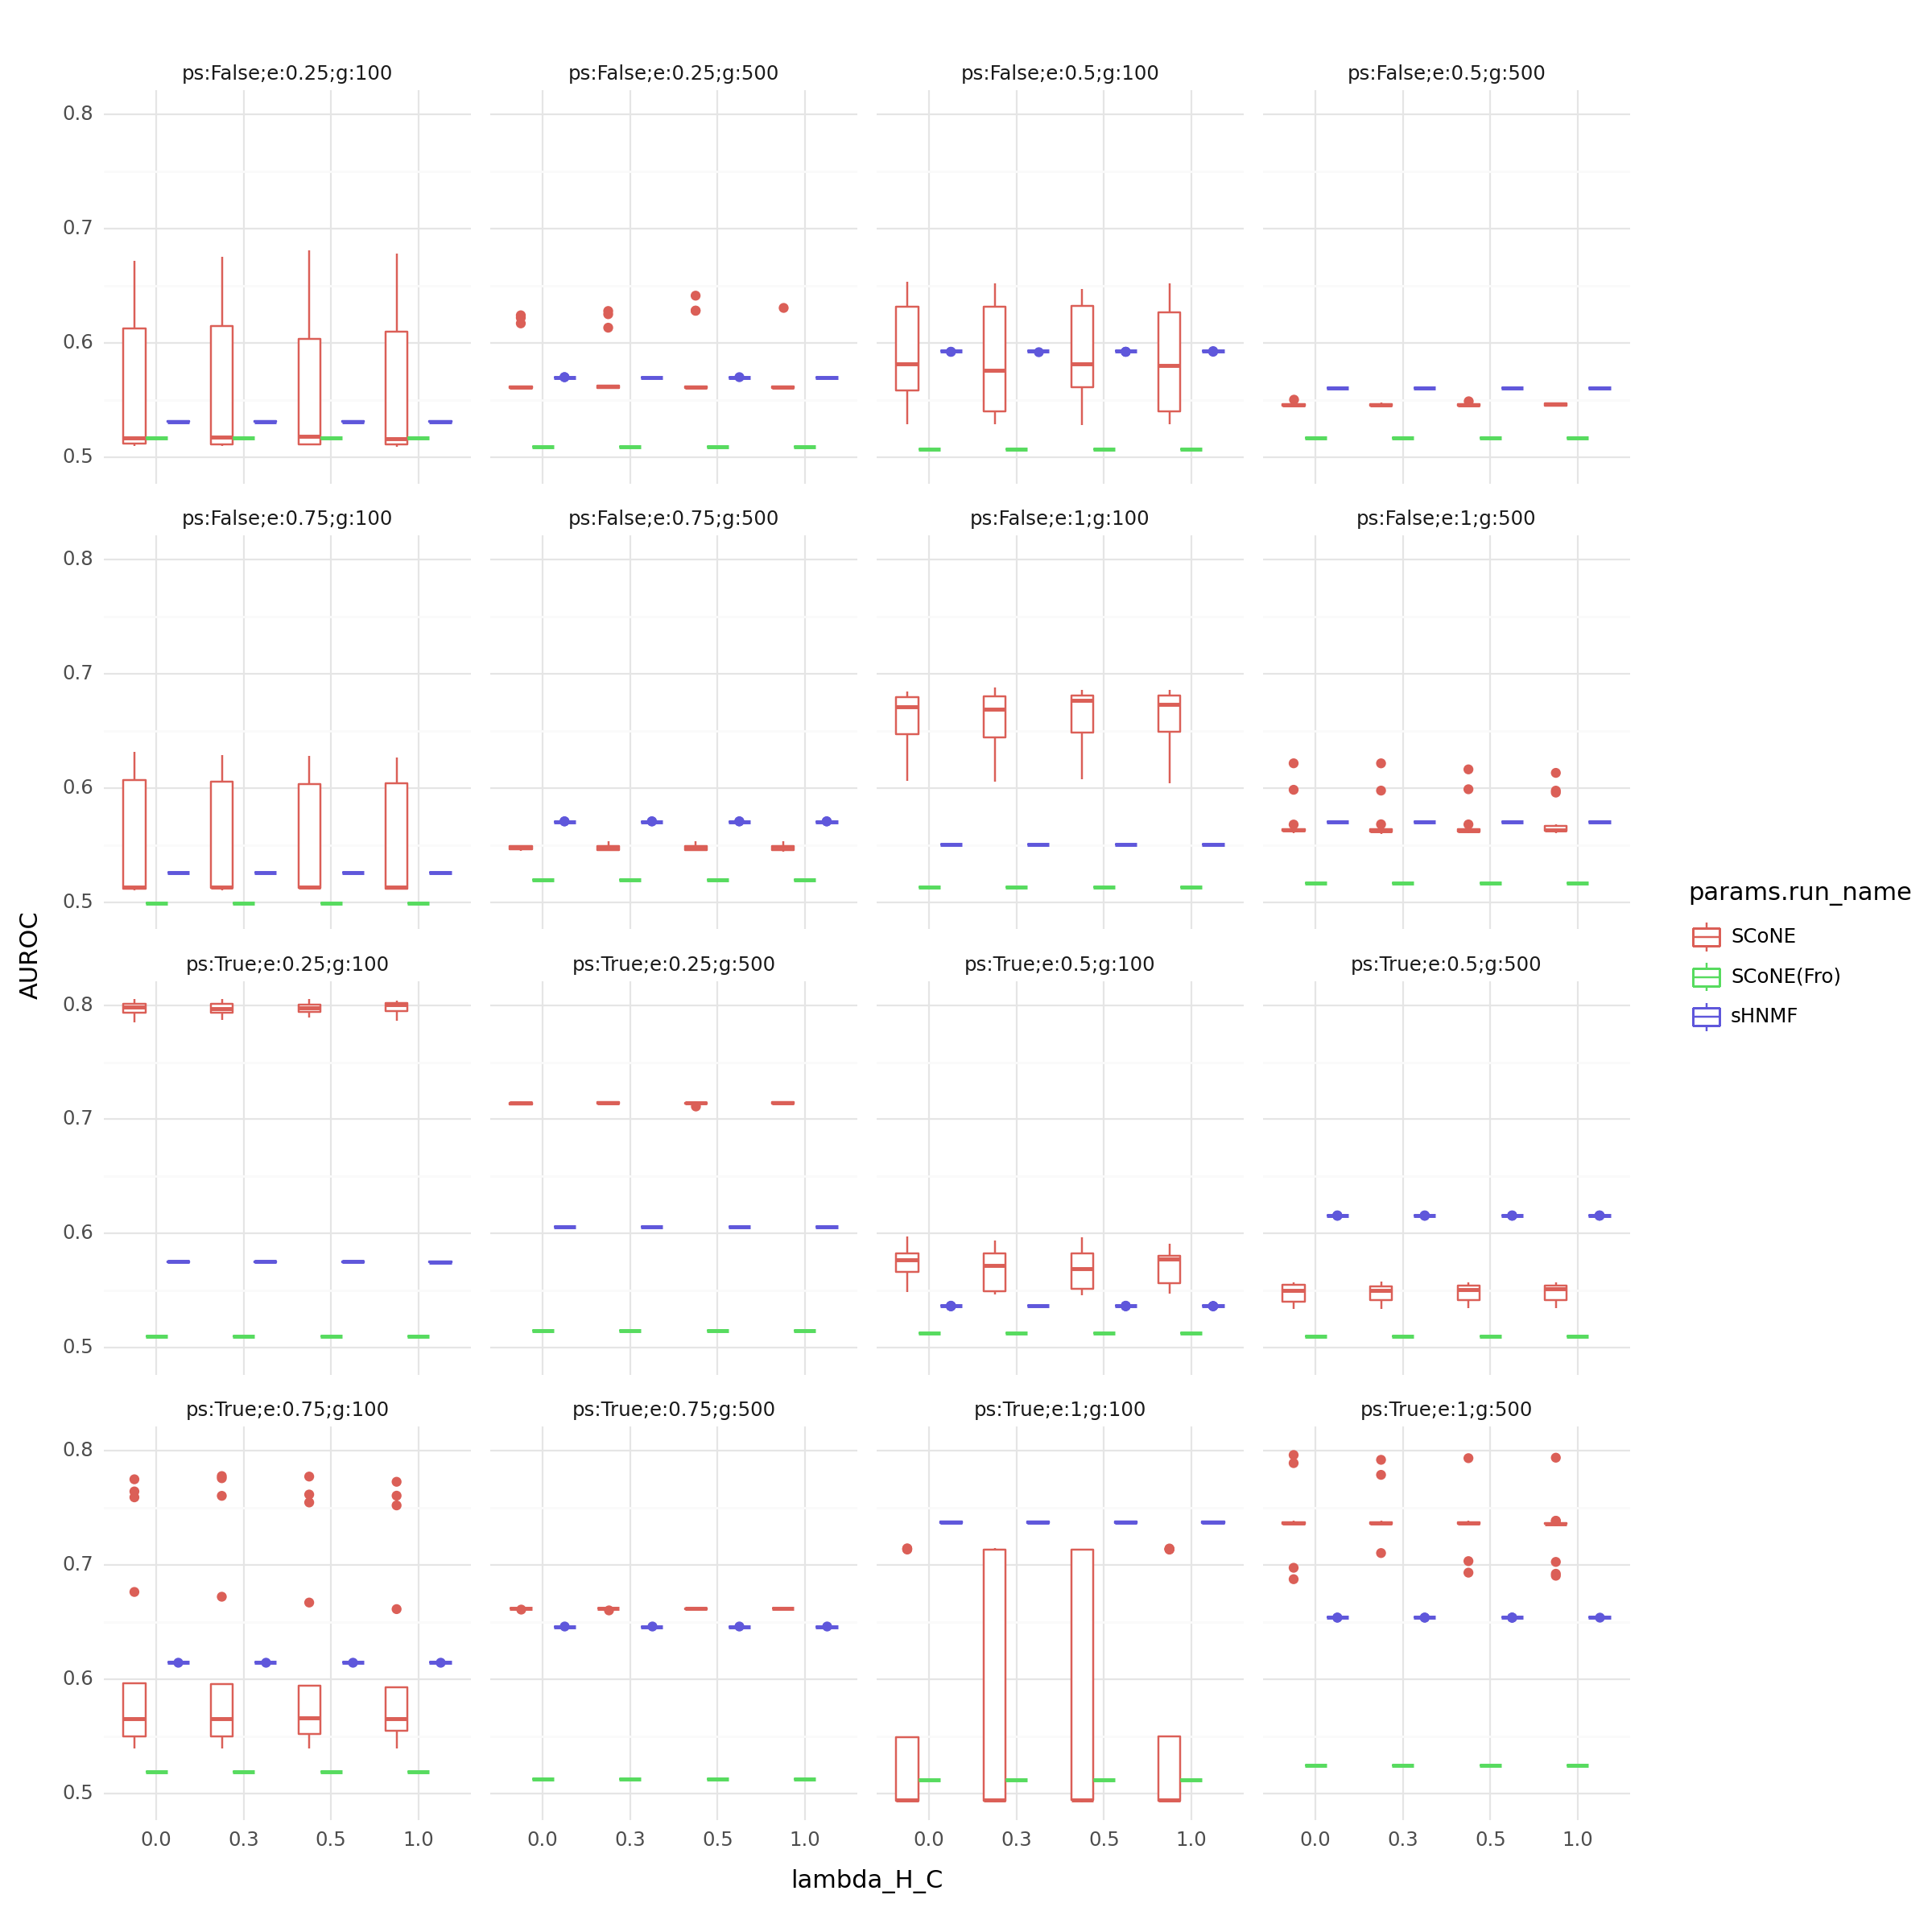

In [76]:
all_runs["lambda_H_C_cat"] = all_runs["params.lambda_H_C"].astype("category")
p = (
    ggplot(all_runs, aes(x="factor(lambda_H_C_cat)", y="metrics.mean_AUROC", color="params.run_name"))
    + geom_boxplot(position=position_dodge(width=0.75))
    + facet_wrap('params_combo')
    + labs(x="lambda_H_C", y="AUROC", title="")
    + theme_minimal()
    + theme(figure_size=(12,12))
)
print(p)

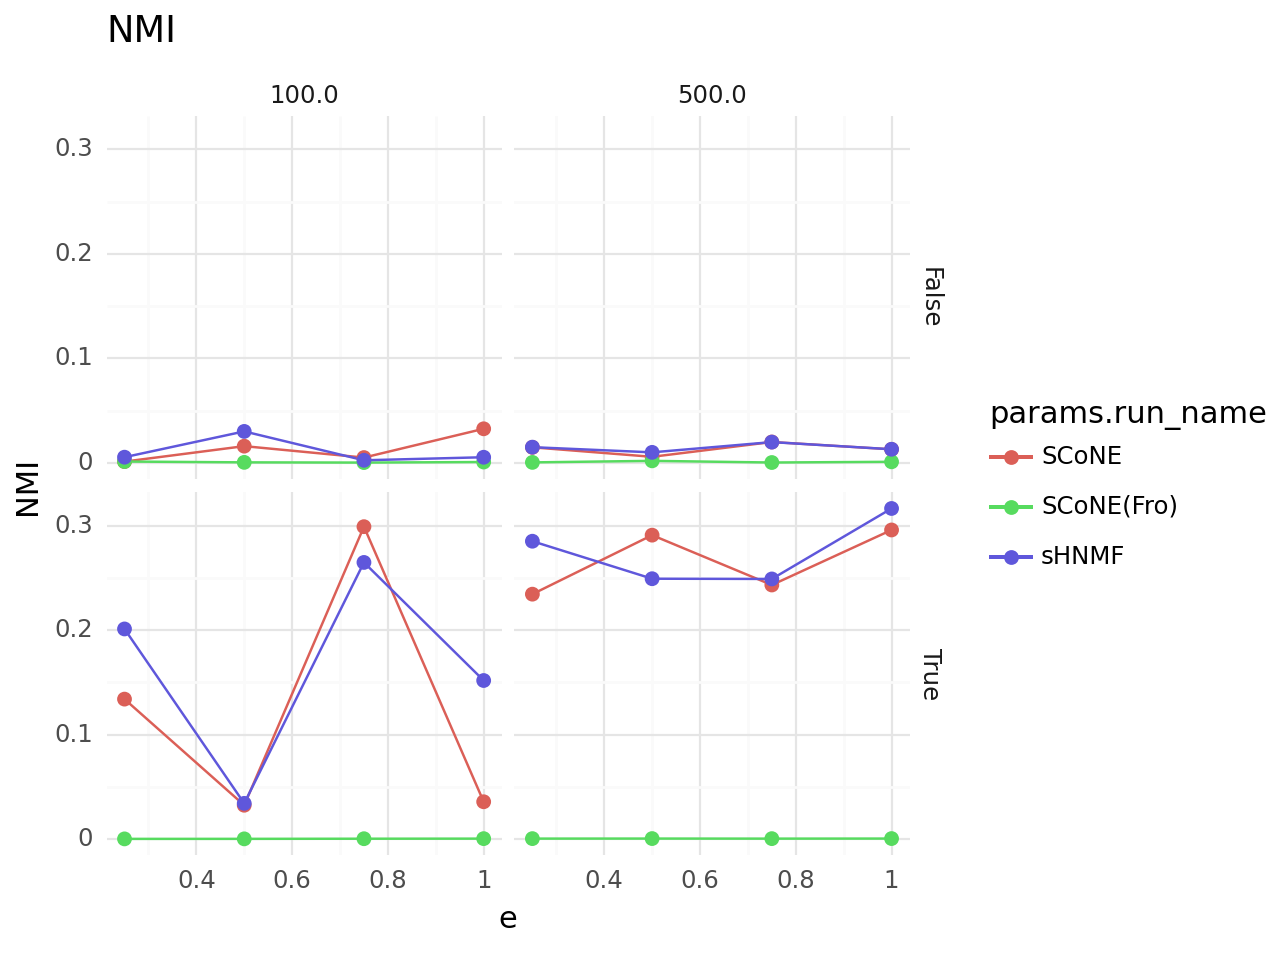

In [90]:
# index of the row with the smallest loss per group
group_cols = ["params.run_name", "params.ps", "params.e", "params.num_markers_assoc"]
all_runs['G_plus_C_loss'] = all_runs['metrics.G_loss'] + all_runs['metrics.C_loss']
idx = all_runs.groupby(["params.run_name", "params.ps", "params.e", "params.num_markers_assoc"])["G_plus_C_loss"].idxmin()
best = (
    all_runs.loc[idx, all_runs.columns]
      .sort_values(group_cols)
      .reset_index(drop=True)
)
p = (
    ggplot(best, aes(x="params.e", y="metrics.mean_NMI", color="params.run_name", group="params.run_name"))
    + geom_line()
    + geom_point(size=2)
    + facet_grid('params.ps ~ params.num_markers_assoc')
    + labs(x="e", y="NMI", title="NMI")
    + theme_minimal()
    + theme()
)
print(p)

In [95]:
best[group_cols+['params.lambda_W','params.lambda_H_G','params.lambda_H_C','G_plus_C_loss']]

,params.run_name,params.ps,params.e,params.num_markers_assoc,params.lambda_W,params.lambda_H_G,params.lambda_H_C,G_plus_C_loss
0,SCoNE,False,0.25,100.0,0.0,0.5,0.0,1.668956e+07
1,SCoNE,False,0.25,500.0,0.0,0.0,0.5,1.669025e+07
2,SCoNE,False,0.50,100.0,0.3,0.5,0.3,1.668001e+07
3,SCoNE,False,0.50,500.0,0.0,1.0,0.3,1.668857e+07
4,SCoNE,False,0.75,100.0,0.3,0.5,0.5,1.668010e+07
5,SCoNE,False,0.75,500.0,0.0,0.0,0.3,1.668950e+07
6,SCoNE,False,1.00,100.0,1.0,0.5,0.0,1.669205e+07
7,SCoNE,False,1.00,500.0,0.0,0.0,0.3,1.668885e+07
8,SCoNE,True,0.25,100.0,1.0,0.5,1.0,1.670110e+07
9,SCoNE,True,0.25,500.0,0.0,1.0,1.0,1.669210e+07


In [53]:
run_name = 'SCoNE'
ps = True
e = 0.75
num_markers_assoc = 100
matching_best_run = best[(best['params.run_name']==run_name)&(best['params.ps']==str(ps))&(best['params.e']==str(e))&(best['params.num_markers_assoc']==str(num_markers_assoc))].copy()
assert matching_best_run.shape[0] == 1
matching_best_run[['params.lambda_W','params.lambda_H_G','params.lambda_H_C']].values[0].tolist()

['0', '0', '0']

SCoNE finds sparsity more helpful to decrease loss

In [44]:
best[group_cols+['lambda_combo']]

,params.run_name,params.ps,params.e,params.num_markers_assoc,lambda_combo
0,SCoNE,False,0.25,100,W:0;H_G:0;H_C:0
1,SCoNE,False,0.25,500,W:0;H_G:0;H_C:0.5
2,SCoNE,False,0.5,100,W:0.3;H_G:0.5;H_C:0.3
3,SCoNE,False,0.5,500,W:0;H_G:0;H_C:0.5
4,SCoNE,False,0.75,100,W:0;H_G:0;H_C:0.3
5,SCoNE,False,0.75,500,W:0;H_G:0;H_C:0
6,SCoNE,False,1,100,W:0;H_G:1;H_C:0.3
7,SCoNE,False,1,500,W:0;H_G:0;H_C:0.3
8,SCoNE,True,0.25,100,W:0;H_G:0;H_C:1
9,SCoNE,True,0.25,500,W:0;H_G:0;H_C:0


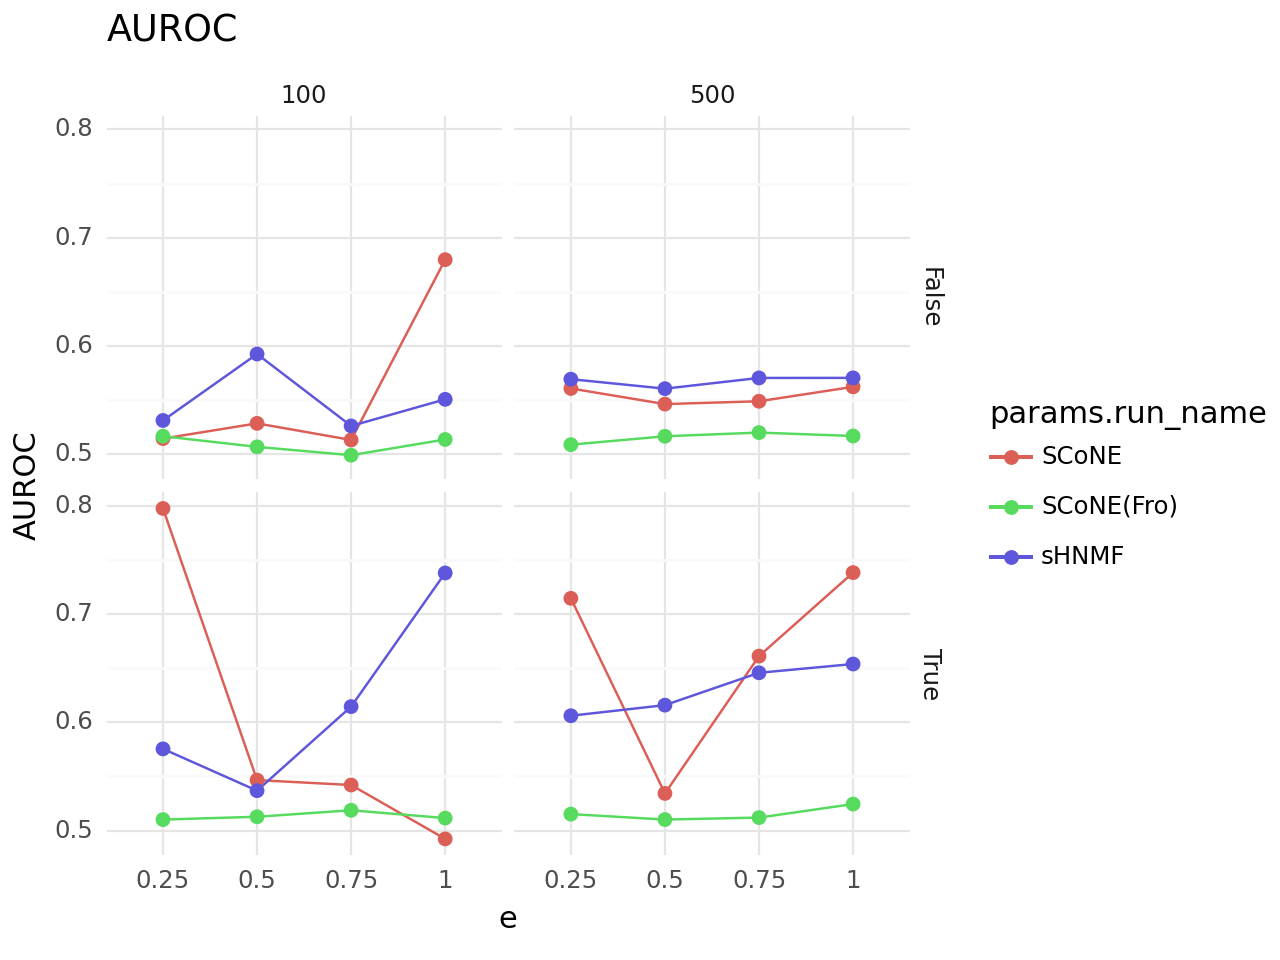

In [41]:
p = (
    ggplot(best, aes(x="params.e", y="metrics.mean_AUROC", color="params.run_name", group="params.run_name"))
    + geom_line()
    + geom_point(size=2)
    + facet_grid('params.ps ~ params.num_markers_assoc')
    + labs(x="e", y="AUROC", title="AUROC")
    + theme_minimal()
    + theme()
)
print(p)

U_G not any larger when pop. strat. is present

try without Z

In [ ]:
W = np.random.random((G.shape[0], rank))*1e-2+1e-6 
H_G = np.random.random((G.shape[1], rank))*1e-2+1e-6
H_C = np.random.random((C.shape[1], rank))*1e-2+1e-6
U_G = np.random.random((G.shape[1], Z.shape[1]))*1e-2+1e-6
U_C = np.random.random((C.shape[1], Z.shape[1]))*1e-2+1e-6
factor_matrices_noz, loss_function_noz = SCoNE.alternating_opt(G,C,np.zeros((Z.shape[0],Z.shape[1])),W, H_G, H_C, U_G, U_C,lambda_W, lambda_H_G, lambda_H_C, 
    method='L-BFGS-B',options={'maxcor':10, 'maxiter':10, 'gtol':1e-5, 'maxls':20, 'ftol':1e-6},tol=1e-4,nonneg=True)


In [160]:
compute_sim_metrics(W_true,factor_matrices_noz["W"])

0.8166904988299722
0.2510132066910599


/scratch/ipykernel_817605/1202321903.py:41: RuntimeWarning: invalid value encountered in divide


,true_subgroup_idx,pred_cluster_idx,similarity_AP,AUROC,AUPRC,Brier,F1,Precision,Recall,NMI
0,0,1,0.260744,0.398464,0.174417,0.50489,0.212698,0.165025,0.299107,0.000579
1,1,0,0.685812,0.841325,0.547307,0.12177,0.678694,0.594880,0.790000,0.297055


In [161]:
compute_sim_metrics(W_true,factor_matrices["W"])

0.34667023574975425
0.1263237732886745


,true_subgroup_idx,pred_cluster_idx,similarity_AP,AUROC,AUPRC,Brier,F1,Precision,Recall,NMI
0,0,1,0.434777,0.645817,0.289213,0.152692,0.362911,0.327928,0.40625,0.038680
1,1,0,0.680533,0.834608,0.560436,0.107429,0.678171,0.596358,0.78600,0.296035


In [165]:
simulation_metadata["clinical_assoc"]

,phenotypic_subgroup,strength,indices
0,0,0.6,"[35, 8, 62]"
1,0,0.5,"[78, 49, 92]"
2,0,0.4,"[83, 68, 27, 99]"
3,1,0.6,"[12, 53, 63]"
4,1,0.5,"[50, 99, 58]"
5,1,0.4,"[89, 29, 79, 3]"
6,2,0.6,"[13, 32, 60]"
7,2,0.5,"[66, 80, 89]"
8,2,0.4,"[85, 18, 69, 19]"
9,3,0.6,"[1, 51, 88]"


In [179]:
bfile_path = f'{output_dir}/G'
bim_df = pd.read_csv(f'{bfile_path}.bim',sep='\s+',header=None,names=['CHR','SNP','CM','POS','A1','A2']).reset_index(drop=True)
bim_df

,CHR,SNP,CM,POS,A1,A2
0,1,1:1151300,0,1151300,T,C
1,1,1:1371459,0,1371459,A,G
2,1,1:1510801,0,1510801,C,T
3,1,1:1648027,0,1648027,T,C
4,1,1:2914288,0,2914288,C,G
...,...,...,...,...,...,...
9995,22,22:50815104,0,50815104,T,C
9996,22,22:50937900,0,50937900,G,A
9997,22,22:51034177,0,51034177,G,A
9998,22,22:51156078,0,51156078,G,A


In [195]:
set(simulation_metadata["markers_assoc"][0]).intersection(set(simulation_metadata["markers_assoc"][1]))

{'2:110397539', '8:25777436'}

100
0


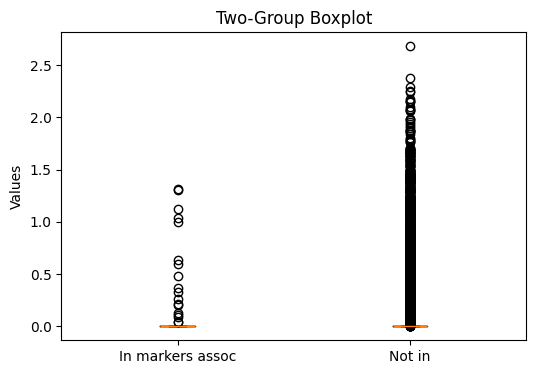

100
5


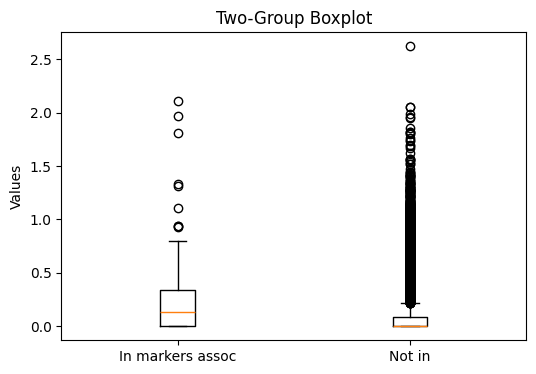

In [193]:
for i_true, j_pred in zip(row_ind, col_ind):
    top_idx = np.argsort(factor_matrices["H_G"][:,j_pred])[-num_markers_assoc:][::-1]
    top_markers = bim_df.loc[top_idx, "SNP"].values
    markers_assoc = simulation_metadata["markers_assoc"][i_true]
    print(len(markers_assoc))
    print(len(set(top_markers).intersection(set(markers_assoc))))

    idx_in = bim_df.index[bim_df["SNP"].isin(markers_assoc)].tolist()
    idx_not_in = bim_df.index[~bim_df["SNP"].isin(markers_assoc)].tolist()


    plt.figure(figsize=(6,4))
    plt.boxplot([factor_matrices["H_G"][:,j_pred][idx_in], factor_matrices["H_G"][:,j_pred][idx_not_in]], labels=["In markers assoc", "Not in"])

    plt.ylabel("Values")
    plt.title("Two-Group Boxplot")
    plt.show()


100
3


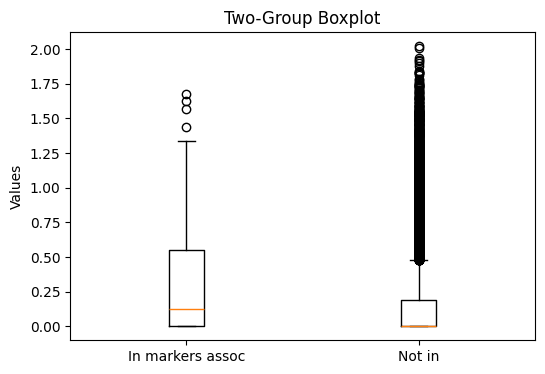

100
5


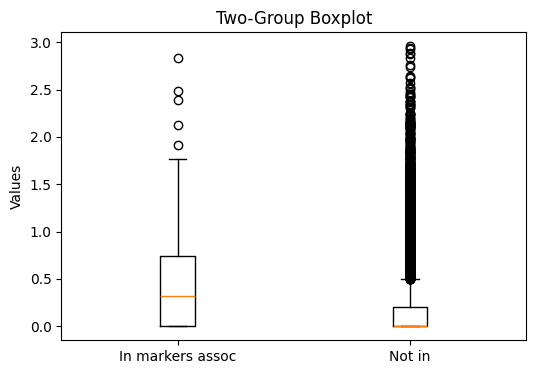

In [194]:
for i_true, j_pred in zip(row_ind, col_ind):
    top_idx = np.argsort(factor_matrices_noz["H_G"][:,j_pred])[-num_markers_assoc:][::-1]
    top_markers = bim_df.loc[top_idx, "SNP"].values
    markers_assoc = simulation_metadata["markers_assoc"][i_true]
    print(len(markers_assoc))
    print(len(set(top_markers).intersection(set(markers_assoc))))

    idx_in = bim_df.index[bim_df["SNP"].isin(markers_assoc)].tolist()
    idx_not_in = bim_df.index[~bim_df["SNP"].isin(markers_assoc)].tolist()


    plt.figure(figsize=(6,4))
    plt.boxplot([factor_matrices_noz["H_G"][:,j_pred][idx_in], factor_matrices_noz["H_G"][:,j_pred][idx_not_in]], labels=["In markers assoc", "Not in"])

    plt.ylabel("Values")
    plt.title("Two-Group Boxplot")
    plt.show()


In [28]:
import pandas as pd
from plotnine import *

df = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/eval_results.csv')
df.columns

Index(['Unnamed: 0', 'num_epochs', 'method', 'cosine_sim_0', 'AUROC_0',
       'AUPRC_0', 'Brier_0', 'F1_0', 'Precision_0', 'Recall_0', 'NMI_0',
       'cosine_sim_1', 'AUROC_1', 'AUPRC_1', 'Brier_1', 'F1_1', 'Precision_1',
       'Recall_1', 'NMI_1', 'mean_cosine_sim', 'mean_AUROC', 'mean_AUPRC',
       'mean_Brier', 'mean_F1', 'mean_Precision', 'mean_Recall', 'mean_NMI',
       'ps', 'e', 'init', 'num_markers_assoc', 'run_seed', 'tol', 'max_outer',
       'lambda_W', 'lambda_H_G', 'lambda_H_C', 'max mem', 'cpu time',
       'user time', 'W', 'H_G', 'H_C', 'U_G', 'U_C'],
      dtype='object')

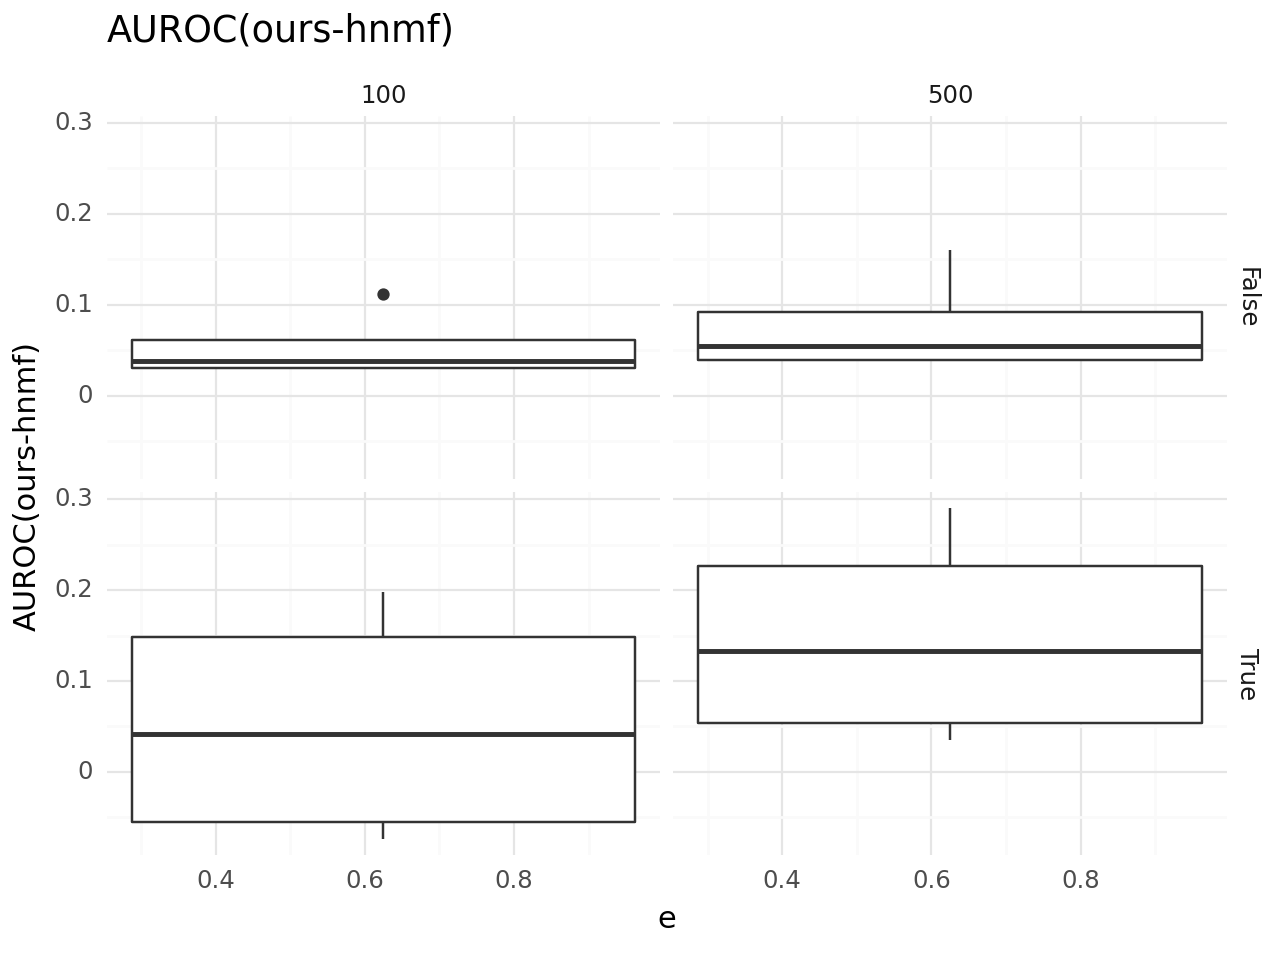

In [34]:
wide = (df.groupby(['ps','e','init','num_markers_assoc','method'])['mean_AUROC']
          .first()                         
          .unstack('method'))
wide = wide.reindex(columns=['ours','hnmf'])
out = (wide.iloc[:, 0] - wide.iloc[:, 1]).rename('AUROC(ours-hnmf)').reset_index()
p = (
    ggplot(out, aes(x="e", y="AUROC(ours-hnmf)"))
    + geom_boxplot()
    + facet_grid('ps ~ num_markers_assoc')
    + labs(x="e", y="AUROC(ours-hnmf)", title="AUROC(ours-hnmf)")
    + theme_minimal()
)
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 32 rows containing missing values.


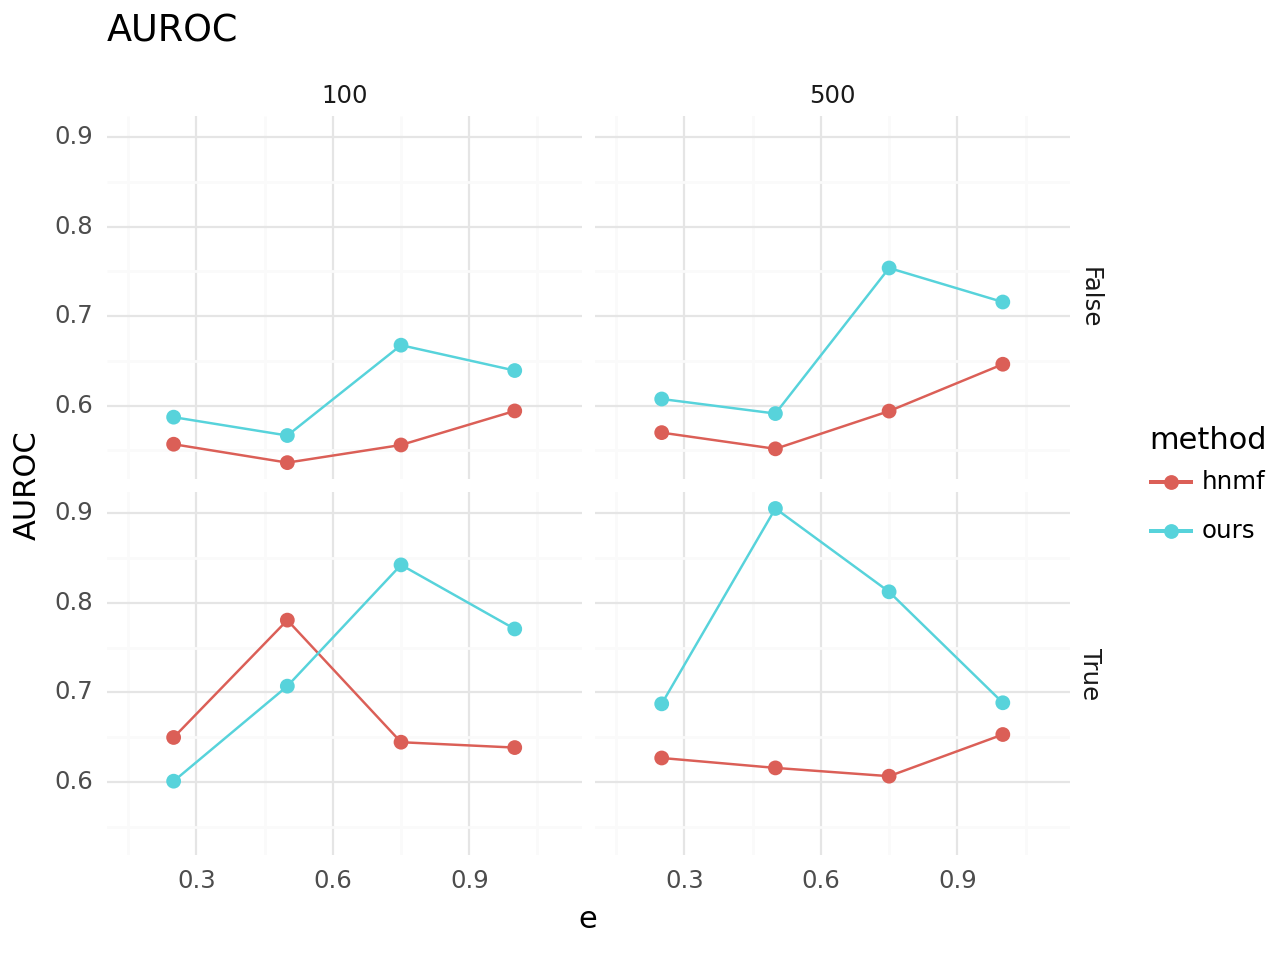

In [35]:
import scipy.stats as st
import numpy as np
def ci95(x):
    n = len(x)                     # number of runs
    mean = np.mean(x)              # average RMSE
    sd = np.std(x, ddof=1)         # sample standard deviation
    se = sd / np.sqrt(n)           # standard error of the mean
    margin = 1.96 * se          # margin of error
    return pd.Series({
        "mean": mean,
        "low": mean - margin,
        "high": mean + margin
    })
summary = df.groupby(["method","e","ps","num_markers_assoc"])["mean_AUROC"].apply(ci95).reset_index()
summary = summary.pivot(index=["method","e","ps","num_markers_assoc"],columns='level_4',values='mean_AUROC').reset_index().copy()
p = (
    ggplot(summary, aes(x="e", y="mean", color="method", group="method"))
    + geom_line()
    + geom_point(size=2)
    + geom_errorbar(aes(ymin="low", ymax="high"), width=0.2)
    + facet_grid('ps ~ num_markers_assoc')
    + labs(x="e", y="AUROC", title="AUROC")
    + theme_minimal()
)
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 32 rows containing missing values.


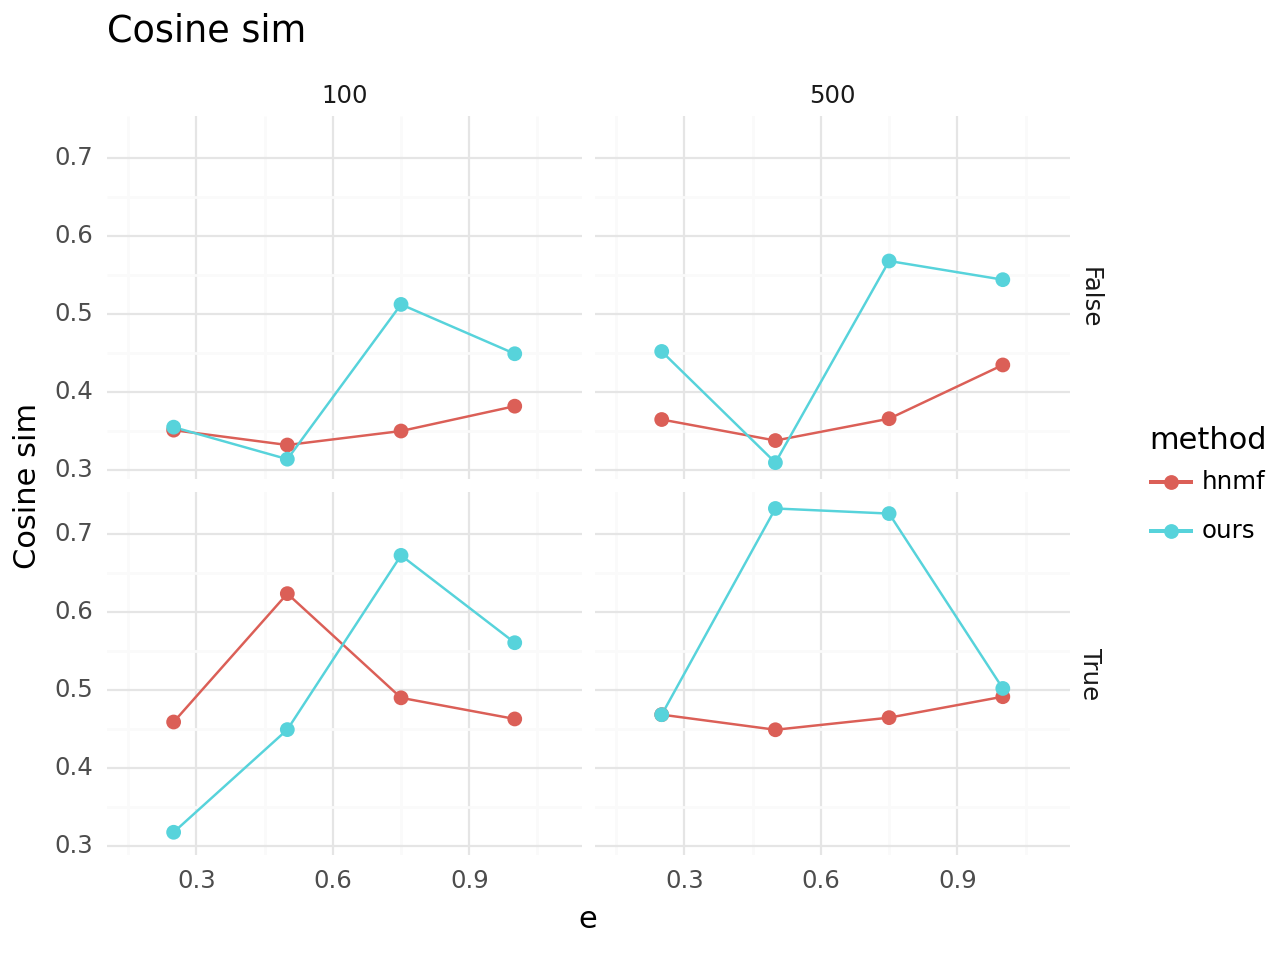

In [40]:
summary = df.groupby(["method","e","ps","num_markers_assoc"])["mean_cosine_sim"].apply(ci95).reset_index()
summary = summary.pivot(index=["method","e","ps","num_markers_assoc"],columns='level_4',values='mean_cosine_sim').reset_index().copy()
p = (
    ggplot(summary, aes(x="e", y="mean", color="method", group="method"))
    + geom_line()
    + geom_point(size=2)
    + geom_errorbar(aes(ymin="low", ymax="high"), width=0.2)
    + facet_grid('ps ~ num_markers_assoc')
    + labs(x="e", y="Cosine sim", title="Cosine sim")
    + theme_minimal()
)
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 32 rows containing missing values.


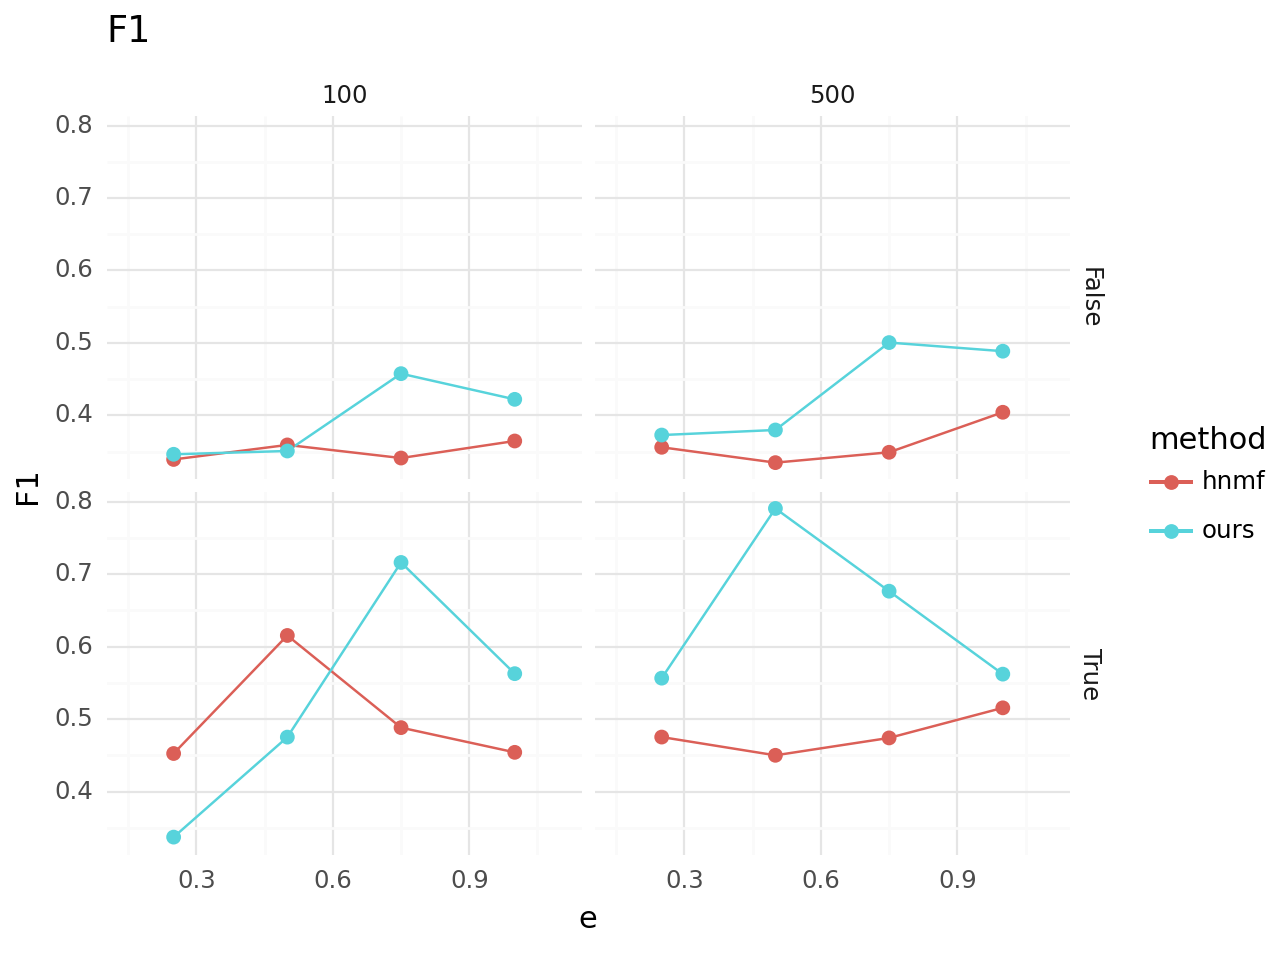

In [41]:
summary = df.groupby(["method","e","ps","num_markers_assoc"])["mean_F1"].apply(ci95).reset_index()
summary = summary.pivot(index=["method","e","ps","num_markers_assoc"],columns='level_4',values='mean_F1').reset_index().copy()
p = (
    ggplot(summary, aes(x="e", y="mean", color="method", group="method"))
    + geom_line()
    + geom_point(size=2)
    + geom_errorbar(aes(ymin="low", ymax="high"), width=0.2)
    + facet_grid('ps ~ num_markers_assoc')
    + labs(x="e", y="F1", title="F1")
    + theme_minimal()
)
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 32 rows containing missing values.


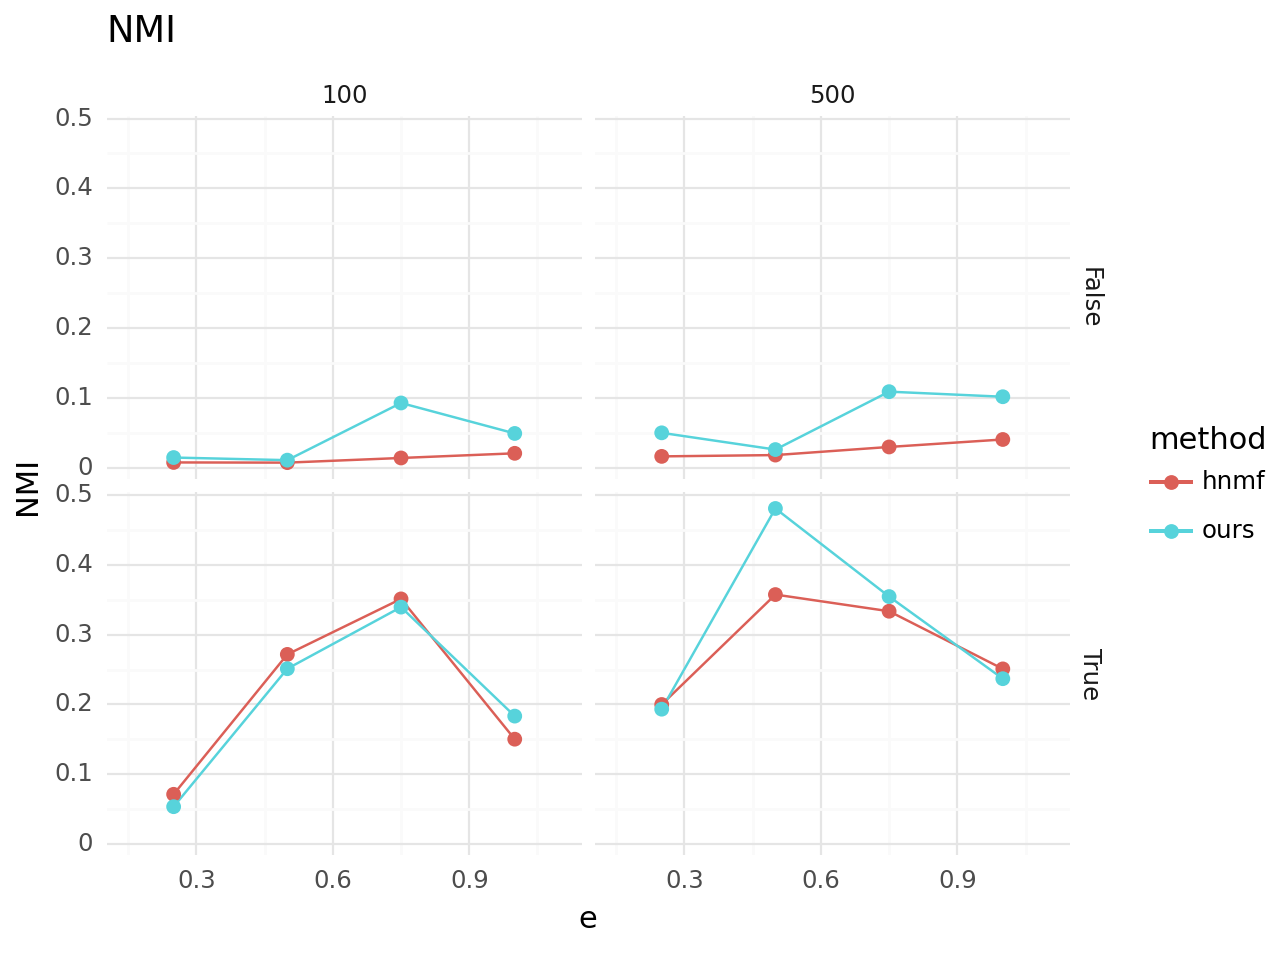

In [42]:
summary = df.groupby(["method","e","ps","num_markers_assoc"])["mean_NMI"].apply(ci95).reset_index()
summary = summary.pivot(index=["method","e","ps","num_markers_assoc"],columns='level_4',values='mean_NMI').reset_index().copy()
p = (
    ggplot(summary, aes(x="e", y="mean", color="method", group="method"))
    + geom_line()
    + geom_point(size=2)
    + geom_errorbar(aes(ymin="low", ymax="high"), width=0.2)
    + facet_grid('ps ~ num_markers_assoc')
    + labs(x="e", y="NMI", title="NMI")
    + theme_minimal()
)
print(p)

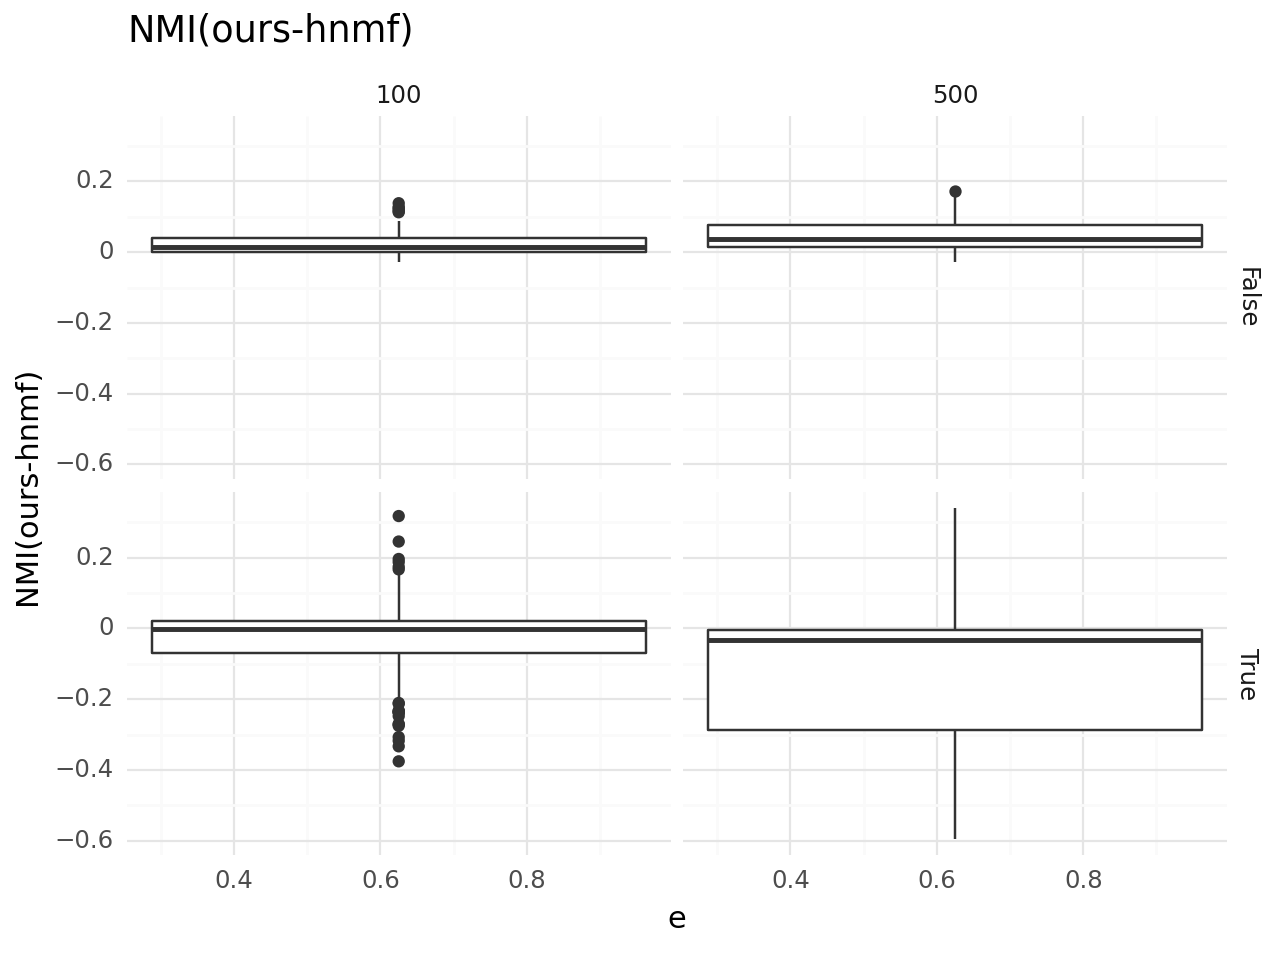

In [23]:
wide = (df.groupby(['true_subgroup_idx','ps','e','init','num_markers_assoc','algo_name'])['NMI']
          .first()                         
          .unstack('algo_name'))
wide = wide.reindex(columns=['ours','hnmf'])
out = (wide.iloc[:, 0] - wide.iloc[:, 1]).rename('NMI(ours-hnmf)').reset_index()
p = (
    ggplot(out, aes(x="e", y="NMI(ours-hnmf)"))
    + geom_boxplot()
    + facet_grid('ps ~ num_markers_assoc')
    + labs(x="e", y="NMI(ours-hnmf)", title="NMI(ours-hnmf)")
    + theme_minimal()
)
print(p)

Write some test code for simulated data code

In [48]:
import os
import glob
import hashlib
import pickle
import numpy as np
import pandas as pd
import re

# DEFINE PATHS
intermediate_plink_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
intermediate_saige_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_saige'
root_dir = '/gpfs/commons/datasets/1000genomes'
sim_output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'
graph_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
maf_by_superpop_filepath = f'{intermediate_plink_dir}/maf_by_superpop'
admixture_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5'
map_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.map'
code_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/code'
# DEFINE PATHS

# read in 
G = np.loadtxt(f'{sim_output_dir}/G.raw',  usecols=range(6, 10000+6), dtype=np.int8, skiprows=1)
G = (G>0).astype(np.int8)
# assert that bim_df and G order is the same
bfile_path = f'{sim_output_dir}/G'
bim_df = pd.read_csv(f'{bfile_path}.bim',sep='\s+',header=None,names=['CHR','SNP','CM','POS','A1','A2']).reset_index(drop=True)
G_columns = [i.split('_')[0] for i in pd.read_csv(f'{bfile_path}.raw',sep='\s+',usecols=range(6, 10000+6),nrows=1).columns]
assert all(bim_df['SNP'].values==G_columns)

In [49]:
files = sorted(glob.glob(os.path.join(sim_output_dir, "simulation_metadata_*.pkl")))
for file in files:
    with open(file, "rb") as f:
        data = pickle.load(f)
    g = int(re.search(r"markersassoc_(\d+)", file).group(1))
    
    genetic_subgroups = (data['genetic_subgroups'].pivot(index='IID',columns='genetic_subgroup',values='subgroup')
        .reindex(data['iid_order']).to_numpy().astype(int))
    G_centered = (G - G.mean(axis=0)) / G.std(axis=0, ddof=1)
    genetic_subgroups_centered = (genetic_subgroups - genetic_subgroups.mean(axis=0)) / genetic_subgroups.std(axis=0, ddof=1)

    # correlation matrix: (n_genetic_subgroupscols × n_Gcols)
    corr = genetic_subgroups_centered.T @ G_centered / (G.shape[0] - 1)
    for k,v in data["markers_assoc"].items():
        v_idx = bim_df[bim_df['SNP'].isin(v)].index.values.tolist() # get index of true linked markers
        v_corr = corr[k,v_idx].mean()
        rand_idx = np.random.choice([i for i in range(G.shape[1]) if i not in v_idx], size=g, replace=False) 
        rand_corr = corr[k,rand_idx].mean()
        assert v_corr>rand_corr